> **Repository note: 07_evaluate_robustness_and_figures.ipynb**
>
> **Final evaluation and analysis**, run after all 12 models existed:
> 
> - Cell 10: training audit and loading of all 12 final models
> - Cell 12: 5×5 mass × friction robustness grid (10 episodes per cell, 3,000 episodes)
> - Cells 13–17: summary tables, per-seed results, figures, heatmaps, learning curves, comparison table
> - Cell 18D: rollout telemetry for the demo
> 
> The training cells near the top are copies kept for reference (not re-run). Cells 18, 18A and 18C are failed MuJoCo-rendering attempts; the working demo is notebook 08. Sections 7–17 at the bottom are earlier templates and were not used for the final results.

# Robust Locomotion Under Dynamics Shift: PPO vs. SAC with Domain Randomization
## Reinforcement Learning Project — Part 2

This notebook implements the **final Part 1 project plan**.

### Experimental design
- Environment: `Hopper-v5` (Gymnasium / MuJoCo)
- Algorithms: **Stable-Baselines3 PPO and SAC**
- Training regimes: **nominal** and **domain randomized**
- Final budget: **500,000 environment steps per run**
- Final seeds: **0, 1, 2, 3, 4**
- Validation: every **25,000 steps**, 10 deterministic nominal episodes
- Robustness test: **5 × 5 mass/friction grid**, 10 deterministic episodes per cell
- Success: episode lasts 1,000 steps **and** torso moves at least 3 m forward
- Analysis: learning-curve AUC, steps to return 1,500, wall-clock time, IQM,
  95% bootstrap confidence intervals, OOD robustness, worst-cell return, and robustness ratio

The previous from-scratch PPO assignment is retained only as historical context. Both algorithms in this experiment use Stable-Baselines3 to reduce implementation differences.

> Start with `SMOKE_TEST = True`. Change it to `False` only after the notebook runs end-to-end.


## 0. Install and import dependencies


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ============================================================
# CELL 0 — INSTALLS, IMPORTS, AND GOOGLE DRIVE DIRECTORIES
# ============================================================

!pip install -q "gymnasium[mujoco]>=1.0.0" "stable-baselines3>=2.3.0" "imageio[ffmpeg]" pandas matplotlib scipy

import os
import time, json, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

import imageio.v2 as imageio

warnings.filterwarnings("ignore")


# ============================================================
# GOOGLE DRIVE PATHS
# ============================================================

# IMPORTANT:
# Store/read all final training results directly from Google Drive.
RESULTS_DIR = "/content/drive/MyDrive/RL_Part2/rl_part2_final_results"

MODEL_DIR = os.path.join(RESULTS_DIR, "models")
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


# ============================================================
# VERSION INFORMATION
# ============================================================

print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)
print("SB3 PPO and SAC imported successfully.")


# ============================================================
# VERIFY GOOGLE DRIVE DIRECTORIES
# ============================================================

print("\nRESULTS_DIR:")
print(RESULTS_DIR)

print("\nMODEL_DIR:")
print(MODEL_DIR)

print("\nCHECKPOINT_DIR:")
print(CHECKPOINT_DIR)


# ============================================================
# VERIFY EXISTING CHECKPOINTS
# ============================================================

print("\nExisting checkpoint files:")
print("-" * 70)

checkpoint_files = sorted(os.listdir(CHECKPOINT_DIR))

if len(checkpoint_files) == 0:
    print("WARNING: No checkpoint files found!")
else:
    for f in checkpoint_files:
        print(f)


# ============================================================
# SPECIFICALLY VERIFY SAC 300K CHECKPOINT
# ============================================================

SAC_300K_MODEL = os.path.join(
    CHECKPOINT_DIR,
    "sac_nominal_seed0_300000_steps.zip"
)

SAC_300K_REPLAY = os.path.join(
    CHECKPOINT_DIR,
    "sac_nominal_seed0_replay_buffer_300000_steps.pkl"
)

print("\n" + "=" * 70)
print("SAC 300K RESUME CHECK")
print("=" * 70)

print(
    "300K model checkpoint:",
    os.path.exists(SAC_300K_MODEL)
)

print(
    "300K replay buffer:",
    os.path.exists(SAC_300K_REPLAY)
)

print("=" * 70)

Gymnasium: 1.3.0
PyTorch: 2.11.0+cu130
SB3 PPO and SAC imported successfully.

RESULTS_DIR:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results

MODEL_DIR:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models

CHECKPOINT_DIR:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints

Existing checkpoint files:
----------------------------------------------------------------------
ppo_nominal_seed0_100000.zip
ppo_nominal_seed0_200000.zip
ppo_nominal_seed0_300000.zip
ppo_nominal_seed0_400000.zip
ppo_nominal_seed0_500000.zip
ppo_nominal_seed1_100000.zip
ppo_nominal_seed1_200000.zip
ppo_nominal_seed1_300000.zip
ppo_nominal_seed1_400000.zip
ppo_nominal_seed1_500000.zip
ppo_nominal_seed2_100000.zip
ppo_nominal_seed2_200000.zip
ppo_nominal_seed2_300000.zip
ppo_nominal_seed2_400000.zip
ppo_nominal_seed2_500000.zip
ppo_randomized_seed0_100000.zip
ppo_randomized_seed0_200000.zip
ppo_randomized_seed0_300000.zip
ppo_randomized_seed0_400000.zip
ppo_randomized_seed0_500000.zip
p

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
print("RESULTS_DIR:", RESULTS_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

print("\nExisting final validation file:",
      os.path.exists(os.path.join(RESULTS_DIR, "validation_learning_curves.csv")))

print("Existing final training-times file:",
      os.path.exists(os.path.join(RESULTS_DIR, "training_times.csv")))

RESULTS_DIR: /content/drive/MyDrive/RL_Part2/rl_part2_final_results
MODEL_DIR: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models
CHECKPOINT_DIR: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints

Existing final validation file: True
Existing final training-times file: True


In [ ]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA L4
CUDA version: 13.0


## 1. Configuration — final Part 1 plan


In [4]:
SMOKE_TEST = False

FINAL_SEEDS = [0, 1, 2]   # changed the seed 5 to seed 3
FINAL_TRAIN_STEPS = 500_000
FINAL_EVAL_EVERY = 25_000
FINAL_EVAL_EPISODES = 10
FINAL_GRID_EPISODES = 10

# Fast end-to-end test settings.
SEEDS = [0] if SMOKE_TEST else FINAL_SEEDS
TRAIN_STEPS = 20_000 if SMOKE_TEST else FINAL_TRAIN_STEPS
EVAL_EVERY = 5_000 if SMOKE_TEST else FINAL_EVAL_EVERY
EVAL_EPISODES = 3 if SMOKE_TEST else FINAL_EVAL_EPISODES
GRID_EPISODES = 2 if SMOKE_TEST else FINAL_GRID_EPISODES

MASS_SCALES = np.array([0.8, 1.0, 1.2]) if SMOKE_TEST else np.array([0.6, 0.8, 1.0, 1.2, 1.4])
FRICTION_SCALES = np.array([0.75, 1.0, 1.25]) if SMOKE_TEST else np.array([0.5, 0.75, 1.0, 1.25, 1.5])

TRAIN_MASS_RANGE = (0.8, 1.2)
TRAIN_FRICTION_RANGE = (0.7, 1.3)
THRESHOLD_RETURN = 1500
SUCCESS_DISTANCE = 3.0
MAX_EPISODE_STEPS = 1000

print("Mode:", "SMOKE TEST" if SMOKE_TEST else "FINAL")
print("Seeds:", SEEDS)
print("Steps/run:", TRAIN_STEPS)
print("Validation interval:", EVAL_EVERY)
print("Validation episodes:", EVAL_EPISODES)
print("Grid episodes/cell:", GRID_EPISODES)


Mode: FINAL
Seeds: [0, 1, 2]
Steps/run: 500000
Validation interval: 25000
Validation episodes: 10
Grid episodes/cell: 10


## 2. Hopper environment and domain randomization

At each randomized-training episode reset:
- all body masses are scaled by one factor sampled from `U[0.8, 1.2]`;
- contact-surface friction is scaled by one factor sampled from `U[0.7, 1.3]`.

The factors are applied relative to stored nominal MuJoCo parameters so they do not accumulate.  
The policy does **not** observe the sampled physics factors.


In [5]:
class DynamicsShiftWrapper(gym.Wrapper):
    def __init__(self, env, randomize=False,
                 mass_range=TRAIN_MASS_RANGE,
                 friction_range=TRAIN_FRICTION_RANGE,
                 fixed_mass=None, fixed_friction=None):
        super().__init__(env)
        self.randomize = randomize
        self.mass_range = mass_range
        self.friction_range = friction_range
        self.fixed_mass = fixed_mass
        self.fixed_friction = fixed_friction

        model = self.env.unwrapped.model
        self.base_body_mass = model.body_mass.copy()
        self.base_geom_friction = model.geom_friction.copy()

    def _set_physics(self, mass_scale, friction_scale):
        model = self.env.unwrapped.model
        model.body_mass[:] = self.base_body_mass * float(mass_scale)
        model.geom_friction[:] = self.base_geom_friction * float(friction_scale)
        try:
            import mujoco
            mujoco.mj_setConst(model, self.env.unwrapped.data)
        except Exception:
            pass

    def reset(self, **kwargs):
        # Reset first so Gymnasium establishes RNG state.
        obs, info = self.env.reset(**kwargs)

        mass = (self.fixed_mass if self.fixed_mass is not None else
                self.np_random.uniform(*self.mass_range) if self.randomize else 1.0)
        friction = (self.fixed_friction if self.fixed_friction is not None else
                    self.np_random.uniform(*self.friction_range) if self.randomize else 1.0)

        self._set_physics(mass, friction)
        obs, info = self.env.reset()
        info = dict(info)
        info["mass_scale"] = float(mass)
        info["friction_scale"] = float(friction)
        return obs, info


def make_env(seed=0, randomize=False, fixed_mass=None, fixed_friction=None,
             render_mode=None):
    env = gym.make("Hopper-v5", render_mode=render_mode)
    env = DynamicsShiftWrapper(
        env,
        randomize=randomize,
        fixed_mass=fixed_mass,
        fixed_friction=fixed_friction
    )
    env.action_space.seed(seed)
    return env


# Sanity check
env = make_env(seed=0, randomize=True)
obs, info = env.reset(seed=0)
print("Observation:", obs.shape, "| Action:", env.action_space.shape)
print("Sample mass/friction:", info["mass_scale"], info["friction_scale"])
env.close()


Observation: (11,) | Action: (3,)
Sample mass/friction: 1.1429617106350278 0.7201513451832786


## 3. Deterministic evaluation used for both algorithms


In [6]:
def deterministic_evaluate(model, mass=1.0, friction=1.0, n_episodes=10, seed=10000,
                           capture_video=False):
    env = make_env(seed=seed, fixed_mass=mass, fixed_friction=friction,
                   render_mode="rgb_array" if capture_video else None)
    rows, frames = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)

        # Hopper x position is excluded from the observation, so read it from MuJoCo qpos.
        start_x = float(env.unwrapped.data.qpos[0])
        total_return = 0.0
        length = 0
        done = False

        while not done:
            if capture_video and ep == 0:
                frames.append(env.render())

            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_return += float(reward)
            length += 1
            done = terminated or truncated

        end_x = float(env.unwrapped.data.qpos[0])
        distance = end_x - start_x
        success = int(length >= MAX_EPISODE_STEPS and distance >= SUCCESS_DISTANCE)

        rows.append({
            "episode": ep,
            "return": total_return,
            "length": length,
            "distance_m": distance,
            "success": success
        })

    env.close()
    return pd.DataFrame(rows), frames


## 4. Validation + checkpoint callback

The final Part 1 plan evaluates each agent every **25,000 environment steps** using
10 deterministic episodes on the **nominal** environment and separate evaluation seeds.

The callback also saves checkpoints every **100,000 steps** in final mode.


In [7]:
class ProjectEvalCallback(BaseCallback):
    def __init__(self, algorithm, regime, seed, eval_every, eval_episodes,
                 checkpoint_every=100_000):
        super().__init__()
        self.algorithm = algorithm
        self.regime = regime
        self.seed_value = seed
        self.eval_every = eval_every
        self.eval_episodes = eval_episodes
        self.checkpoint_every = checkpoint_every
        self.next_eval = eval_every
        self.next_checkpoint = checkpoint_every
        self.rows = []

    def _on_step(self):
        if self.num_timesteps >= self.next_eval:
            df, _ = deterministic_evaluate(
                self.model, mass=1.0, friction=1.0,
                n_episodes=self.eval_episodes,
                seed=20_000 + self.seed_value * 100
            )
            self.rows.append({
                "algorithm": self.algorithm,
                "regime": self.regime,
                "seed": self.seed_value,
                "step": self.num_timesteps,
                "mean_return": df["return"].mean(),
                "success_rate": df["success"].mean(),
                "mean_distance_m": df["distance_m"].mean()
            })
            print(f"{self.algorithm:3s} | {self.regime:10s} | seed {self.seed_value} | "
                  f"step {self.num_timesteps:6d} | return {df['return'].mean():8.1f}")
            self.next_eval += self.eval_every

        if self.num_timesteps >= self.next_checkpoint:
            name = f"{self.algorithm.lower()}_{self.regime}_seed{self.seed_value}_{self.num_timesteps}"
            self.model.save(os.path.join(CHECKPOINT_DIR, name))
            self.next_checkpoint += self.checkpoint_every

        return True


## 5. Stable-Baselines3 PPO and SAC

Final Part 1 settings:
- **PPO:** 2×256 tanh network, learning rate `3e-4`, γ=.99, 2,048 rollout steps,
  10 epochs, minibatch 64, clip=.2, GAE λ=.95, entropy coefficient 0.
- **SAC:** 2×256 ReLU network, learning rate `3e-4`, γ=.99, replay buffer 1,000,000,
  batch 256, τ=.005, automatic entropy tuning, 10,000 initial random steps.


In [8]:
def build_model(algorithm, env, seed):
    if algorithm == "PPO":
        return PPO(
            "MlpPolicy", env,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.0,
            policy_kwargs=dict(
                net_arch=dict(pi=[256, 256], vf=[256, 256]),
                activation_fn=torch.nn.Tanh
            ),
            seed=seed,
            verbose=0,
            device="auto"
        )

    if algorithm == "SAC":
        return SAC(
            "MlpPolicy", env,
            learning_rate=3e-4,
            buffer_size=1_000_000,
            learning_starts=10_000 if not SMOKE_TEST else 1_000,
            batch_size=256,
            tau=0.005,
            gamma=0.99,
            train_freq=1,
            gradient_steps=1,
            ent_coef="auto",
            policy_kwargs=dict(
                net_arch=dict(pi=[256, 256], qf=[256, 256]),
                activation_fn=torch.nn.ReLU
            ),
            seed=seed,
            verbose=0,
            device="auto"
        )

    raise ValueError("algorithm must be PPO or SAC")


In [8]:
print(os.path.exists("/content/drive/MyDrive"))

True


## 6. Train the four experimental conditions


In [ ]:
# ============================================================
# CELL 6 — SAC NOMINAL SEED 2 — FRESH 500K RUN ON GPU
# ============================================================

import os
import time
import pandas as pd
import torch

from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

algorithm = "SAC"
regime = "nominal"
seed = 2

TARGET_STEPS = 500_000

print("=" * 72)
print(f"SAC NOMINAL SEED {seed} — GPU TRAINING")
print("=" * 72)

print("Algorithm :", algorithm)
print("Regime    :", regime)
print("Seed      :", seed)
print(f"Steps     : {TARGET_STEPS:,}")

print("\nCUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. STOP before training."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. VERIFY WE ARE NOT OVERWRITING A COMPLETED MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    f"sac_{regime}_seed{seed}"
)

final_model_zip = final_model_path + ".zip"

if os.path.exists(final_model_zip):
    raise RuntimeError(
        f"STOP: Final model already exists:\n"
        f"{final_model_zip}\n\n"
        "Do not overwrite it without checking first."
    )

print(f"\n✓ No completed seed-{seed} model found.")


# ============================================================
# 3. LOAD EXISTING CSV RESULTS
# ============================================================

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)


if os.path.exists(validation_csv):
    validation_df = pd.read_csv(validation_csv)
    validation_rows = validation_df.to_dict("records")

    print(
        f"✓ Loaded {len(validation_df)} existing "
        "validation rows."
    )
else:
    validation_rows = []
    print("No existing validation CSV found.")


if os.path.exists(training_times_csv):
    training_times_df = pd.read_csv(training_times_csv)
    training_time_rows = training_times_df.to_dict("records")

    print(
        f"✓ Loaded {len(training_times_df)} existing "
        "training-time records."
    )
else:
    training_time_rows = []
    print("No existing training-times CSV found.")


# ============================================================
# 4. CREATE NOMINAL ENVIRONMENT
# ============================================================

env = Monitor(
    make_env(
        seed=seed,
        randomize=False
    )
)

print("\n✓ Nominal environment created.")


# ============================================================
# 5. BUILD SAC MODEL
#    Same hyperparameters as build_model(), but force CUDA
# ============================================================

model = SAC(
    "MlpPolicy",
    env,

    learning_rate=3e-4,
    buffer_size=1_000_000,
    learning_starts=10_000 if not SMOKE_TEST else 1_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",

    policy_kwargs=dict(
        net_arch=dict(
            pi=[256, 256],
            qf=[256, 256]
        ),
        activation_fn=torch.nn.ReLU
    ),

    seed=seed,

    # Keep SB3 console output quiet
    verbose=0,

    # Force the L4 GPU
    device="cuda"
)

print("\n✓ SAC model created.")
print("SB3 model device:", model.device)


# ============================================================
# 6. EVALUATION CALLBACK
# ============================================================

eval_callback = ProjectEvalCallback(
    algorithm=algorithm,
    regime=regime,
    seed=seed,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES
)


# ============================================================
# 7. CHECKPOINT CALLBACK
# ============================================================

checkpoint_prefix = (
    f"sac_{regime}_seed{seed}"
)

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=CHECKPOINT_DIR,
    name_prefix=checkpoint_prefix,

    # Important for SAC recovery
    save_replay_buffer=True,

    # Keep checkpoint callback output quiet
    verbose=0
)


callbacks = CallbackList([
    eval_callback,
    checkpoint_callback
])


# ============================================================
# 8. FINAL PRE-TRAINING CHECK
# ============================================================

print("\n" + "=" * 72)
print("READY TO TRAIN")
print("=" * 72)

print("Algorithm       :", algorithm)
print("Regime          :", regime)
print("Seed            :", seed)
print(f"Training steps  : {TARGET_STEPS:,}")
print("Device          :", model.device)
print("GPU             :", torch.cuda.get_device_name(0))
print(f"Eval interval   : {EVAL_EVERY:,}")
print("Checkpoint every: 100,000")

print("=" * 72)


# ============================================================
# 9. TRAIN
# ============================================================

start = time.time()

model.learn(
    total_timesteps=TARGET_STEPS,
    callback=callbacks,
    progress_bar=False
)

elapsed = time.time() - start


# ============================================================
# 10. VERIFY TRAINING
# ============================================================

print("\n" + "=" * 72)
print("TRAINING FINISHED")
print("=" * 72)

print(
    "Final model.num_timesteps:",
    f"{model.num_timesteps:,}"
)

print(
    "Training time:",
    f"{elapsed / 3600:.2f} hours"
)

if model.num_timesteps >= TARGET_STEPS:
    print(f"✓ SAC nominal seed {seed} reached 500K.")
else:
    print("WARNING: Training stopped before 500K.")


# ============================================================
# 11. SAVE FINAL MODEL
# ============================================================

model.save(final_model_path)

print("\n✓ Final model saved:")
print(final_model_zip)


# ============================================================
# 12. SAVE FINAL REPLAY BUFFER
# ============================================================

final_replay_buffer = os.path.join(
    CHECKPOINT_DIR,
    f"sac_{regime}_seed{seed}_final_replay_buffer.pkl"
)

model.save_replay_buffer(
    final_replay_buffer
)

print("\n✓ Final replay buffer saved:")
print(final_replay_buffer)


# ============================================================
# 13. SAVE VALIDATION RESULTS
# ============================================================

validation_rows.extend(
    eval_callback.rows
)

validation_df = pd.DataFrame(
    validation_rows
)

validation_df.to_csv(
    validation_csv,
    index=False
)

print("\n✓ Validation results saved:")
print(validation_csv)


# ============================================================
# 14. SAVE TRAINING TIME
# ============================================================

training_time_rows.append({
    "algorithm": algorithm,
    "regime": regime,
    "seed": seed,
    "wall_clock_seconds": elapsed,
    "wall_clock_hours": elapsed / 3600
})

training_times_df = pd.DataFrame(
    training_time_rows
)

training_times_df.to_csv(
    training_times_csv,
    index=False
)

print("\n✓ Training-time record saved:")
print(training_times_csv)


# ============================================================
# 15. CLEAN UP
# ============================================================

env.close()


# ============================================================
# 16. SUMMARY
# ============================================================

print("\n" + "=" * 72)
print(f"SAC NOMINAL SEED {seed} — COMPLETE")
print("=" * 72)

print(f"Final step    : {model.num_timesteps:,}")
print(f"Training time : {elapsed / 3600:.2f} hours")
print("Device        :", model.device)

print("=" * 72)

SAC NOMINAL SEED 2 — GPU TRAINING
Algorithm : SAC
Regime    : nominal
Seed      : 2
Steps     : 500,000

CUDA available: True
GPU: NVIDIA L4

✓ No completed seed-2 model found.
✓ Loaded 148 existing validation rows.
✓ Loaded 8 existing training-time records.

✓ Nominal environment created.

✓ SAC model created.
SB3 model device: cuda

READY TO TRAIN
Algorithm       : SAC
Regime          : nominal
Seed            : 2
Training steps  : 500,000
Device          : cuda
GPU             : NVIDIA L4
Eval interval   : 25,000
Checkpoint every: 100,000
SAC | nominal    | seed 2 | step  25000 | return    185.4
SAC | nominal    | seed 2 | step  50000 | return    612.5
SAC | nominal    | seed 2 | step  75000 | return   2272.9
SAC | nominal    | seed 2 | step 100000 | return   2658.0
SAC | nominal    | seed 2 | step 125000 | return   2135.0
SAC | nominal    | seed 2 | step 150000 | return   3119.9
SAC | nominal    | seed 2 | step 175000 | return   3134.7
SAC | nominal    | seed 2 | step 200000 | retu

In [ ]:
#New cell
# ============================================================
# CELL 7 — SAC RANDOMIZED SEED 0 — FRESH 500K RUN ON GPU
# ============================================================

import os
import time
import pandas as pd
import torch

from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

algorithm = "SAC"
regime = "randomized"
seed = 0

TARGET_STEPS = 500_000

print("=" * 72)
print(f"SAC RANDOMIZED SEED {seed} — GPU TRAINING")
print("=" * 72)

print("Algorithm :", algorithm)
print("Regime    :", regime)
print("Seed      :", seed)
print(f"Steps     : {TARGET_STEPS:,}")

print("\nCUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. STOP before training."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. VERIFY WE ARE NOT OVERWRITING A COMPLETED MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    f"sac_{regime}_seed{seed}"
)

final_model_zip = final_model_path + ".zip"

if os.path.exists(final_model_zip):
    raise RuntimeError(
        f"STOP: Final model already exists:\n"
        f"{final_model_zip}\n\n"
        "Do not overwrite it without checking first."
    )

print(
    f"\n✓ No completed {regime} seed-{seed} model found."
)


# ============================================================
# 3. LOAD EXISTING CSV RESULTS
# ============================================================

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)


if os.path.exists(validation_csv):
    validation_df = pd.read_csv(validation_csv)
    validation_rows = validation_df.to_dict("records")

    print(
        f"✓ Loaded {len(validation_df)} existing "
        "validation rows."
    )
else:
    validation_rows = []
    print("No existing validation CSV found.")


if os.path.exists(training_times_csv):
    training_times_df = pd.read_csv(training_times_csv)
    training_time_rows = training_times_df.to_dict("records")

    print(
        f"✓ Loaded {len(training_times_df)} existing "
        "training-time records."
    )
else:
    training_time_rows = []
    print("No existing training-times CSV found.")


# ============================================================
# 4. CREATE RANDOMIZED ENVIRONMENT
# ============================================================
# IMPORTANT:
# randomize=True activates the domain-randomized training regime.

env = Monitor(
    make_env(
        seed=seed,
        randomize=True
    )
)

print("\n✓ Randomized environment created.")


# ============================================================
# 5. BUILD SAC MODEL
#    Same SAC hyperparameters used for nominal training
# ============================================================

model = SAC(
    "MlpPolicy",
    env,

    learning_rate=3e-4,
    buffer_size=1_000_000,
    learning_starts=10_000 if not SMOKE_TEST else 1_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",

    policy_kwargs=dict(
        net_arch=dict(
            pi=[256, 256],
            qf=[256, 256]
        ),
        activation_fn=torch.nn.ReLU
    ),

    seed=seed,

    # Keep SB3 console output quiet
    verbose=0,

    # Force NVIDIA L4 GPU
    device="cuda"
)

print("\n✓ SAC model created.")
print("SB3 model device:", model.device)


# ============================================================
# 6. EVALUATION CALLBACK
# ============================================================

eval_callback = ProjectEvalCallback(
    algorithm=algorithm,
    regime=regime,
    seed=seed,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES
)


# ============================================================
# 7. CHECKPOINT CALLBACK
# ============================================================

checkpoint_prefix = (
    f"sac_{regime}_seed{seed}"
)

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=CHECKPOINT_DIR,
    name_prefix=checkpoint_prefix,

    # Important for SAC recovery
    save_replay_buffer=True,

    # Keep checkpoint output quiet
    verbose=0
)


callbacks = CallbackList([
    eval_callback,
    checkpoint_callback
])


# ============================================================
# 8. FINAL PRE-TRAINING CHECK
# ============================================================

print("\n" + "=" * 72)
print("READY TO TRAIN")
print("=" * 72)

print("Algorithm       :", algorithm)
print("Regime          :", regime)
print("Seed            :", seed)
print(f"Training steps  : {TARGET_STEPS:,}")
print("Randomization   : ON")
print("Device          :", model.device)
print("GPU             :", torch.cuda.get_device_name(0))
print(f"Eval interval   : {EVAL_EVERY:,}")
print("Checkpoint every: 100,000")

print("=" * 72)


# ============================================================
# 9. TRAIN
# ============================================================

start = time.time()

model.learn(
    total_timesteps=TARGET_STEPS,
    callback=callbacks,
    progress_bar=False
)

elapsed = time.time() - start


# ============================================================
# 10. VERIFY TRAINING
# ============================================================

print("\n" + "=" * 72)
print("TRAINING FINISHED")
print("=" * 72)

print(
    "Final model.num_timesteps:",
    f"{model.num_timesteps:,}"
)

print(
    "Training time:",
    f"{elapsed / 3600:.2f} hours"
)

if model.num_timesteps >= TARGET_STEPS:
    print(
        f"✓ SAC {regime} seed {seed} reached 500K."
    )
else:
    print(
        "WARNING: Training stopped before 500K."
    )


# ============================================================
# 11. SAVE FINAL MODEL
# ============================================================

model.save(final_model_path)

print("\n✓ Final model saved:")
print(final_model_zip)


# ============================================================
# 12. SAVE FINAL REPLAY BUFFER
# ============================================================

final_replay_buffer = os.path.join(
    CHECKPOINT_DIR,
    f"sac_{regime}_seed{seed}_final_replay_buffer.pkl"
)

model.save_replay_buffer(
    final_replay_buffer
)

print("\n✓ Final replay buffer saved:")
print(final_replay_buffer)


# ============================================================
# 13. SAVE VALIDATION RESULTS
# ============================================================

validation_rows.extend(
    eval_callback.rows
)

validation_df = pd.DataFrame(
    validation_rows
)

validation_df.to_csv(
    validation_csv,
    index=False
)

print("\n✓ Validation results saved:")
print(validation_csv)


# ============================================================
# 14. SAVE TRAINING TIME
# ============================================================

training_time_rows.append({
    "algorithm": algorithm,
    "regime": regime,
    "seed": seed,
    "wall_clock_seconds": elapsed,
    "wall_clock_hours": elapsed / 3600
})

training_times_df = pd.DataFrame(
    training_time_rows
)

training_times_df.to_csv(
    training_times_csv,
    index=False
)

print("\n✓ Training-time record saved:")
print(training_times_csv)


# ============================================================
# 15. CLEAN UP
# ============================================================

env.close()


# ============================================================
# 16. SUMMARY
# ============================================================

print("\n" + "=" * 72)
print(
    f"SAC RANDOMIZED SEED {seed} — COMPLETE"
)
print("=" * 72)

print(f"Final step    : {model.num_timesteps:,}")
print(f"Training time : {elapsed / 3600:.2f} hours")
print("Device        :", model.device)

print("=" * 72)

SAC RANDOMIZED SEED 0 — GPU TRAINING
Algorithm : SAC
Regime    : randomized
Seed      : 0
Steps     : 500,000

CUDA available: True
GPU: NVIDIA L4

✓ No completed randomized seed-0 model found.
✓ Loaded 168 existing validation rows.
✓ Loaded 9 existing training-time records.

✓ Randomized environment created.

✓ SAC model created.
SB3 model device: cuda

READY TO TRAIN
Algorithm       : SAC
Regime          : randomized
Seed            : 0
Training steps  : 500,000
Randomization   : ON
Device          : cuda
GPU             : NVIDIA L4
Eval interval   : 25,000
Checkpoint every: 100,000
SAC | randomized | seed 0 | step  25000 | return    238.2
SAC | randomized | seed 0 | step  50000 | return    499.1
SAC | randomized | seed 0 | step  75000 | return   1035.9
SAC | randomized | seed 0 | step 100000 | return    980.6
SAC | randomized | seed 0 | step 125000 | return    795.5
SAC | randomized | seed 0 | step 150000 | return   1025.1
SAC | randomized | seed 0 | step 175000 | return    968.2
SA

In [ ]:
#New cell - SAC - Random - 0
# ============================================================
# CELL 8 — SAC RANDOMIZED SEED 1 — FRESH 500K RUN ON GPU
# ============================================================

import os
import time
import pandas as pd
import torch

from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

algorithm = "SAC"
regime = "randomized"
seed = 1

TARGET_STEPS = 500_000

print("=" * 72)
print(f"SAC RANDOMIZED SEED {seed} — GPU TRAINING")
print("=" * 72)

print("Algorithm :", algorithm)
print("Regime    :", regime)
print("Seed      :", seed)
print(f"Steps     : {TARGET_STEPS:,}")

print("\nCUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. STOP before training."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. VERIFY WE ARE NOT OVERWRITING A COMPLETED MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    f"sac_{regime}_seed{seed}"
)

final_model_zip = final_model_path + ".zip"

if os.path.exists(final_model_zip):
    raise RuntimeError(
        f"STOP: Final model already exists:\n"
        f"{final_model_zip}\n\n"
        "Do not overwrite it without checking first."
    )

print(
    f"\n✓ No completed {regime} seed-{seed} model found."
)


# ============================================================
# 3. LOAD EXISTING CSV RESULTS
# ============================================================

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)


if os.path.exists(validation_csv):
    validation_df = pd.read_csv(validation_csv)
    validation_rows = validation_df.to_dict("records")

    print(
        f"✓ Loaded {len(validation_df)} existing "
        "validation rows."
    )
else:
    validation_rows = []
    print("No existing validation CSV found.")


if os.path.exists(training_times_csv):
    training_times_df = pd.read_csv(training_times_csv)
    training_time_rows = training_times_df.to_dict("records")

    print(
        f"✓ Loaded {len(training_times_df)} existing "
        "training-time records."
    )
else:
    training_time_rows = []
    print("No existing training-times CSV found.")


# ============================================================
# 4. CREATE RANDOMIZED ENVIRONMENT
# ============================================================

env = Monitor(
    make_env(
        seed=seed,
        randomize=True
    )
)

print("\n✓ Randomized environment created.")


# ============================================================
# 5. BUILD SAC MODEL
#    Same hyperparameters as previous SAC runs
# ============================================================

model = SAC(
    "MlpPolicy",
    env,

    learning_rate=3e-4,
    buffer_size=1_000_000,
    learning_starts=10_000 if not SMOKE_TEST else 1_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",

    policy_kwargs=dict(
        net_arch=dict(
            pi=[256, 256],
            qf=[256, 256]
        ),
        activation_fn=torch.nn.ReLU
    ),

    seed=seed,

    # Keep SB3 console output quiet
    verbose=0,

    # Force NVIDIA L4 GPU
    device="cuda"
)

print("\n✓ SAC model created.")
print("SB3 model device:", model.device)


# ============================================================
# 6. EVALUATION CALLBACK
# ============================================================

eval_callback = ProjectEvalCallback(
    algorithm=algorithm,
    regime=regime,
    seed=seed,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES
)


# ============================================================
# 7. CHECKPOINT CALLBACK
# ============================================================

checkpoint_prefix = (
    f"sac_{regime}_seed{seed}"
)

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=CHECKPOINT_DIR,
    name_prefix=checkpoint_prefix,

    # Save replay buffer for SAC recovery
    save_replay_buffer=True,

    # Keep checkpoint output quiet
    verbose=0
)


callbacks = CallbackList([
    eval_callback,
    checkpoint_callback
])


# ============================================================
# 8. FINAL PRE-TRAINING CHECK
# ============================================================

print("\n" + "=" * 72)
print("READY TO TRAIN")
print("=" * 72)

print("Algorithm       :", algorithm)
print("Regime          :", regime)
print("Seed            :", seed)
print(f"Training steps  : {TARGET_STEPS:,}")
print("Randomization   : ON")
print("Device          :", model.device)
print("GPU             :", torch.cuda.get_device_name(0))
print(f"Eval interval   : {EVAL_EVERY:,}")
print("Checkpoint every: 100,000")

print("=" * 72)


# ============================================================
# 9. TRAIN
# ============================================================

start = time.time()

model.learn(
    total_timesteps=TARGET_STEPS,
    callback=callbacks,
    progress_bar=False
)

elapsed = time.time() - start


# ============================================================
# 10. VERIFY TRAINING
# ============================================================

print("\n" + "=" * 72)
print("TRAINING FINISHED")
print("=" * 72)

print(
    "Final model.num_timesteps:",
    f"{model.num_timesteps:,}"
)

print(
    "Training time:",
    f"{elapsed / 3600:.2f} hours"
)

if model.num_timesteps >= TARGET_STEPS:
    print(
        f"✓ SAC {regime} seed {seed} reached 500K."
    )
else:
    print(
        "WARNING: Training stopped before 500K."
    )


# ============================================================
# 11. SAVE FINAL MODEL
# ============================================================

model.save(final_model_path)

print("\n✓ Final model saved:")
print(final_model_zip)


# ============================================================
# 12. SAVE FINAL REPLAY BUFFER
# ============================================================

final_replay_buffer = os.path.join(
    CHECKPOINT_DIR,
    f"sac_{regime}_seed{seed}_final_replay_buffer.pkl"
)

model.save_replay_buffer(
    final_replay_buffer
)

print("\n✓ Final replay buffer saved:")
print(final_replay_buffer)


# ============================================================
# 13. SAVE VALIDATION RESULTS
# ============================================================

validation_rows.extend(
    eval_callback.rows
)

validation_df = pd.DataFrame(
    validation_rows
)

validation_df.to_csv(
    validation_csv,
    index=False
)

print("\n✓ Validation results saved:")
print(validation_csv)


# ============================================================
# 14. SAVE TRAINING TIME
# ============================================================

training_time_rows.append({
    "algorithm": algorithm,
    "regime": regime,
    "seed": seed,
    "wall_clock_seconds": elapsed,
    "wall_clock_hours": elapsed / 3600
})

training_times_df = pd.DataFrame(
    training_time_rows
)

training_times_df.to_csv(
    training_times_csv,
    index=False
)

print("\n✓ Training-time record saved:")
print(training_times_csv)


# ============================================================
# 15. CLEAN UP
# ============================================================

env.close()


# ============================================================
# 16. SUMMARY
# ============================================================

print("\n" + "=" * 72)
print(
    f"SAC RANDOMIZED SEED {seed} — COMPLETE"
)
print("=" * 72)

print(f"Final step    : {model.num_timesteps:,}")
print(f"Training time : {elapsed / 3600:.2f} hours")
print("Device        :", model.device)

print("=" * 72)

SAC RANDOMIZED SEED 1 — GPU TRAINING
Algorithm : SAC
Regime    : randomized
Seed      : 1
Steps     : 500,000

CUDA available: True
GPU: NVIDIA L4

✓ No completed randomized seed-1 model found.
✓ Loaded 188 existing validation rows.
✓ Loaded 10 existing training-time records.

✓ Randomized environment created.

✓ SAC model created.
SB3 model device: cuda

READY TO TRAIN
Algorithm       : SAC
Regime          : randomized
Seed            : 1
Training steps  : 500,000
Randomization   : ON
Device          : cuda
GPU             : NVIDIA L4
Eval interval   : 25,000
Checkpoint every: 100,000
SAC | randomized | seed 1 | step  25000 | return    248.8
SAC | randomized | seed 1 | step  50000 | return    427.4
SAC | randomized | seed 1 | step  75000 | return    415.5
SAC | randomized | seed 1 | step 100000 | return    786.1
SAC | randomized | seed 1 | step 125000 | return    545.2
SAC | randomized | seed 1 | step 150000 | return    774.6
SAC | randomized | seed 1 | step 175000 | return    876.9
S

In [ ]:
# ============================================================
# CELL 9 — SAC RANDOMIZED SEED 2 — FRESH 500K RUN ON GPU
# ============================================================

import os
import time
import pandas as pd
import torch

from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

algorithm = "SAC"
regime = "randomized"
seed = 2

TARGET_STEPS = 500_000

print("=" * 72)
print(f"SAC RANDOMIZED SEED {seed} — GPU TRAINING")
print("=" * 72)

print("Algorithm :", algorithm)
print("Regime    :", regime)
print("Seed      :", seed)
print(f"Steps     : {TARGET_STEPS:,}")

print("\nCUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. STOP before training."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. VERIFY WE ARE NOT OVERWRITING A COMPLETED MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    f"sac_{regime}_seed{seed}"
)

final_model_zip = final_model_path + ".zip"

if os.path.exists(final_model_zip):
    raise RuntimeError(
        f"STOP: Final model already exists:\n"
        f"{final_model_zip}\n\n"
        "Do not overwrite it without checking first."
    )

print(
    f"\n✓ No completed {regime} seed-{seed} model found."
)


# ============================================================
# 3. LOAD EXISTING CSV RESULTS
# ============================================================

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)


if os.path.exists(validation_csv):
    validation_df = pd.read_csv(validation_csv)
    validation_rows = validation_df.to_dict("records")

    print(
        f"✓ Loaded {len(validation_df)} existing "
        "validation rows."
    )
else:
    validation_rows = []
    print("No existing validation CSV found.")


if os.path.exists(training_times_csv):
    training_times_df = pd.read_csv(training_times_csv)
    training_time_rows = training_times_df.to_dict("records")

    print(
        f"✓ Loaded {len(training_times_df)} existing "
        "training-time records."
    )
else:
    training_time_rows = []
    print("No existing training-times CSV found.")


# ============================================================
# 4. CREATE RANDOMIZED ENVIRONMENT
# ============================================================

env = Monitor(
    make_env(
        seed=seed,
        randomize=True
    )
)

print("\n✓ Randomized environment created.")


# ============================================================
# 5. BUILD SAC MODEL
#    Same hyperparameters as all previous SAC runs
# ============================================================

model = SAC(
    "MlpPolicy",
    env,

    learning_rate=3e-4,
    buffer_size=1_000_000,
    learning_starts=10_000 if not SMOKE_TEST else 1_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",

    policy_kwargs=dict(
        net_arch=dict(
            pi=[256, 256],
            qf=[256, 256]
        ),
        activation_fn=torch.nn.ReLU
    ),

    seed=seed,

    # Keep SB3 console output quiet
    verbose=0,

    # Force NVIDIA L4 GPU
    device="cuda"
)

print("\n✓ SAC model created.")
print("SB3 model device:", model.device)


# ============================================================
# 6. EVALUATION CALLBACK
# ============================================================

eval_callback = ProjectEvalCallback(
    algorithm=algorithm,
    regime=regime,
    seed=seed,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES
)


# ============================================================
# 7. CHECKPOINT CALLBACK
# ============================================================

checkpoint_prefix = (
    f"sac_{regime}_seed{seed}"
)

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=CHECKPOINT_DIR,
    name_prefix=checkpoint_prefix,

    # Save replay buffer for recovery
    save_replay_buffer=True,

    # Keep checkpoint output quiet
    verbose=0
)


callbacks = CallbackList([
    eval_callback,
    checkpoint_callback
])


# ============================================================
# 8. FINAL PRE-TRAINING CHECK
# ============================================================

print("\n" + "=" * 72)
print("READY TO TRAIN")
print("=" * 72)

print("Algorithm       :", algorithm)
print("Regime          :", regime)
print("Seed            :", seed)
print(f"Training steps  : {TARGET_STEPS:,}")
print("Randomization   : ON")
print("Device          :", model.device)
print("GPU             :", torch.cuda.get_device_name(0))
print(f"Eval interval   : {EVAL_EVERY:,}")
print("Checkpoint every: 100,000")

print("=" * 72)


# ============================================================
# 9. TRAIN
# ============================================================

start = time.time()

model.learn(
    total_timesteps=TARGET_STEPS,
    callback=callbacks,
    progress_bar=False
)

elapsed = time.time() - start


# ============================================================
# 10. VERIFY TRAINING
# ============================================================

print("\n" + "=" * 72)
print("TRAINING FINISHED")
print("=" * 72)

print(
    "Final model.num_timesteps:",
    f"{model.num_timesteps:,}"
)

print(
    "Training time:",
    f"{elapsed / 3600:.2f} hours"
)

if model.num_timesteps >= TARGET_STEPS:
    print(
        f"✓ SAC {regime} seed {seed} reached 500K."
    )
else:
    print(
        "WARNING: Training stopped before 500K."
    )


# ============================================================
# 11. SAVE FINAL MODEL
# ============================================================

model.save(final_model_path)

print("\n✓ Final model saved:")
print(final_model_zip)


# ============================================================
# 12. SAVE FINAL REPLAY BUFFER
# ============================================================

final_replay_buffer = os.path.join(
    CHECKPOINT_DIR,
    f"sac_{regime}_seed{seed}_final_replay_buffer.pkl"
)

model.save_replay_buffer(
    final_replay_buffer
)

print("\n✓ Final replay buffer saved:")
print(final_replay_buffer)


# ============================================================
# 13. SAVE VALIDATION RESULTS
# ============================================================

validation_rows.extend(
    eval_callback.rows
)

validation_df = pd.DataFrame(
    validation_rows
)

validation_df.to_csv(
    validation_csv,
    index=False
)

print("\n✓ Validation results saved:")
print(validation_csv)


# ============================================================
# 14. SAVE TRAINING TIME
# ============================================================

training_time_rows.append({
    "algorithm": algorithm,
    "regime": regime,
    "seed": seed,
    "wall_clock_seconds": elapsed,
    "wall_clock_hours": elapsed / 3600
})

training_times_df = pd.DataFrame(
    training_time_rows
)

training_times_df.to_csv(
    training_times_csv,
    index=False
)

print("\n✓ Training-time record saved:")
print(training_times_csv)


# ============================================================
# 15. CLEAN UP
# ============================================================

env.close()


# ============================================================
# 16. SUMMARY
# ============================================================

print("\n" + "=" * 72)
print(
    f"SAC RANDOMIZED SEED {seed} — COMPLETE"
)
print("=" * 72)

print(f"Final step    : {model.num_timesteps:,}")
print(f"Training time : {elapsed / 3600:.2f} hours")
print("Device        :", model.device)

print("=" * 72)

SAC RANDOMIZED SEED 2 — GPU TRAINING
Algorithm : SAC
Regime    : randomized
Seed      : 2
Steps     : 500,000

CUDA available: True
GPU: NVIDIA L4

✓ No completed randomized seed-2 model found.
✓ Loaded 208 existing validation rows.
✓ Loaded 11 existing training-time records.

✓ Randomized environment created.

✓ SAC model created.
SB3 model device: cuda

READY TO TRAIN
Algorithm       : SAC
Regime          : randomized
Seed            : 2
Training steps  : 500,000
Randomization   : ON
Device          : cuda
GPU             : NVIDIA L4
Eval interval   : 25,000
Checkpoint every: 100,000
SAC | randomized | seed 2 | step  25000 | return    274.1
SAC | randomized | seed 2 | step  50000 | return    579.3
SAC | randomized | seed 2 | step  75000 | return    315.0
SAC | randomized | seed 2 | step 100000 | return    799.8
SAC | randomized | seed 2 | step 125000 | return   2359.5
SAC | randomized | seed 2 | step 150000 | return   1734.7
SAC | randomized | seed 2 | step 175000 | return   1951.5
S

In [9]:
# ============================================================
# CELL 9R — RESUME SAC RANDOMIZED SEED 2
#           FROM 300K -> 500K
# ============================================================

import os
import time
import pandas as pd
import torch

from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback
)
from stable_baselines3.common.monitor import Monitor


# ============================================================
# 1. CONFIGURATION
# ============================================================

algorithm = "SAC"
regime = "randomized"
seed = 2

START_STEP = 300_000
TARGET_STEPS = 500_000
REMAINING_STEPS = TARGET_STEPS - START_STEP

print("=" * 72)
print("SAC RANDOMIZED SEED 2 — RESUME TRAINING")
print("=" * 72)

print("Algorithm       :", algorithm)
print("Regime          :", regime)
print("Seed            :", seed)
print(f"Resume from     : {START_STEP:,}")
print(f"Target          : {TARGET_STEPS:,}")
print(f"Remaining steps : {REMAINING_STEPS:,}")

print("\nCUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. STOP before training."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. CHECK 300K MODEL + REPLAY BUFFER
# ============================================================

resume_model = os.path.join(
    CHECKPOINT_DIR,
    "sac_randomized_seed2_300000_steps.zip"
)

resume_replay = os.path.join(
    CHECKPOINT_DIR,
    "sac_randomized_seed2_replay_buffer_300000_steps.pkl"
)

print("\n" + "=" * 72)
print("300K RESUME FILE CHECK")
print("=" * 72)

print("Model checkpoint:")
print(resume_model)
print("Exists:", os.path.exists(resume_model))

print("\nReplay buffer:")
print(resume_replay)
print("Exists:", os.path.exists(resume_replay))


if not os.path.exists(resume_model):
    raise FileNotFoundError(
        "\n300K model checkpoint was NOT found.\n"
        "STOP. Do not start training."
    )

if not os.path.exists(resume_replay):
    raise FileNotFoundError(
        "\n300K replay buffer was NOT found.\n"
        "STOP. Do not start training."
    )

print("\n✓ 300K model checkpoint found.")
print("✓ 300K replay buffer found.")


# ============================================================
# 3. CHECK THAT FINAL 500K MODEL DOES NOT ALREADY EXIST
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    f"sac_{regime}_seed{seed}"
)

final_model_zip = final_model_path + ".zip"

if os.path.exists(final_model_zip):
    raise RuntimeError(
        f"\nSTOP: Final model already exists:\n"
        f"{final_model_zip}\n\n"
        "Do not overwrite it."
    )

print("\n✓ No completed 500K final model found.")


# ============================================================
# 4. LOAD EXISTING CSV DATA
# ============================================================

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)


if os.path.exists(validation_csv):
    validation_df = pd.read_csv(validation_csv)
    validation_rows = validation_df.to_dict("records")

    print(
        f"✓ Loaded {len(validation_df)} existing "
        "validation rows."
    )
else:
    validation_rows = []
    print("No existing validation CSV found.")


if os.path.exists(training_times_csv):
    training_times_df = pd.read_csv(training_times_csv)
    training_time_rows = training_times_df.to_dict("records")

    print(
        f"✓ Loaded {len(training_times_df)} existing "
        "training-time records."
    )
else:
    training_time_rows = []
    print("No existing training-times CSV found.")


# ============================================================
# 5. CREATE RANDOMIZED ENVIRONMENT
# ============================================================

env = Monitor(
    make_env(
        seed=seed,
        randomize=True
    )
)

print("\n✓ Randomized environment created.")


# ============================================================
# 6. LOAD 300K SAC MODEL
# ============================================================

print("\nLoading 300K SAC checkpoint...")

model = SAC.load(
    resume_model,
    env=env,
    device="cuda"
)

print("✓ SAC model loaded.")

print(
    "Checkpoint model.num_timesteps:",
    f"{model.num_timesteps:,}"
)

print("Model device:", model.device)


# ============================================================
# 7. LOAD 300K REPLAY BUFFER
# ============================================================

print("\nLoading 300K replay buffer...")

model.load_replay_buffer(
    resume_replay
)

print("✓ Replay buffer loaded.")

try:
    print(
        "Replay buffer size:",
        f"{model.replay_buffer.size():,}"
    )
except Exception:
    pass


# ============================================================
# 8. SAFETY CHECK
# ============================================================

if model.num_timesteps != START_STEP:
    raise RuntimeError(
        f"\nSTOP: Expected checkpoint at {START_STEP:,} steps, "
        f"but loaded model reports "
        f"{model.num_timesteps:,} steps."
    )

print(
    f"\n✓ Confirmed model is exactly at "
    f"{START_STEP:,} steps."
)


# ============================================================
# 9. EVALUATION CALLBACK
# ============================================================
# IMPORTANT:
# We are resuming from 300K.
#
# Therefore the next evaluation must be 325K.
# Without changing next_eval, the callback would try to
# "catch up" old evaluation points.

eval_callback = ProjectEvalCallback(
    algorithm=algorithm,
    regime=regime,
    seed=seed,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES
)

eval_callback.next_eval = 325_000

# ProjectEvalCallback also has its own checkpoint mechanism.
# Next checkpoint after 300K should be 400K.
eval_callback.next_checkpoint = 400_000


# ============================================================
# 10. SB3 CHECKPOINT CALLBACK
# ============================================================
# Because model.learn() below trains only 200K additional
# steps, this callback will save after:
#
#   +100K = overall 400K
#   +200K = overall 500K
#
# The filename produced by CheckpointCallback may use its
# internal call count, so our final model is still saved
# separately below with the correct final name.
# ============================================================

checkpoint_callback = CheckpointCallback(
    save_freq=100_000,
    save_path=CHECKPOINT_DIR,
    name_prefix=f"sac_{regime}_seed{seed}_resumed_from_300k",
    save_replay_buffer=True,
    verbose=0
)


callbacks = CallbackList([
    eval_callback,
    checkpoint_callback
])


# ============================================================
# 11. FINAL PRE-TRAINING CHECK
# ============================================================

print("\n" + "=" * 72)
print("READY TO RESUME")
print("=" * 72)

print("Algorithm        :", algorithm)
print("Regime           :", regime)
print("Seed             :", seed)
print(f"Current step     : {model.num_timesteps:,}")
print(f"Additional steps : {REMAINING_STEPS:,}")
print(f"Final target     : {TARGET_STEPS:,}")
print("Randomization    : ON")
print("Device           :", model.device)
print("GPU              :", torch.cuda.get_device_name(0))
print(f"Next evaluation  : {eval_callback.next_eval:,}")
print(f"Next checkpoint  : {eval_callback.next_checkpoint:,}")

print("=" * 72)


# ============================================================
# 12. RESUME TRAINING: 300K -> 500K
# ============================================================

start = time.time()

model.learn(
    total_timesteps=REMAINING_STEPS,

    # CRITICAL:
    # Continue timestep counter from 300K rather than
    # resetting it to zero.
    reset_num_timesteps=False,

    callback=callbacks,
    progress_bar=False
)

elapsed = time.time() - start


# ============================================================
# 13. VERIFY FINAL STEP
# ============================================================

print("\n" + "=" * 72)
print("RESUMED TRAINING FINISHED")
print("=" * 72)

print(
    "Final model.num_timesteps:",
    f"{model.num_timesteps:,}"
)

if model.num_timesteps >= TARGET_STEPS:
    print("✓ SAC randomized seed 2 reached the 500K target.")
else:
    print(
        "WARNING: Training stopped before the "
        "500K target."
    )


# ============================================================
# 14. SAVE FINAL MODEL
# ============================================================

model.save(final_model_path)

print("\n✓ Final model saved:")
print(final_model_zip)


# ============================================================
# 15. SAVE FINAL REPLAY BUFFER
# ============================================================

final_replay_buffer = os.path.join(
    CHECKPOINT_DIR,
    f"sac_{regime}_seed{seed}_final_replay_buffer.pkl"
)

model.save_replay_buffer(
    final_replay_buffer
)

print("\n✓ Final replay buffer saved:")
print(final_replay_buffer)


# ============================================================
# 16. SAVE NEW VALIDATION RESULTS
# ============================================================

validation_rows.extend(
    eval_callback.rows
)

validation_df = pd.DataFrame(
    validation_rows
)

validation_df.to_csv(
    validation_csv,
    index=False
)

print("\n✓ Validation results saved:")
print(validation_csv)


# ============================================================
# 17. SAVE RESUME TRAINING TIME
# ============================================================

training_time_rows.append({
    "algorithm": algorithm,
    "regime": regime,
    "seed": seed,
    "wall_clock_seconds": elapsed,
    "wall_clock_hours": elapsed / 3600
})

training_times_df = pd.DataFrame(
    training_time_rows
)

training_times_df.to_csv(
    training_times_csv,
    index=False
)

print("\n✓ Training-time record saved:")
print(training_times_csv)


# ============================================================
# 18. CLEAN UP
# ============================================================

env.close()


# ============================================================
# 19. SUMMARY
# ============================================================

print("\n" + "=" * 72)
print("SAC RANDOMIZED SEED 2 — RESUME COMPLETE")
print("=" * 72)

print(f"Started from : {START_STEP:,}")
print(f"Trained      : {REMAINING_STEPS:,} additional steps")
print(f"Final step   : {model.num_timesteps:,}")
print(f"Resume time  : {elapsed / 3600:.2f} hours")
print("Device       :", model.device)

print("=" * 72)

SAC RANDOMIZED SEED 2 — RESUME TRAINING
Algorithm       : SAC
Regime          : randomized
Seed            : 2
Resume from     : 300,000
Target          : 500,000
Remaining steps : 200,000

CUDA available: True
GPU: NVIDIA L4

300K RESUME FILE CHECK
Model checkpoint:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints/sac_randomized_seed2_300000_steps.zip
Exists: True

Replay buffer:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints/sac_randomized_seed2_replay_buffer_300000_steps.pkl
Exists: True

✓ 300K model checkpoint found.
✓ 300K replay buffer found.

✓ No completed 500K final model found.
✓ Loaded 208 existing validation rows.
✓ Loaded 11 existing training-time records.

✓ Randomized environment created.

Loading 300K SAC checkpoint...
✓ SAC model loaded.
Checkpoint model.num_timesteps: 300,000
Model device: cuda

Loading 300K replay buffer...
✓ Replay buffer loaded.
Replay buffer size: 299,999

✓ Confirmed model is exactly at 300,000 steps.

READY

In [9]:
# ============================================================
# CELL 10 — FINAL TRAINING AUDIT + LOAD ALL FINAL MODELS
# ============================================================

import os
import pandas as pd
import numpy as np

from stable_baselines3 import PPO, SAC


print("=" * 80)
print("FINAL TRAINING AUDIT")
print("=" * 80)


# ============================================================
# 1. VERIFY ALL 12 FINAL MODELS
# ============================================================

expected_models = []

for algorithm in ["PPO", "SAC"]:
    for regime in ["nominal", "randomized"]:
        for seed in [0, 1, 2]:

            filename = (
                f"{algorithm.lower()}_{regime}_seed{seed}.zip"
            )

            path = os.path.join(
                MODEL_DIR,
                filename
            )

            expected_models.append({
                "algorithm": algorithm,
                "regime": regime,
                "seed": seed,
                "path": path,
                "exists": os.path.exists(path)
            })


model_audit_df = pd.DataFrame(expected_models)

print("\nFINAL MODEL CHECK")
print("-" * 80)

display(
    model_audit_df[
        ["algorithm", "regime", "seed", "exists"]
    ]
)

missing_models = model_audit_df[
    model_audit_df["exists"] == False
]

if len(missing_models) > 0:
    print("\n❌ ERROR — SOME FINAL MODELS ARE MISSING:")
    display(missing_models)

    raise RuntimeError(
        "Stop here. Do not continue to evaluation."
    )

else:
    print("\n✓ ALL 12 FINAL MODELS EXIST.")


# ============================================================
# 2. LOAD VALIDATION CSV
# ============================================================

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

if not os.path.exists(validation_csv):
    raise FileNotFoundError(
        "validation_learning_curves.csv not found."
    )

validation_df = pd.read_csv(validation_csv)

print("\n" + "=" * 80)
print("VALIDATION CSV AUDIT")
print("=" * 80)

print("Total validation rows:", len(validation_df))

print("\nColumns:")
print(validation_df.columns.tolist())


# ============================================================
# 3. CHECK VALIDATION COUNTS BY EXPERIMENT
# ============================================================

validation_counts = (
    validation_df
    .groupby(["algorithm", "regime", "seed"])
    .size()
    .reset_index(name="rows")
)

print("\nValidation rows per experiment:")
display(validation_counts)


# ============================================================
# 4. CHECK EXACT EXPECTED STEPS
# ============================================================

expected_steps = set(
    range(
        25_000,
        500_001,
        25_000
    )
)

audit_rows = []

for algorithm in ["PPO", "SAC"]:
    for regime in ["nominal", "randomized"]:
        for seed in [0, 1, 2]:

            g = validation_df[
                (validation_df["algorithm"] == algorithm) &
                (validation_df["regime"] == regime) &
                (validation_df["seed"] == seed)
            ]

            actual_steps = set(
                g["step"].astype(int).tolist()
            )

            missing_steps = sorted(
                expected_steps - actual_steps
            )

            duplicate_steps = sorted(
                g.loc[
                    g["step"].duplicated(keep=False),
                    "step"
                ].astype(int).unique().tolist()
            )

            audit_rows.append({
                "algorithm": algorithm,
                "regime": regime,
                "seed": seed,
                "rows": len(g),
                "unique_steps": len(actual_steps),
                "missing_steps": missing_steps,
                "duplicate_steps": duplicate_steps
            })


curve_audit_df = pd.DataFrame(audit_rows)

print("\nLearning-curve completeness:")
display(curve_audit_df)


# ============================================================
# 5. LOAD TRAINING TIMES
# ============================================================

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)

if os.path.exists(training_times_csv):

    training_times_df = pd.read_csv(
        training_times_csv
    )

    print("\n" + "=" * 80)
    print("TRAINING TIME RECORDS")
    print("=" * 80)

    print(
        "Total training-time records:",
        len(training_times_df)
    )

    display(training_times_df)

else:

    training_times_df = pd.DataFrame()

    print(
        "\nWARNING: training_times.csv not found."
    )


# ============================================================
# 6. LOAD ALL 12 FINAL MODELS
# ============================================================

print("\n" + "=" * 80)
print("LOADING ALL FINAL MODELS")
print("=" * 80)

trained = {}


for algorithm in ["PPO", "SAC"]:

    for regime in ["nominal", "randomized"]:

        for seed in [0, 1, 2]:

            model_path = os.path.join(
                MODEL_DIR,
                f"{algorithm.lower()}_{regime}_seed{seed}.zip"
            )

            print(
                f"Loading {algorithm:3s} | "
                f"{regime:10s} | seed {seed}"
            )

            if algorithm == "PPO":

                loaded_model = PPO.load(
                    model_path,
                    device="cpu"
                )

            else:

                loaded_model = SAC.load(
                    model_path,
                    device="cuda"
                    if torch.cuda.is_available()
                    else "cpu"
                )

            trained[
                (algorithm, regime, seed)
            ] = loaded_model


print("\n✓ Loaded models:", len(trained))


# ============================================================
# 7. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("AUDIT SUMMARY")
print("=" * 80)

print(
    "Final models found :",
    model_audit_df["exists"].sum(),
    "/ 12"
)

print(
    "Models loaded      :",
    len(trained),
    "/ 12"
)

complete_curves = (
    (curve_audit_df["unique_steps"] == 20) &
    (curve_audit_df["missing_steps"].apply(len) == 0)
)

print(
    "Complete curves    :",
    complete_curves.sum(),
    "/ 12"
)

print("\n✓ Audit finished.")
print(
    "Do NOT run later analysis cells yet "
    "until we inspect the table above."
)

print("=" * 80)

FINAL TRAINING AUDIT

FINAL MODEL CHECK
--------------------------------------------------------------------------------


,algorithm,regime,seed,exists
0,PPO,nominal,0,True
1,PPO,nominal,1,True
2,PPO,nominal,2,True
3,PPO,randomized,0,True
4,PPO,randomized,1,True
5,PPO,randomized,2,True
6,SAC,nominal,0,True
7,SAC,nominal,1,True
8,SAC,nominal,2,True
9,SAC,randomized,0,True



✓ ALL 12 FINAL MODELS EXIST.

VALIDATION CSV AUDIT
Total validation rows: 216

Columns:
['algorithm', 'regime', 'seed', 'step', 'mean_return', 'success_rate', 'mean_distance_m']

Validation rows per experiment:


,algorithm,regime,seed,rows
0,PPO,nominal,0,20
1,PPO,nominal,1,20
2,PPO,nominal,2,20
3,PPO,randomized,0,20
4,PPO,randomized,1,20
5,PPO,randomized,2,20
6,SAC,nominal,0,8
7,SAC,nominal,1,20
8,SAC,nominal,2,20
9,SAC,randomized,0,20



Learning-curve completeness:


,algorithm,regime,seed,rows,unique_steps,missing_steps,duplicate_steps
0,PPO,nominal,0,20,20,[],[]
1,PPO,nominal,1,20,20,[],[]
2,PPO,nominal,2,20,20,[],[]
3,PPO,randomized,0,20,20,[],[]
4,PPO,randomized,1,20,20,[],[]
5,PPO,randomized,2,20,20,[],[]
6,SAC,nominal,0,8,8,"[25000, 50000, 75000, 100000, 125000, 150000, ...",[]
7,SAC,nominal,1,20,20,[],[]
8,SAC,nominal,2,20,20,[],[]
9,SAC,randomized,0,20,20,[],[]



TRAINING TIME RECORDS
Total training-time records: 12


,algorithm,regime,seed,wall_clock_seconds,wall_clock_hours
0,PPO,nominal,0,1127.360004,0.313156
1,PPO,nominal,1,1130.172243,0.313937
2,PPO,nominal,2,1149.570904,0.319325
3,PPO,randomized,0,1136.034543,0.315565
4,PPO,randomized,1,1139.012920,0.316392
5,PPO,randomized,2,1111.319111,0.308700
6,SAC,nominal,0,7115.508217,1.976530
7,SAC,nominal,1,5650.358619,1.569544
8,SAC,nominal,2,5681.264731,1.578129
9,SAC,randomized,0,5629.543365,1.563762



LOADING ALL FINAL MODELS
Loading PPO | nominal    | seed 0
Loading PPO | nominal    | seed 1
Loading PPO | nominal    | seed 2
Loading PPO | randomized | seed 0
Loading PPO | randomized | seed 1
Loading PPO | randomized | seed 2
Loading SAC | nominal    | seed 0
Loading SAC | nominal    | seed 1
Loading SAC | nominal    | seed 2
Loading SAC | randomized | seed 0
Loading SAC | randomized | seed 1
Loading SAC | randomized | seed 2

✓ Loaded models: 12

AUDIT SUMMARY
Final models found : 12 / 12
Models loaded      : 12 / 12
Complete curves    : 10 / 12

✓ Audit finished.
Do NOT run later analysis cells yet until we inspect the table above.


In [11]:
# ============================================================
# CELL 11A — SHOW CURRENT FINAL-EVALUATION CONFIGURATION
# ============================================================

print("=" * 72)
print("CURRENT EVALUATION CONFIGURATION")
print("=" * 72)

print("GRID_EPISODES :", GRID_EPISODES)

# Show likely grid/config variables already defined in notebook
for name in [
    "MASS_VALUES",
    "FRICTION_VALUES",
    "MASS_GRID",
    "FRICTION_GRID",
    "mass_values",
    "friction_values",
    "mass_grid",
    "friction_grid"
]:
    if name in globals():
        print(f"{name} :", globals()[name])

print("\ntrained models:", len(trained))
print("trained keys:")
for key in sorted(trained.keys()):
    print(" ", key)

print("=" * 72)

CURRENT EVALUATION CONFIGURATION
GRID_EPISODES : 10

trained models: 12
trained keys:
  ('PPO', 'nominal', 0)
  ('PPO', 'nominal', 1)
  ('PPO', 'nominal', 2)
  ('PPO', 'randomized', 0)
  ('PPO', 'randomized', 1)
  ('PPO', 'randomized', 2)
  ('SAC', 'nominal', 0)
  ('SAC', 'nominal', 1)
  ('SAC', 'nominal', 2)
  ('SAC', 'randomized', 0)
  ('SAC', 'randomized', 1)
  ('SAC', 'randomized', 2)


In [13]:
# ============================================================
# CELL 11B — FIND EXISTING GRID / EVALUATION DEFINITIONS
# FIXED VERSION
# ============================================================

import inspect
import numpy as np

print("=" * 72)
print("SEARCHING CURRENT NOTEBOOK DEFINITIONS")
print("=" * 72)

keywords = ["mass", "friction", "grid"]

matches = []

# IMPORTANT:
# Make a fixed copy so globals() cannot change during iteration.
for name, value in list(globals().items()):

    lname = name.lower()

    if any(k in lname for k in keywords):

        if not name.startswith("_"):
            matches.append(name)


print("\nMatching variables/functions:")
print("-" * 72)

if len(matches) == 0:
    print("No matching variables found.")

else:

    for name in sorted(set(matches)):

        try:
            value = globals()[name]

            if isinstance(
                value,
                (
                    list,
                    tuple,
                    dict,
                    set,
                    int,
                    float,
                    str,
                    np.ndarray
                )
            ):
                print(f"{name} = {value}")

            else:
                print(
                    f"{name} -> {type(value)}"
                )

        except Exception as e:
            print(
                f"{name} -> could not display: {e}"
            )


# ============================================================
# SHOW deterministic_evaluate()
# ============================================================

print("\n" + "=" * 72)
print("deterministic_evaluate()")
print("=" * 72)

try:

    print(
        inspect.getsource(
            deterministic_evaluate
        )
    )

except Exception as e:

    print(
        "Could not display source:",
        e
    )


# ============================================================
# SHOW make_env()
# ============================================================

print("\n" + "=" * 72)
print("make_env()")
print("=" * 72)

try:

    print(
        inspect.getsource(
            make_env
        )
    )

except Exception as e:

    print(
        "Could not display source:",
        e
    )


print("\n" + "=" * 72)
print("SEARCH COMPLETE")
print("=" * 72)

SEARCHING CURRENT NOTEBOOK DEFINITIONS

Matching variables/functions:
------------------------------------------------------------------------
FINAL_GRID_EPISODES = 10
FRICTION_SCALES = [0.5  0.75 1.   1.25 1.5 ]
GRID_EPISODES = 10
MASS_SCALES = [0.6 0.8 1.  1.2 1.4]
TRAIN_FRICTION_RANGE = (0.7, 1.3)
TRAIN_MASS_RANGE = (0.8, 1.2)

deterministic_evaluate()
def deterministic_evaluate(model, mass=1.0, friction=1.0, n_episodes=10, seed=10000,
                           capture_video=False):
    env = make_env(seed=seed, fixed_mass=mass, fixed_friction=friction,
                   render_mode="rgb_array" if capture_video else None)
    rows, frames = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)

        # Hopper x position is excluded from the observation, so read it from MuJoCo qpos.
        start_x = float(env.unwrapped.data.qpos[0])
        total_return = 0.0
        length = 0
        done = False

        while not done:
            if capture_vid

In [14]:
# ============================================================
# CELL 12 — FINAL ROBUSTNESS GRID EVALUATION
# 12 final models × 25 dynamics conditions × 10 episodes
# ============================================================

import os
import time
import numpy as np
import pandas as pd


print("=" * 80)
print("FINAL ROBUSTNESS GRID EVALUATION")
print("=" * 80)

print("Mass scales     :", MASS_SCALES)
print("Friction scales :", FRICTION_SCALES)
print("Episodes/cell   :", FINAL_GRID_EPISODES)
print("Loaded models   :", len(trained))

TOTAL_MODELS = len(trained)
TOTAL_CONDITIONS = len(MASS_SCALES) * len(FRICTION_SCALES)
TOTAL_EPISODES = (
    TOTAL_MODELS *
    TOTAL_CONDITIONS *
    FINAL_GRID_EPISODES
)

print("Grid conditions :", TOTAL_CONDITIONS)
print("Total episodes  :", TOTAL_EPISODES)

if len(trained) != 12:
    raise RuntimeError(
        f"Expected 12 loaded models, but found {len(trained)}."
    )


# ============================================================
# 1. OUTPUT PATH
# ============================================================

grid_csv = os.path.join(
    RESULTS_DIR,
    "final_robustness_grid.csv"
)

print("\nOutput file:")
print(grid_csv)


# ============================================================
# 2. RUN FINAL GRID
# ============================================================

grid_rows = []

start_time = time.time()

model_counter = 0


for (algorithm, regime, seed), model in sorted(trained.items()):

    model_counter += 1

    print("\n" + "=" * 80)
    print(
        f"MODEL {model_counter}/{TOTAL_MODELS}: "
        f"{algorithm} | {regime} | seed {seed}"
    )
    print("=" * 80)

    condition_counter = 0

    for mass in MASS_SCALES:

        for friction in FRICTION_SCALES:

            condition_counter += 1

            # Deterministic and reproducible evaluation seed.
            #
            # Same condition receives the same episode seeds
            # across algorithms/regimes, while each grid cell
            # has a distinct base seed.
            mass_index = int(
                np.where(
                    np.isclose(MASS_SCALES, mass)
                )[0][0]
            )

            friction_index = int(
                np.where(
                    np.isclose(FRICTION_SCALES, friction)
                )[0][0]
            )

            eval_seed = (
                50_000
                + mass_index * 1_000
                + friction_index * 100
            )

            df, _ = deterministic_evaluate(
                model,
                mass=float(mass),
                friction=float(friction),
                n_episodes=FINAL_GRID_EPISODES,
                seed=eval_seed,
                capture_video=False
            )

            # ------------------------------------------------
            # Save EACH episode, not just the mean.
            # This preserves the raw evaluation data.
            # ------------------------------------------------

            for _, row in df.iterrows():

                grid_rows.append({
                    "algorithm": algorithm,
                    "regime": regime,
                    "seed": seed,

                    "mass_scale": float(mass),
                    "friction_scale": float(friction),

                    "episode": int(row["episode"]),

                    "return": float(row["return"]),
                    "length": int(row["length"]),
                    "distance_m": float(row["distance_m"]),
                    "success": int(row["success"])
                })


            mean_return = df["return"].mean()
            success_rate = df["success"].mean()
            mean_distance = df["distance_m"].mean()

            print(
                f"[{condition_counter:02d}/{TOTAL_CONDITIONS}] "
                f"mass={float(mass):.2f} | "
                f"friction={float(friction):.2f} | "
                f"return={mean_return:8.1f} | "
                f"success={success_rate:5.2f} | "
                f"distance={mean_distance:6.2f}"
            )


    # --------------------------------------------------------
    # Save progress after EACH model.
    #
    # If Colab disconnects, completed model evaluations
    # remain safely stored on Google Drive.
    # --------------------------------------------------------

    grid_df = pd.DataFrame(grid_rows)

    grid_df.to_csv(
        grid_csv,
        index=False
    )

    elapsed = time.time() - start_time

    print(
        f"\n✓ Saved progress after model "
        f"{model_counter}/{TOTAL_MODELS}"
    )

    print(
        f"Current rows saved: {len(grid_df):,}"
    )

    print(
        f"Elapsed time: {elapsed / 60:.1f} minutes"
    )


# ============================================================
# 3. FINAL SAVE
# ============================================================

grid_df = pd.DataFrame(grid_rows)

grid_df.to_csv(
    grid_csv,
    index=False
)


# ============================================================
# 4. VERIFY RESULT SIZE
# ============================================================

expected_rows = TOTAL_EPISODES
actual_rows = len(grid_df)

print("\n" + "=" * 80)
print("FINAL GRID COMPLETE")
print("=" * 80)

print(f"Expected rows : {expected_rows:,}")
print(f"Actual rows   : {actual_rows:,}")

if actual_rows == expected_rows:
    print("✓ Final robustness grid is COMPLETE.")
else:
    print(
        "WARNING: Final grid row count "
        "does not match expectation."
    )


# ============================================================
# 5. CHECK COUNTS PER MODEL
# ============================================================

grid_counts = (
    grid_df
    .groupby(
        ["algorithm", "regime", "seed"]
    )
    .size()
    .reset_index(name="episodes")
)

print("\nEpisodes per model:")
display(grid_counts)


# ============================================================
# 6. QUICK NOMINAL-CONDITION CHECK
# ============================================================

nominal_check = grid_df[
    np.isclose(grid_df["mass_scale"], 1.0) &
    np.isclose(grid_df["friction_scale"], 1.0)
]

nominal_summary = (
    nominal_check
    .groupby(
        ["algorithm", "regime", "seed"]
    )
    .agg(
        mean_return=("return", "mean"),
        success_rate=("success", "mean"),
        mean_distance_m=("distance_m", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("NOMINAL CONDITION CHECK — mass=1.0, friction=1.0")
print("=" * 80)

display(nominal_summary)


# ============================================================
# 7. FINAL TIMING
# ============================================================

total_elapsed = time.time() - start_time

print("\n" + "=" * 80)
print("EVALUATION SUMMARY")
print("=" * 80)

print(f"Models evaluated    : {TOTAL_MODELS}")
print(f"Conditions/model    : {TOTAL_CONDITIONS}")
print(f"Episodes/condition  : {FINAL_GRID_EPISODES}")
print(f"Total episodes      : {actual_rows:,}")
print(
    f"Evaluation time     : "
    f"{total_elapsed / 60:.1f} minutes"
)

print("\nSaved to:")
print(grid_csv)

print("=" * 80)

FINAL ROBUSTNESS GRID EVALUATION
Mass scales     : [0.6 0.8 1.  1.2 1.4]
Friction scales : [0.5  0.75 1.   1.25 1.5 ]
Episodes/cell   : 10
Loaded models   : 12
Grid conditions : 25
Total episodes  : 3000

Output file:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/final_robustness_grid.csv

MODEL 1/12: PPO | nominal | seed 0
[01/25] mass=0.60 | friction=0.50 | return=   568.6 | success= 0.00 | distance=  3.06
[02/25] mass=0.60 | friction=0.75 | return=  1301.4 | success= 0.00 | distance=  7.34
[03/25] mass=0.60 | friction=1.00 | return=  3320.2 | success= 1.00 | distance= 18.57
[04/25] mass=0.60 | friction=1.25 | return=   724.8 | success= 0.00 | distance=  4.01
[05/25] mass=0.60 | friction=1.50 | return=   337.4 | success= 0.00 | distance=  1.69
[06/25] mass=0.80 | friction=0.50 | return=   520.4 | success= 0.00 | distance=  2.76
[07/25] mass=0.80 | friction=0.75 | return=   850.2 | success= 0.00 | distance=  4.77
[08/25] mass=0.80 | friction=1.00 | return=  3210.8 | success= 

,algorithm,regime,seed,episodes
0,PPO,nominal,0,250
1,PPO,nominal,1,250
2,PPO,nominal,2,250
3,PPO,randomized,0,250
4,PPO,randomized,1,250
5,PPO,randomized,2,250
6,SAC,nominal,0,250
7,SAC,nominal,1,250
8,SAC,nominal,2,250
9,SAC,randomized,0,250



NOMINAL CONDITION CHECK — mass=1.0, friction=1.0


,algorithm,regime,seed,mean_return,success_rate,mean_distance_m
0,PPO,nominal,0,1193.838524,0.0,6.842375
1,PPO,nominal,1,3312.731122,1.0,18.511723
2,PPO,nominal,2,3431.617830,1.0,19.462449
3,PPO,randomized,0,3074.472972,0.8,16.995160
4,PPO,randomized,1,3409.055117,1.0,19.281445
5,PPO,randomized,2,1193.442200,0.0,6.912586
6,SAC,nominal,0,3341.669474,1.0,18.737289
7,SAC,nominal,1,3187.267294,1.0,17.503556
8,SAC,nominal,2,3289.891295,1.0,18.324738
9,SAC,randomized,0,1621.440289,0.0,9.177457



EVALUATION SUMMARY
Models evaluated    : 12
Conditions/model    : 25
Episodes/condition  : 10
Total episodes      : 3,000
Evaluation time     : 15.8 minutes

Saved to:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/final_robustness_grid.csv


In [15]:
# ============================================================
# CELL 13 — FINAL RESULTS SUMMARY
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)


# ============================================================
# 1. LOAD FINAL ROBUSTNESS DATA
# ============================================================

grid_csv = os.path.join(
    RESULTS_DIR,
    "final_robustness_grid.csv"
)

grid_df = pd.read_csv(grid_csv)

print(f"Loaded rows: {len(grid_df):,}")

if len(grid_df) != 3000:
    raise RuntimeError(
        f"Expected 3,000 rows, found {len(grid_df):,}."
    )

print("✓ Robustness grid contains all 3,000 episodes.")


# ============================================================
# 2. ADD CONDITION LABELS
# ============================================================
# Training randomization ranges:
#
# Mass     : 0.8 – 1.2
# Friction : 0.7 – 1.3
#
# Our grid:
# Mass     : 0.6, 0.8, 1.0, 1.2, 1.4
# Friction : 0.5, 0.75, 1.0, 1.25, 1.5
#
# ID  = condition falls inside training randomization range
# OOD = condition falls outside that range
# ============================================================

grid_df["is_nominal"] = (
    np.isclose(grid_df["mass_scale"], 1.0) &
    np.isclose(grid_df["friction_scale"], 1.0)
)

grid_df["is_id"] = (
    (grid_df["mass_scale"] >= TRAIN_MASS_RANGE[0]) &
    (grid_df["mass_scale"] <= TRAIN_MASS_RANGE[1]) &
    (grid_df["friction_scale"] >= TRAIN_FRICTION_RANGE[0]) &
    (grid_df["friction_scale"] <= TRAIN_FRICTION_RANGE[1])
)

grid_df["condition_group"] = np.where(
    grid_df["is_id"],
    "ID",
    "OOD"
)

print("\nCondition counts:")
condition_counts = (
    grid_df[
        ["mass_scale", "friction_scale", "condition_group"]
    ]
    .drop_duplicates()
    ["condition_group"]
    .value_counts()
)

print(condition_counts)


# ============================================================
# 3. PER-SEED NOMINAL PERFORMANCE
# ============================================================

nominal_df = grid_df[
    grid_df["is_nominal"]
].copy()

nominal_per_seed = (
    nominal_df
    .groupby(
        ["algorithm", "regime", "seed"]
    )
    .agg(
        mean_return=("return", "mean"),
        success_rate=("success", "mean"),
        mean_distance_m=("distance_m", "mean"),
        return_std=("return", "std")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("NOMINAL PERFORMANCE — PER SEED")
print("=" * 80)

display(
    nominal_per_seed.round(3)
)


# ============================================================
# 4. NOMINAL PERFORMANCE — AGGREGATED ACROSS SEEDS
# ============================================================

nominal_summary = (
    nominal_per_seed
    .groupby(
        ["algorithm", "regime"]
    )
    .agg(
        mean_return=("mean_return", "mean"),
        std_across_seeds=("mean_return", "std"),
        mean_success_rate=("success_rate", "mean"),
        mean_distance_m=("mean_distance_m", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("NOMINAL PERFORMANCE — ACROSS 3 SEEDS")
print("=" * 80)

display(
    nominal_summary.round(3)
)


# ============================================================
# 5. FIRST AGGREGATE EACH GRID CELL FOR EACH SEED
# ============================================================
# Important:
# Each mass/friction condition should have equal weight.
# Therefore first average the 10 episodes in each cell.
# ============================================================

cell_seed_summary = (
    grid_df
    .groupby(
        [
            "algorithm",
            "regime",
            "seed",
            "mass_scale",
            "friction_scale",
            "condition_group"
        ]
    )
    .agg(
        mean_return=("return", "mean"),
        success_rate=("success", "mean"),
        mean_distance_m=("distance_m", "mean")
    )
    .reset_index()
)


# ============================================================
# 6. OVERALL ROBUSTNESS — PER SEED
# ============================================================

robustness_per_seed = (
    cell_seed_summary
    .groupby(
        ["algorithm", "regime", "seed"]
    )
    .agg(
        grid_mean_return=("mean_return", "mean"),
        grid_return_std=("mean_return", "std"),
        grid_success_rate=("success_rate", "mean"),
        grid_mean_distance_m=("mean_distance_m", "mean"),
        worst_cell_return=("mean_return", "min"),
        best_cell_return=("mean_return", "max")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("OVERALL 25-CONDITION ROBUSTNESS — PER SEED")
print("=" * 80)

display(
    robustness_per_seed.round(3)
)


# ============================================================
# 7. OVERALL ROBUSTNESS — ACROSS SEEDS
# ============================================================

robustness_summary = (
    robustness_per_seed
    .groupby(
        ["algorithm", "regime"]
    )
    .agg(
        mean_grid_return=("grid_mean_return", "mean"),
        std_across_seeds=("grid_mean_return", "std"),
        mean_grid_success_rate=("grid_success_rate", "mean"),
        mean_grid_distance_m=("grid_mean_distance_m", "mean"),
        mean_worst_cell_return=("worst_cell_return", "mean"),
        mean_best_cell_return=("best_cell_return", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("OVERALL ROBUSTNESS — ACROSS 3 SEEDS")
print("=" * 80)

display(
    robustness_summary.round(3)
)


# ============================================================
# 8. ID VS OOD — PER SEED
# ============================================================

id_ood_per_seed = (
    cell_seed_summary
    .groupby(
        [
            "algorithm",
            "regime",
            "seed",
            "condition_group"
        ]
    )
    .agg(
        mean_return=("mean_return", "mean"),
        success_rate=("success_rate", "mean"),
        mean_distance_m=("mean_distance_m", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("ID vs OOD — PER SEED")
print("=" * 80)

display(
    id_ood_per_seed.round(3)
)


# ============================================================
# 9. ID VS OOD — ACROSS SEEDS
# ============================================================

id_ood_summary = (
    id_ood_per_seed
    .groupby(
        [
            "algorithm",
            "regime",
            "condition_group"
        ]
    )
    .agg(
        mean_return=("mean_return", "mean"),
        std_return_across_seeds=("mean_return", "std"),
        mean_success_rate=("success_rate", "mean"),
        mean_distance_m=("mean_distance_m", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("ID vs OOD — ACROSS 3 SEEDS")
print("=" * 80)

display(
    id_ood_summary.round(3)
)


# ============================================================
# 10. RANDOMIZATION EFFECT
# ============================================================
# Compare randomized training against nominal training
# separately for PPO and SAC.
# ============================================================

comparison_rows = []

for algorithm in ["PPO", "SAC"]:

    nom = robustness_summary[
        (robustness_summary["algorithm"] == algorithm) &
        (robustness_summary["regime"] == "nominal")
    ].iloc[0]

    rnd = robustness_summary[
        (robustness_summary["algorithm"] == algorithm) &
        (robustness_summary["regime"] == "randomized")
    ].iloc[0]

    comparison_rows.append({
        "algorithm": algorithm,

        "nominal_training_grid_return":
            nom["mean_grid_return"],

        "randomized_training_grid_return":
            rnd["mean_grid_return"],

        "return_change":
            rnd["mean_grid_return"] -
            nom["mean_grid_return"],

        "nominal_training_success":
            nom["mean_grid_success_rate"],

        "randomized_training_success":
            rnd["mean_grid_success_rate"],

        "success_change":
            rnd["mean_grid_success_rate"] -
            nom["mean_grid_success_rate"]
    })


randomization_effect = pd.DataFrame(
    comparison_rows
)

print("\n" + "=" * 80)
print("EFFECT OF DOMAIN RANDOMIZATION")
print("=" * 80)

display(
    randomization_effect.round(3)
)


# ============================================================
# 11. SAVE ALL SUMMARY TABLES
# ============================================================

output_tables = {
    "nominal_per_seed.csv":
        nominal_per_seed,

    "nominal_summary.csv":
        nominal_summary,

    "robustness_per_seed.csv":
        robustness_per_seed,

    "robustness_summary.csv":
        robustness_summary,

    "id_ood_per_seed.csv":
        id_ood_per_seed,

    "id_ood_summary.csv":
        id_ood_summary,

    "randomization_effect.csv":
        randomization_effect
}


print("\n" + "=" * 80)
print("SAVING SUMMARY TABLES")
print("=" * 80)

for filename, dataframe in output_tables.items():

    path = os.path.join(
        RESULTS_DIR,
        filename
    )

    dataframe.to_csv(
        path,
        index=False
    )

    print("✓", filename)


# ============================================================
# 12. FINAL CHECK
# ============================================================

print("\n" + "=" * 80)
print("CELL 13 COMPLETE")
print("=" * 80)

print("✓ Nominal performance calculated")
print("✓ 25-condition robustness calculated")
print("✓ ID/OOD performance calculated")
print("✓ Domain-randomization effect calculated")
print("✓ Summary tables saved to Google Drive")

print("=" * 80)

FINAL RESULTS SUMMARY
Loaded rows: 3,000
✓ Robustness grid contains all 3,000 episodes.

Condition counts:
condition_group
OOD    16
ID      9
Name: count, dtype: int64

NOMINAL PERFORMANCE — PER SEED


,algorithm,regime,seed,mean_return,success_rate,mean_distance_m,return_std
0,PPO,nominal,0,1193.839,0.0,6.842,70.867
1,PPO,nominal,1,3312.731,1.0,18.512,28.186
2,PPO,nominal,2,3431.618,1.0,19.462,4.033
3,PPO,randomized,0,3074.473,0.8,16.995,419.173
4,PPO,randomized,1,3409.055,1.0,19.281,2.549
5,PPO,randomized,2,1193.442,0.0,6.913,26.602
6,SAC,nominal,0,3341.669,1.0,18.737,6.547
7,SAC,nominal,1,3187.267,1.0,17.504,14.774
8,SAC,nominal,2,3289.891,1.0,18.325,5.245
9,SAC,randomized,0,1621.440,0.0,9.177,470.473



NOMINAL PERFORMANCE — ACROSS 3 SEEDS


,algorithm,regime,mean_return,std_across_seeds,mean_success_rate,mean_distance_m
0,PPO,nominal,2646.062,1259.067,0.667,14.939
1,PPO,randomized,2558.990,1194.373,0.600,14.396
2,SAC,nominal,3272.943,78.584,1.000,18.189
3,SAC,randomized,2680.105,917.292,0.600,14.983



OVERALL 25-CONDITION ROBUSTNESS — PER SEED


...


ID vs OOD — ACROSS 3 SEEDS


,algorithm,regime,condition_group,mean_return,std_return_across_seeds,mean_success_rate,mean_distance_m
0,PPO,nominal,ID,1510.361,372.631,0.193,8.471
1,PPO,nominal,OOD,702.149,92.504,0.031,3.814
2,PPO,randomized,ID,1952.794,1232.197,0.396,11.004
3,PPO,randomized,OOD,972.888,280.583,0.104,5.354
4,SAC,nominal,ID,1626.540,514.304,0.326,8.956
5,SAC,nominal,OOD,666.195,162.816,0.015,3.542
6,SAC,randomized,ID,1576.777,608.687,0.252,8.717
7,SAC,randomized,OOD,844.770,67.940,0.071,4.510



EFFECT OF DOMAIN RANDOMIZATION


,algorithm,nominal_training_grid_return,randomized_training_grid_return,return_change,nominal_training_success,randomized_training_success,success_change
0,PPO,993.105,1325.654,332.549,0.089,0.209,0.120
1,SAC,1011.919,1108.292,96.373,0.127,0.136,0.009



SAVING SUMMARY TABLES
✓ nominal_per_seed.csv
✓ nominal_summary.csv
✓ robustness_per_seed.csv
✓ robustness_summary.csv
✓ id_ood_per_seed.csv
✓ id_ood_summary.csv
✓ randomization_effect.csv

CELL 13 COMPLETE
✓ Nominal performance calculated
✓ 25-condition robustness calculated
✓ ID/OOD performance calculated
✓ Domain-randomization effect calculated
✓ Summary tables saved to Google Drive


GENERATING PRESENTATION FIGURES


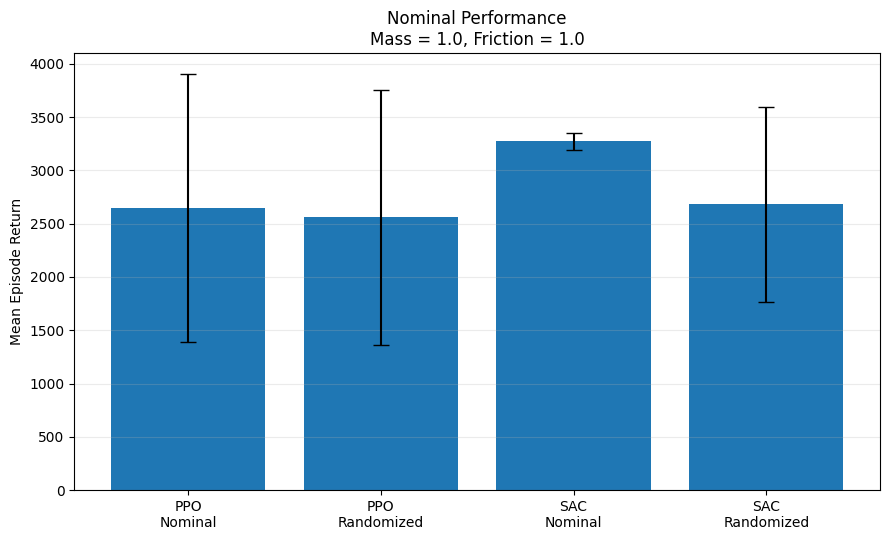

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures/01_nominal_return.png


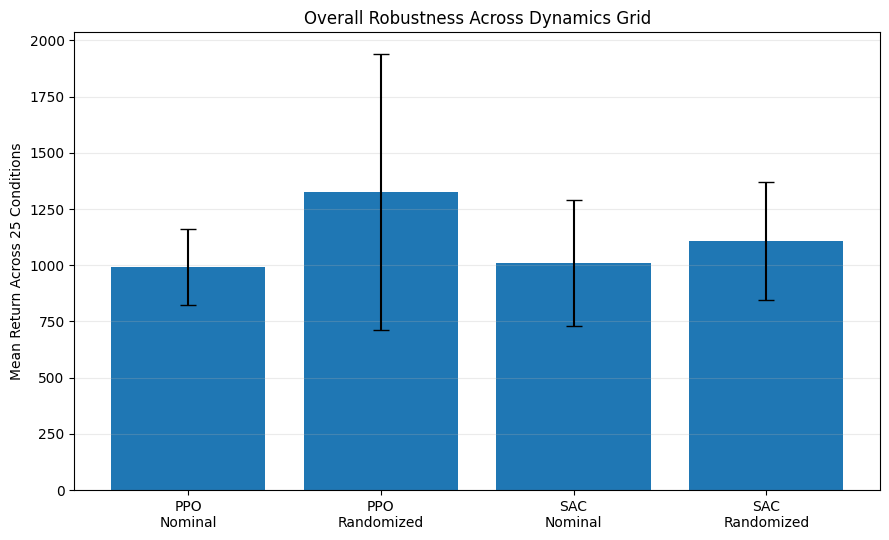

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures/02_overall_robustness.png


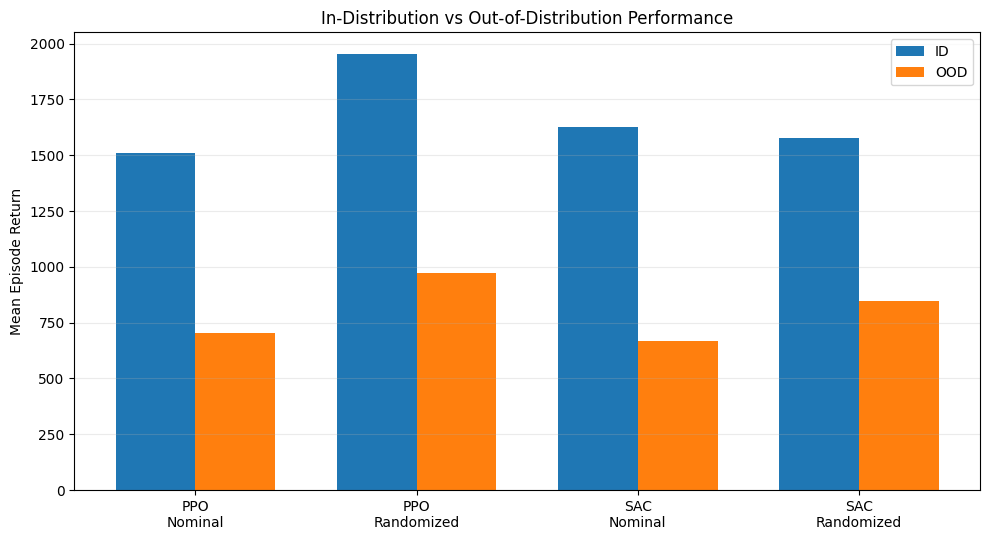

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures/03_id_vs_ood_return.png


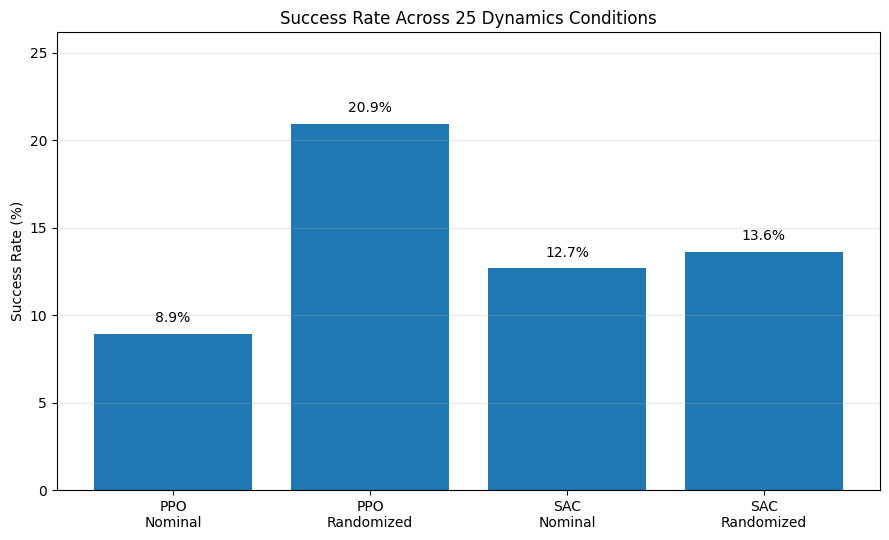

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures/04_grid_success_rate.png

CELL 14 COMPLETE
Presentation figures saved in:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures

Generated:
1. 01_nominal_return.png
2. 02_overall_robustness.png
3. 03_id_vs_ood_return.png
4. 04_grid_success_rate.png


In [16]:
# ============================================================
# CELL 14 — PRESENTATION-READY RESULT FIGURES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("GENERATING PRESENTATION FIGURES")
print("=" * 80)

FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# Reload saved summaries so this cell is independently safe
# ------------------------------------------------------------

grid_df = pd.read_csv(
    os.path.join(RESULTS_DIR, "final_robustness_grid.csv")
)

nominal_summary = pd.read_csv(
    os.path.join(RESULTS_DIR, "nominal_summary.csv")
)

robustness_summary = pd.read_csv(
    os.path.join(RESULTS_DIR, "robustness_summary.csv")
)

id_ood_summary = pd.read_csv(
    os.path.join(RESULTS_DIR, "id_ood_summary.csv")
)

# Friendly configuration label
def config_label(df):
    return (
        df["algorithm"].astype(str)
        + "\n"
        + df["regime"].str.capitalize()
    )


# ============================================================
# FIGURE 1 — NOMINAL RETURN
# ============================================================

plot_df = nominal_summary.copy()
plot_df["label"] = config_label(plot_df)

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(plot_df))

ax.bar(
    x,
    plot_df["mean_return"],
    yerr=plot_df["std_across_seeds"],
    capsize=6
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"])

ax.set_ylabel("Mean Episode Return")
ax.set_title(
    "Nominal Performance\n"
    "Mass = 1.0, Friction = 1.0"
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

path = os.path.join(
    FIG_DIR,
    "01_nominal_return.png"
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", path)


# ============================================================
# FIGURE 2 — OVERALL ROBUSTNESS
# ============================================================

plot_df = robustness_summary.copy()
plot_df["label"] = config_label(plot_df)

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(plot_df))

ax.bar(
    x,
    plot_df["mean_grid_return"],
    yerr=plot_df["std_across_seeds"],
    capsize=6
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"])

ax.set_ylabel("Mean Return Across 25 Conditions")

ax.set_title(
    "Overall Robustness Across Dynamics Grid"
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

path = os.path.join(
    FIG_DIR,
    "02_overall_robustness.png"
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", path)


# ============================================================
# FIGURE 3 — ID vs OOD RETURN
# ============================================================

plot_df = id_ood_summary.copy()

configurations = [
    ("PPO", "nominal"),
    ("PPO", "randomized"),
    ("SAC", "nominal"),
    ("SAC", "randomized")
]

labels = [
    "PPO\nNominal",
    "PPO\nRandomized",
    "SAC\nNominal",
    "SAC\nRandomized"
]

id_values = []
ood_values = []

for algorithm, regime in configurations:

    id_row = plot_df[
        (plot_df["algorithm"] == algorithm) &
        (plot_df["regime"] == regime) &
        (plot_df["condition_group"] == "ID")
    ]

    ood_row = plot_df[
        (plot_df["algorithm"] == algorithm) &
        (plot_df["regime"] == regime) &
        (plot_df["condition_group"] == "OOD")
    ]

    id_values.append(
        id_row["mean_return"].iloc[0]
    )

    ood_values.append(
        ood_row["mean_return"].iloc[0]
    )


x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    x - width / 2,
    id_values,
    width,
    label="ID"
)

ax.bar(
    x + width / 2,
    ood_values,
    width,
    label="OOD"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Mean Episode Return")

ax.set_title(
    "In-Distribution vs Out-of-Distribution Performance"
)

ax.legend()

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

path = os.path.join(
    FIG_DIR,
    "03_id_vs_ood_return.png"
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", path)


# ============================================================
# FIGURE 4 — SUCCESS RATE ACROSS FULL GRID
# ============================================================

plot_df = robustness_summary.copy()
plot_df["label"] = config_label(plot_df)

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(plot_df))

success_percent = (
    plot_df["mean_grid_success_rate"] * 100
)

ax.bar(
    x,
    success_percent
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"])

ax.set_ylabel("Success Rate (%)")

ax.set_title(
    "Success Rate Across 25 Dynamics Conditions"
)

ax.set_ylim(
    0,
    max(success_percent) * 1.25
)

ax.grid(axis="y", alpha=0.25)

# Add percentage labels
for i, value in enumerate(success_percent):

    ax.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.tight_layout()

path = os.path.join(
    FIG_DIR,
    "04_grid_success_rate.png"
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Saved:", path)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 80)
print("CELL 14 COMPLETE")
print("=" * 80)

print("Presentation figures saved in:")
print(FIG_DIR)

print("\nGenerated:")
print("1. 01_nominal_return.png")
print("2. 02_overall_robustness.png")
print("3. 03_id_vs_ood_return.png")
print("4. 04_grid_success_rate.png")

print("=" * 80)

GENERATING ROBUSTNESS HEATMAPS

Generating RETURN heatmaps...



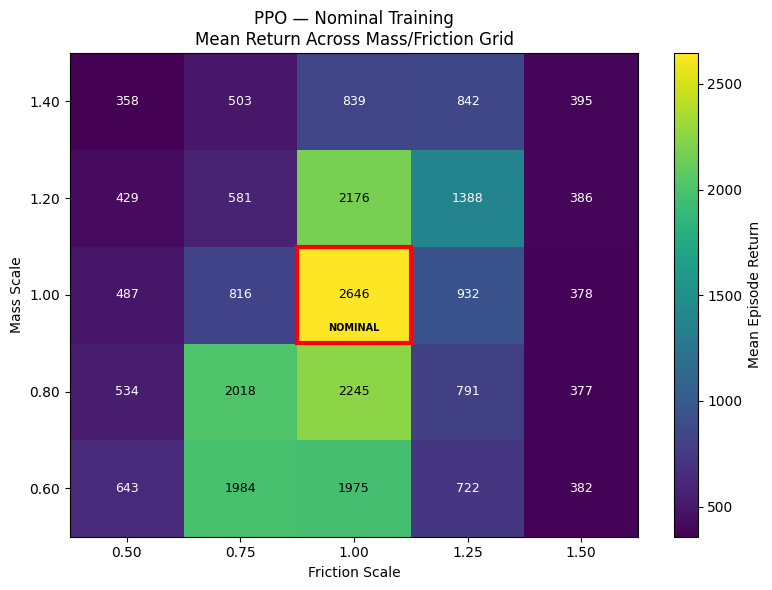

✓ Saved: heatmap_return_ppo_nominal.png


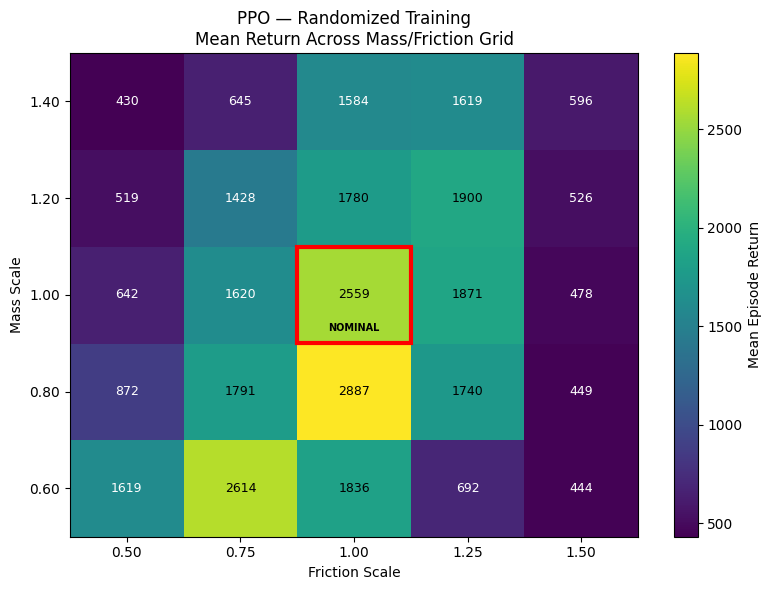

✓ Saved: heatmap_return_ppo_randomized.png


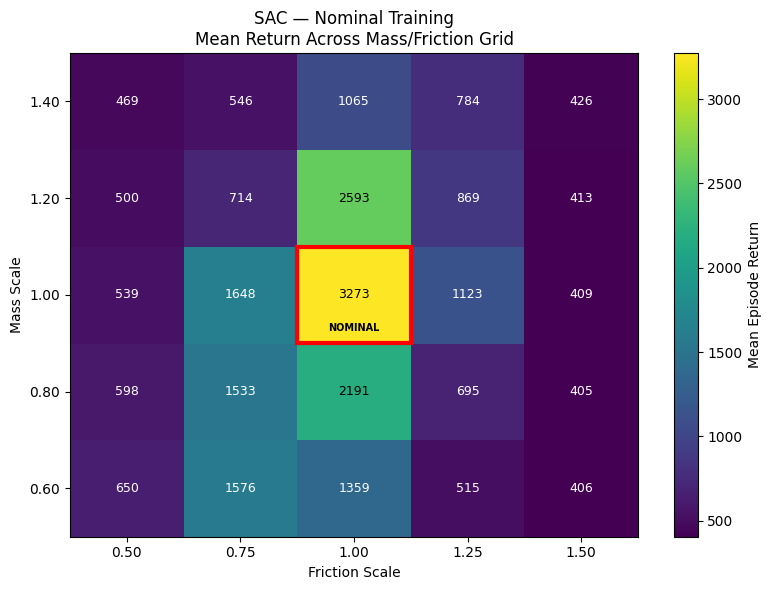

✓ Saved: heatmap_return_sac_nominal.png


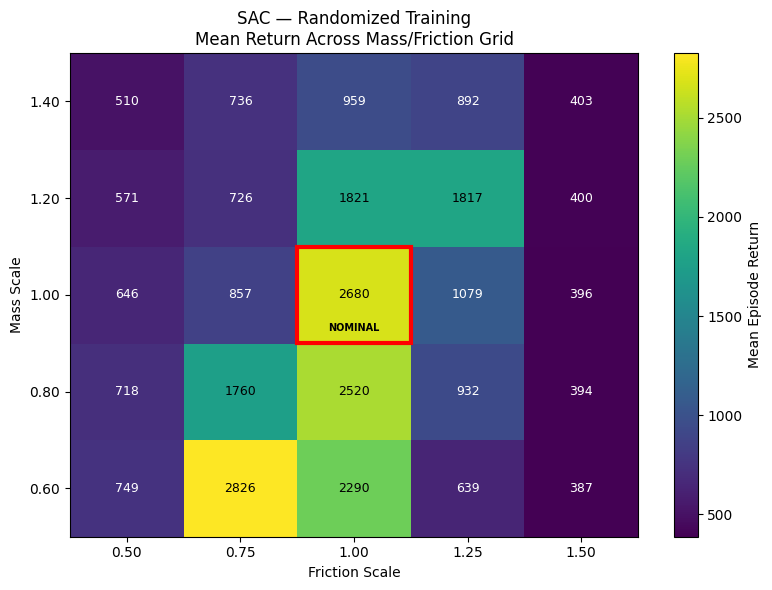

✓ Saved: heatmap_return_sac_randomized.png

Generating SUCCESS-RATE heatmaps...



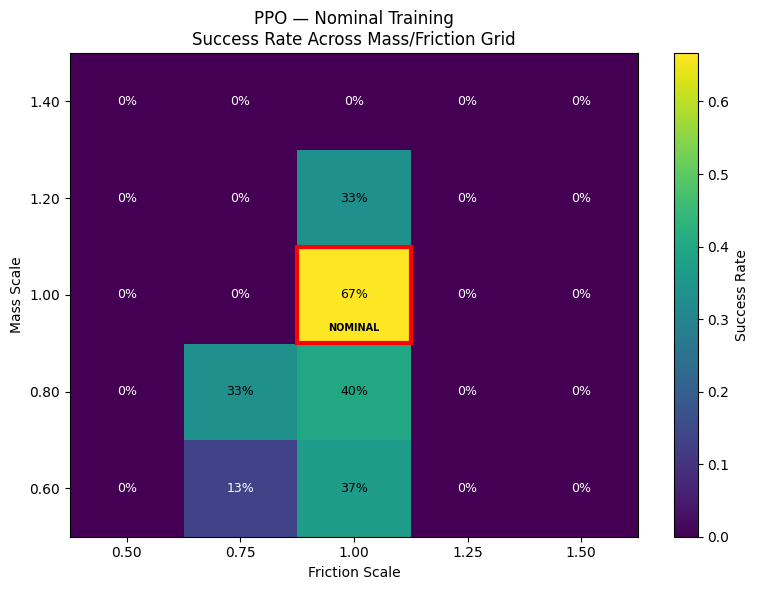

✓ Saved: heatmap_success_ppo_nominal.png


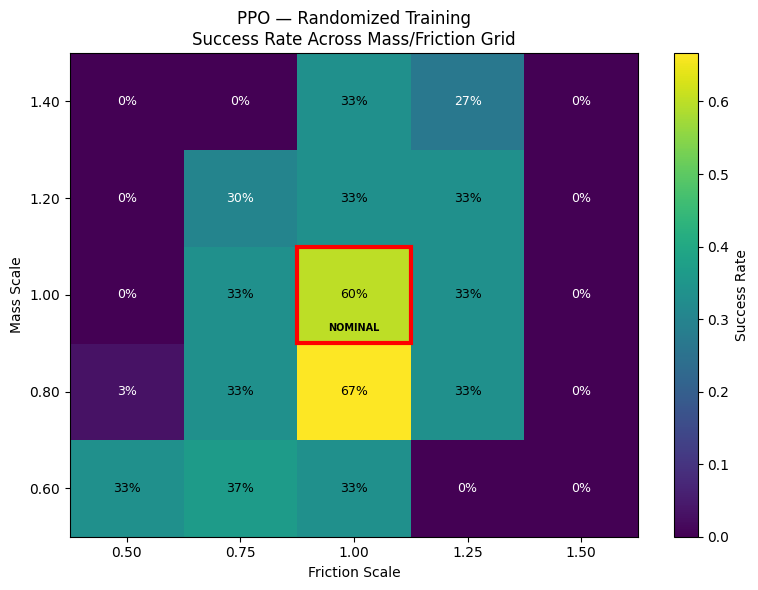

✓ Saved: heatmap_success_ppo_randomized.png


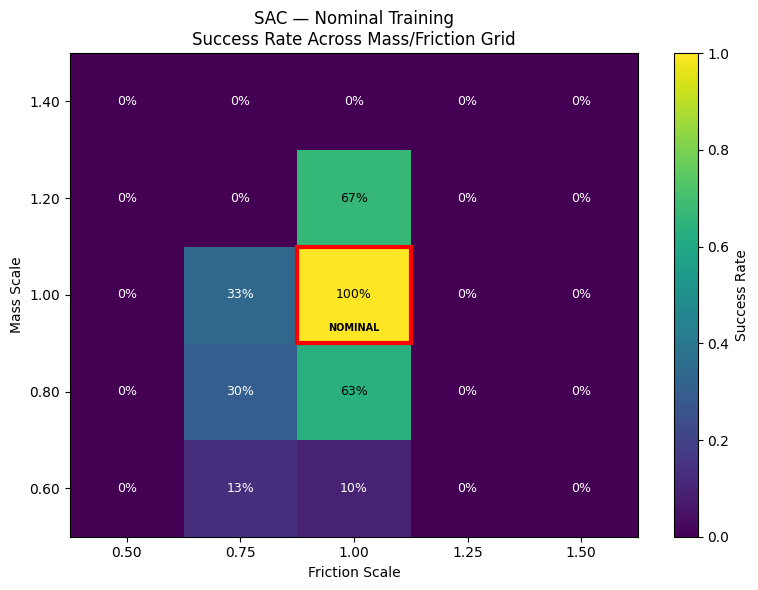

✓ Saved: heatmap_success_sac_nominal.png


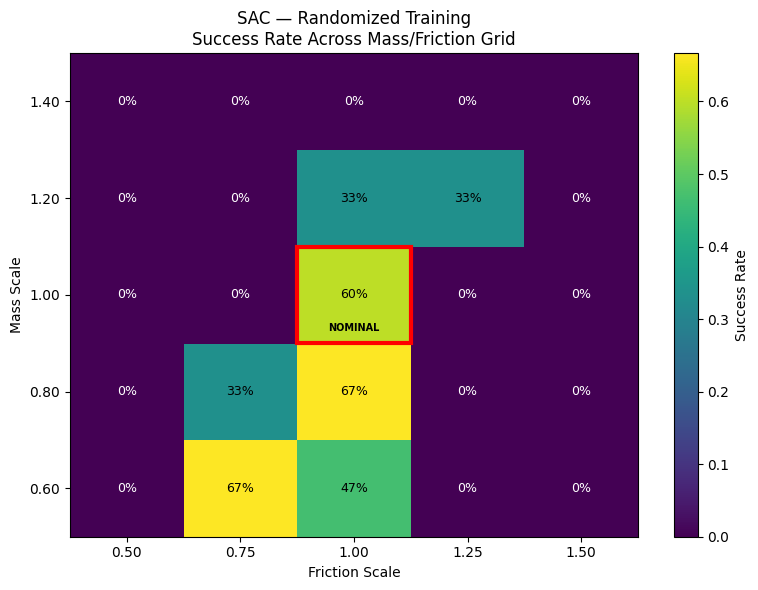

✓ Saved: heatmap_success_sac_randomized.png

CELL 15 COMPLETE

Heatmaps generated:
✓ heatmap_return_ppo_nominal.png
✓ heatmap_success_ppo_nominal.png
✓ heatmap_return_ppo_randomized.png
✓ heatmap_success_ppo_randomized.png
✓ heatmap_return_sac_nominal.png
✓ heatmap_success_sac_nominal.png
✓ heatmap_return_sac_randomized.png
✓ heatmap_success_sac_randomized.png

Total expected heatmaps: 8

Saved in:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures


In [17]:
# ============================================================
# CELL 15 — MASS × FRICTION ROBUSTNESS HEATMAPS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("GENERATING ROBUSTNESS HEATMAPS")
print("=" * 80)

FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Reload raw final-grid results
grid_df = pd.read_csv(
    os.path.join(RESULTS_DIR, "final_robustness_grid.csv")
)

configurations = [
    ("PPO", "nominal"),
    ("PPO", "randomized"),
    ("SAC", "nominal"),
    ("SAC", "randomized")
]


# ============================================================
# HELPER FUNCTION
# ============================================================

def make_heatmap(algorithm, regime, metric, title, filename,
                 value_format=".0f"):

    subset = grid_df[
        (grid_df["algorithm"] == algorithm) &
        (grid_df["regime"] == regime)
    ]

    # Average across:
    #   3 seeds × 10 episodes
    # for each mass/friction condition
    table = (
        subset
        .groupby(
            ["mass_scale", "friction_scale"]
        )[metric]
        .mean()
        .unstack("friction_scale")
    )

    # Make ordering explicit
    table = table.reindex(
        index=sorted(table.index)
    )

    table = table.reindex(
        columns=sorted(table.columns)
    )

    values = table.values

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    im = ax.imshow(
        values,
        aspect="auto",
        origin="lower"
    )

    # Axes
    ax.set_xticks(
        np.arange(len(table.columns))
    )

    ax.set_xticklabels(
        [f"{x:.2f}" for x in table.columns]
    )

    ax.set_yticks(
        np.arange(len(table.index))
    )

    ax.set_yticklabels(
        [f"{x:.2f}" for x in table.index]
    )

    ax.set_xlabel("Friction Scale")
    ax.set_ylabel("Mass Scale")

    ax.set_title(title)

    # Colorbar
    cbar = fig.colorbar(
        im,
        ax=ax
    )

    if metric == "return":
        cbar.set_label("Mean Episode Return")

    elif metric == "success":
        cbar.set_label("Success Rate")


    # --------------------------------------------------------
    # Add numerical values inside every cell
    # --------------------------------------------------------

    threshold = (
        np.nanmin(values) +
        np.nanmax(values)
    ) / 2

    for i in range(values.shape[0]):

        for j in range(values.shape[1]):

            value = values[i, j]

            if metric == "success":

                label = f"{value * 100:.0f}%"

            else:

                label = format(
                    value,
                    value_format
                )

            text_color = (
                "white"
                if value < threshold
                else "black"
            )

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                color=text_color,
                fontsize=9
            )


    # --------------------------------------------------------
    # Mark nominal dynamics condition
    # --------------------------------------------------------

    mass_values = np.array(
        table.index,
        dtype=float
    )

    friction_values = np.array(
        table.columns,
        dtype=float
    )

    nominal_mass_index = np.where(
        np.isclose(
            mass_values,
            1.0
        )
    )[0]

    nominal_friction_index = np.where(
        np.isclose(
            friction_values,
            1.0
        )
    )[0]

    if (
        len(nominal_mass_index) > 0 and
        len(nominal_friction_index) > 0
    ):

        i = nominal_mass_index[0]
        j = nominal_friction_index[0]

        rect = plt.Rectangle(
            (j - 0.5, i - 0.5),
            1,
            1,
            fill=False,
            edgecolor="red",
            linewidth=3
        )

        ax.add_patch(rect)

        ax.text(
            j,
            i - 0.34,
            "NOMINAL",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold"
        )


    fig.tight_layout()

    path = os.path.join(
        FIG_DIR,
        filename
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✓ Saved:", filename)


# ============================================================
# 1–4. RETURN HEATMAPS
# ============================================================

print("\nGenerating RETURN heatmaps...\n")

for algorithm, regime in configurations:

    filename = (
        f"heatmap_return_"
        f"{algorithm.lower()}_{regime}.png"
    )

    title = (
        f"{algorithm} — "
        f"{regime.capitalize()} Training\n"
        f"Mean Return Across Mass/Friction Grid"
    )

    make_heatmap(
        algorithm=algorithm,
        regime=regime,
        metric="return",
        title=title,
        filename=filename,
        value_format=".0f"
    )


# ============================================================
# 5–8. SUCCESS-RATE HEATMAPS
# ============================================================

print("\nGenerating SUCCESS-RATE heatmaps...\n")

for algorithm, regime in configurations:

    filename = (
        f"heatmap_success_"
        f"{algorithm.lower()}_{regime}.png"
    )

    title = (
        f"{algorithm} — "
        f"{regime.capitalize()} Training\n"
        f"Success Rate Across Mass/Friction Grid"
    )

    make_heatmap(
        algorithm=algorithm,
        regime=regime,
        metric="success",
        title=title,
        filename=filename
    )


# ============================================================
# FINAL CHECK
# ============================================================

expected_files = []

for algorithm, regime in configurations:

    expected_files.append(
        f"heatmap_return_"
        f"{algorithm.lower()}_{regime}.png"
    )

    expected_files.append(
        f"heatmap_success_"
        f"{algorithm.lower()}_{regime}.png"
    )


print("\n" + "=" * 80)
print("CELL 15 COMPLETE")
print("=" * 80)

print("\nHeatmaps generated:")

for filename in expected_files:

    path = os.path.join(
        FIG_DIR,
        filename
    )

    exists = os.path.exists(path)

    print(
        "✓" if exists else "✗",
        filename
    )

print("\nTotal expected heatmaps:", len(expected_files))

print("\nSaved in:")
print(FIG_DIR)

print("=" * 80)

GENERATING LEARNING CURVES
Loaded validation rows: 216
Rows after duplicate check: 216 (removed 0)

Validation history available per run:


,algorithm,regime,seed,observations,first_step,last_step
0,PPO,nominal,0,20,25000,500000
1,PPO,nominal,1,20,25000,500000
2,PPO,nominal,2,20,25000,500000
3,PPO,randomized,0,20,25000,500000
4,PPO,randomized,1,20,25000,500000
5,PPO,randomized,2,20,25000,500000
6,SAC,nominal,0,8,325000,500000
7,SAC,nominal,1,20,25000,500000
8,SAC,nominal,2,20,25000,500000
9,SAC,randomized,0,20,25000,500000



NUMBER OF RECORDED SEEDS CONTRIBUTING AT EACH STEP


algorithm     PPO                SAC           
regime    nominal randomized nominal randomized
step                                           
25000         3.0        3.0     2.0        2.0
50000         3.0        3.0     2.0        2.0
75000         3.0        3.0     2.0        2.0
100000        3.0        3.0     2.0        2.0
125000        3.0        3.0     2.0        2.0
150000        3.0        3.0     2.0        2.0
175000        3.0        3.0     2.0        2.0
200000        3.0        3.0     2.0        2.0
225000        3.0        3.0     2.0        2.0
250000        3.0        3.0     2.0        2.0
275000        3.0        3.0     2.0        2.0
300000        3.0        3.0     2.0        2.0
325000        3.0        3.0     3.0        3.0
350000        3.0        3.0     3.0        3.0
375000        3.0        3.0     3.0        3.0
400000        3.0        3.0     3.0        3.0
425000        3.0        3.0     3.0        3.0
450000        3.0        3.0     3.0        3.0
475000        3.0        3.0     3.0        3.0
500000        3.0        3.0     3.0        3.0

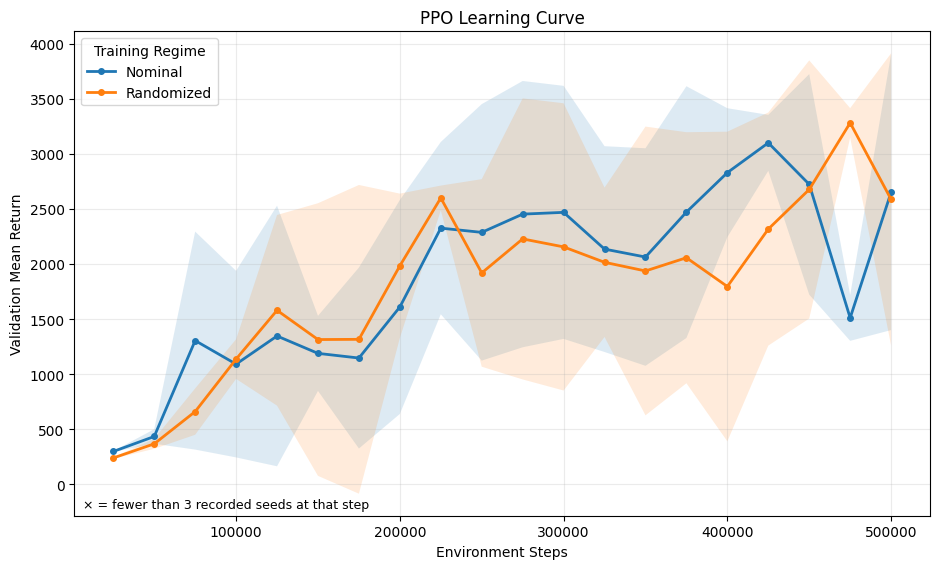

✓ Saved: 05_learning_curve_ppo_return.png


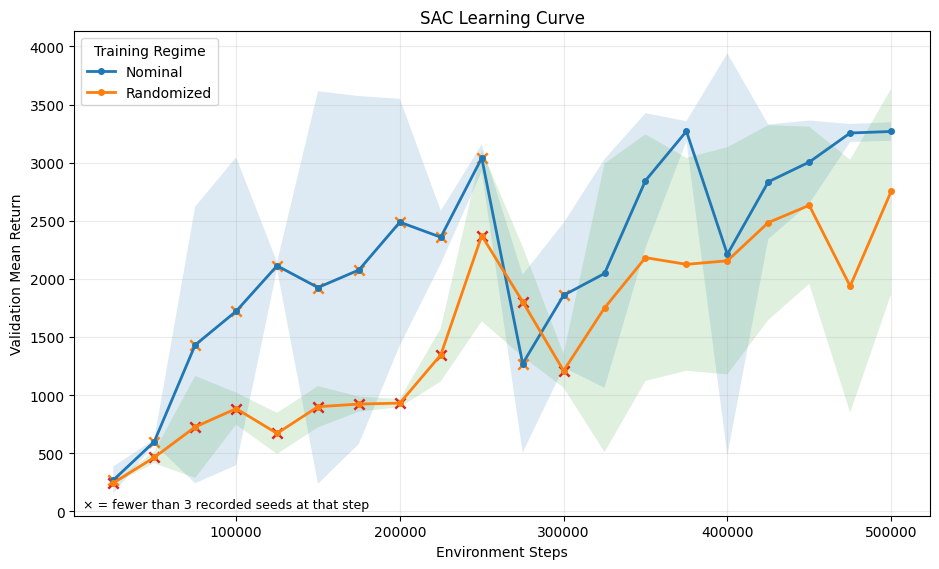

✓ Saved: 06_learning_curve_sac_return.png


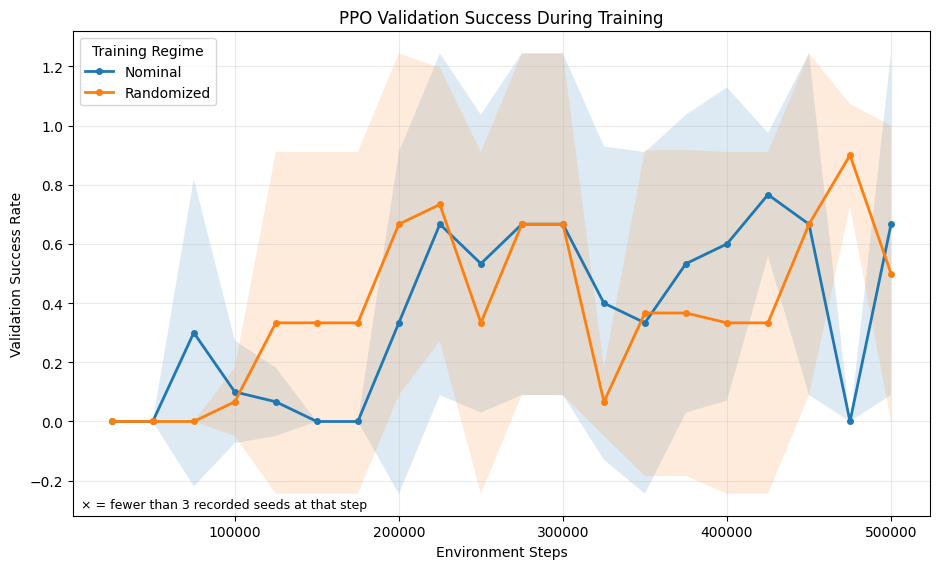

✓ Saved: 07_learning_curve_ppo_success.png


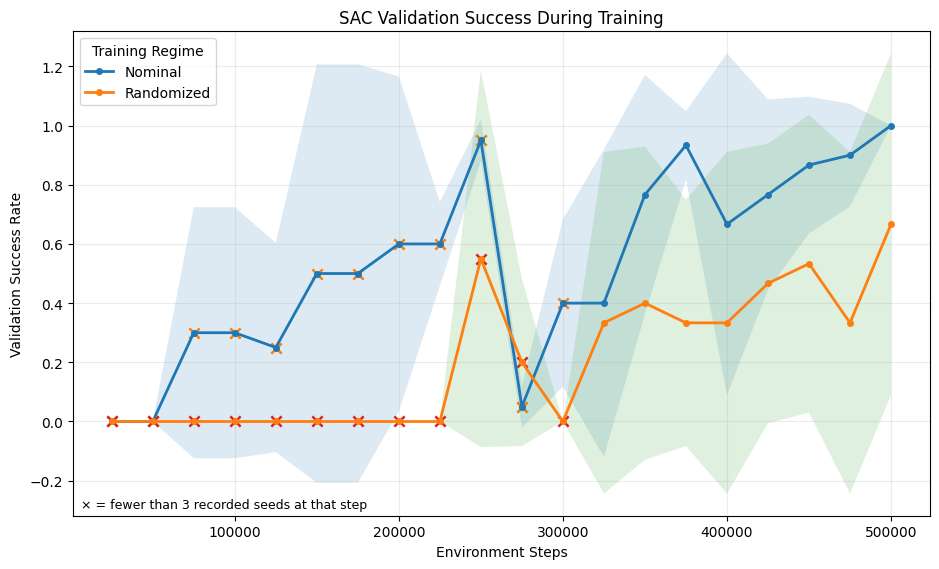

✓ Saved: 08_learning_curve_sac_success.png

CELL 16 COMPLETE
✓ Used only recorded validation observations
✓ No interpolation or reconstruction performed
✓ Partial-seed points marked with ×
✓ Learning-curve summary saved

Figures saved in:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/figures

Generated:
05_learning_curve_ppo_return.png
06_learning_curve_sac_return.png
07_learning_curve_ppo_success.png
08_learning_curve_sac_success.png

Data saved:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/learning_curve_summary_observed.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/learning_curve_seed_coverage.csv


In [18]:
# ============================================================
# CELL 16 — LEARNING CURVES WITH HONEST HANDLING OF
#           INTERRUPTED SAC RUNS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("GENERATING LEARNING CURVES")
print("=" * 80)

FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

curve_path = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

curves = pd.read_csv(curve_path)

print(f"Loaded validation rows: {len(curves):,}")

required_cols = {
    "algorithm",
    "regime",
    "seed",
    "step",
    "mean_return",
    "success_rate",
    "mean_distance_m"
}

missing_cols = required_cols - set(curves.columns)

if missing_cols:
    raise RuntimeError(
        f"Missing required columns: {missing_cols}"
    )


# ============================================================
# 1. REMOVE ACCIDENTAL EXACT DUPLICATES, IF ANY
# ============================================================

before = len(curves)

curves = (
    curves
    .drop_duplicates(
        subset=[
            "algorithm",
            "regime",
            "seed",
            "step"
        ],
        keep="last"
    )
    .sort_values(
        ["algorithm", "regime", "seed", "step"]
    )
    .reset_index(drop=True)
)

after = len(curves)

print(
    f"Rows after duplicate check: {after:,} "
    f"(removed {before-after})"
)


# ============================================================
# 2. VERIFY OBSERVATION COUNTS
# ============================================================

run_counts = (
    curves
    .groupby(
        ["algorithm", "regime", "seed"]
    )
    .agg(
        observations=("step", "nunique"),
        first_step=("step", "min"),
        last_step=("step", "max")
    )
    .reset_index()
)

print("\nValidation history available per run:")
display(run_counts)


# ============================================================
# 3. AGGREGATE ONLY OBSERVED VALUES
# ============================================================
# IMPORTANT:
#
# No interpolation.
# No reconstruction.
# No fabricated historical values.
#
# Mean/std at each step use only seeds with an actual
# recorded evaluation at that step.
# ============================================================

curve_summary = (
    curves
    .groupby(
        ["algorithm", "regime", "step"]
    )
    .agg(
        mean_return=("mean_return", "mean"),
        std_return=("mean_return", "std"),

        mean_success=("success_rate", "mean"),
        std_success=("success_rate", "std"),

        mean_distance=("mean_distance_m", "mean"),
        std_distance=("mean_distance_m", "std"),

        n_seeds=("seed", "nunique")
    )
    .reset_index()
)

curve_summary["std_return"] = (
    curve_summary["std_return"].fillna(0)
)

curve_summary["std_success"] = (
    curve_summary["std_success"].fillna(0)
)

curve_summary["std_distance"] = (
    curve_summary["std_distance"].fillna(0)
)


# ============================================================
# 4. SHOW SEED COVERAGE
# ============================================================

coverage = (
    curve_summary
    .pivot_table(
        index="step",
        columns=["algorithm", "regime"],
        values="n_seeds"
    )
)

print("\n" + "=" * 80)
print("NUMBER OF RECORDED SEEDS CONTRIBUTING AT EACH STEP")
print("=" * 80)

display(coverage)


# ============================================================
# HELPER — DRAW CURVE
# ============================================================

def draw_learning_curve(
    algorithm,
    metric,
    std_metric,
    ylabel,
    title,
    filename
):

    fig, ax = plt.subplots(
        figsize=(9.5, 5.8)
    )

    for regime in ["nominal", "randomized"]:

        d = curve_summary[
            (curve_summary["algorithm"] == algorithm) &
            (curve_summary["regime"] == regime)
        ].sort_values("step")

        x = d["step"].to_numpy()
        y = d[metric].to_numpy()
        s = d[std_metric].to_numpy()

        label = regime.capitalize()

        line, = ax.plot(
            x,
            y,
            marker="o",
            markersize=4,
            linewidth=2,
            label=label
        )

        ax.fill_between(
            x,
            y - s,
            y + s,
            alpha=0.15
        )

        # ----------------------------------------------------
        # Mark points where fewer than all 3 seeds contributed
        # ----------------------------------------------------

        partial = d["n_seeds"] < 3

        if partial.any():

            ax.scatter(
                d.loc[partial, "step"],
                d.loc[partial, metric],
                marker="x",
                s=55,
                linewidths=1.8
            )


    ax.set_xlabel(
        "Environment Steps"
    )

    ax.set_ylabel(
        ylabel
    )

    ax.set_title(
        title
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend(
        title="Training Regime"
    )

    ax.ticklabel_format(
        style="plain",
        axis="x"
    )

    # Explain X marks
    ax.text(
        0.01,
        0.01,
        "× = fewer than 3 recorded seeds at that step",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom"
    )

    fig.tight_layout()

    path = os.path.join(
        FIG_DIR,
        filename
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✓ Saved:", filename)


# ============================================================
# 5. PPO RETURN LEARNING CURVE
# ============================================================

draw_learning_curve(
    algorithm="PPO",
    metric="mean_return",
    std_metric="std_return",
    ylabel="Validation Mean Return",
    title="PPO Learning Curve",
    filename="05_learning_curve_ppo_return.png"
)


# ============================================================
# 6. SAC RETURN LEARNING CURVE
# ============================================================

draw_learning_curve(
    algorithm="SAC",
    metric="mean_return",
    std_metric="std_return",
    ylabel="Validation Mean Return",
    title="SAC Learning Curve",
    filename="06_learning_curve_sac_return.png"
)


# ============================================================
# 7. PPO SUCCESS LEARNING CURVE
# ============================================================

draw_learning_curve(
    algorithm="PPO",
    metric="mean_success",
    std_metric="std_success",
    ylabel="Validation Success Rate",
    title="PPO Validation Success During Training",
    filename="07_learning_curve_ppo_success.png"
)


# ============================================================
# 8. SAC SUCCESS LEARNING CURVE
# ============================================================

draw_learning_curve(
    algorithm="SAC",
    metric="mean_success",
    std_metric="std_success",
    ylabel="Validation Success Rate",
    title="SAC Validation Success During Training",
    filename="08_learning_curve_sac_success.png"
)


# ============================================================
# 9. SAVE CLEAN AGGREGATED CURVE DATA
# ============================================================

summary_path = os.path.join(
    RESULTS_DIR,
    "learning_curve_summary_observed.csv"
)

curve_summary.to_csv(
    summary_path,
    index=False
)

coverage_path = os.path.join(
    RESULTS_DIR,
    "learning_curve_seed_coverage.csv"
)

coverage.to_csv(
    coverage_path
)


# ============================================================
# 10. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 80)
print("CELL 16 COMPLETE")
print("=" * 80)

print(
    "✓ Used only recorded validation observations"
)

print(
    "✓ No interpolation or reconstruction performed"
)

print(
    "✓ Partial-seed points marked with ×"
)

print(
    "✓ Learning-curve summary saved"
)

print("\nFigures saved in:")
print(FIG_DIR)

print("\nGenerated:")
print("05_learning_curve_ppo_return.png")
print("06_learning_curve_sac_return.png")
print("07_learning_curve_ppo_success.png")
print("08_learning_curve_sac_success.png")

print("\nData saved:")
print(summary_path)
print(coverage_path)

print("=" * 80)

In [19]:
# ============================================================
# CELL 17 — FINAL COMPARISON TABLE FOR PRESENTATION
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("FINAL COMPARISON TABLE")
print("=" * 80)


# ============================================================
# 1. LOAD SAVED SUMMARY TABLES
# ============================================================

nominal = pd.read_csv(
    os.path.join(RESULTS_DIR, "nominal_summary.csv")
)

robust = pd.read_csv(
    os.path.join(RESULTS_DIR, "robustness_summary.csv")
)

id_ood = pd.read_csv(
    os.path.join(RESULTS_DIR, "id_ood_summary.csv")
)


# ============================================================
# 2. CREATE ID AND OOD TABLES
# ============================================================

id_df = (
    id_ood[
        id_ood["condition_group"] == "ID"
    ]
    [
        [
            "algorithm",
            "regime",
            "mean_return",
            "mean_success_rate"
        ]
    ]
    .rename(
        columns={
            "mean_return": "id_return",
            "mean_success_rate": "id_success"
        }
    )
)

ood_df = (
    id_ood[
        id_ood["condition_group"] == "OOD"
    ]
    [
        [
            "algorithm",
            "regime",
            "mean_return",
            "mean_success_rate"
        ]
    ]
    .rename(
        columns={
            "mean_return": "ood_return",
            "mean_success_rate": "ood_success"
        }
    )
)


# ============================================================
# 3. SELECT NOMINAL METRICS
# ============================================================

nominal_small = nominal[
    [
        "algorithm",
        "regime",
        "mean_return",
        "std_across_seeds",
        "mean_success_rate",
        "mean_distance_m"
    ]
].rename(
    columns={
        "mean_return": "nominal_return",
        "std_across_seeds": "nominal_return_std",
        "mean_success_rate": "nominal_success",
        "mean_distance_m": "nominal_distance"
    }
)


# ============================================================
# 4. SELECT FULL-GRID ROBUSTNESS METRICS
# ============================================================

robust_small = robust[
    [
        "algorithm",
        "regime",
        "mean_grid_return",
        "std_across_seeds",
        "mean_grid_success_rate",
        "mean_grid_distance_m"
    ]
].rename(
    columns={
        "std_across_seeds": "grid_return_std",
        "mean_grid_success_rate": "grid_success",
        "mean_grid_distance_m": "grid_distance"
    }
)


# ============================================================
# 5. MERGE EVERYTHING
# ============================================================

final_comparison = (
    nominal_small
    .merge(
        robust_small,
        on=["algorithm", "regime"]
    )
    .merge(
        id_df,
        on=["algorithm", "regime"]
    )
    .merge(
        ood_df,
        on=["algorithm", "regime"]
    )
)


# ============================================================
# 6. ADD FRIENDLY CONFIGURATION NAME
# ============================================================

final_comparison.insert(
    0,
    "configuration",
    final_comparison["algorithm"]
    + " "
    + final_comparison["regime"].str.capitalize()
)


# ============================================================
# 7. CONVERT SUCCESS RATES TO PERCENTAGES
# ============================================================

for col in [
    "nominal_success",
    "grid_success",
    "id_success",
    "ood_success"
]:
    final_comparison[col] = (
        final_comparison[col] * 100
    )


# ============================================================
# 8. PRESENTATION VERSION
# ============================================================

presentation_table = final_comparison[
    [
        "configuration",
        "nominal_return",
        "nominal_success",
        "mean_grid_return",
        "grid_success",
        "id_return",
        "ood_return"
    ]
].copy()

presentation_table.columns = [
    "Configuration",
    "Nominal Return",
    "Nominal Success (%)",
    "Grid Return",
    "Grid Success (%)",
    "ID Return",
    "OOD Return"
]

presentation_table = presentation_table.round(
    {
        "Nominal Return": 1,
        "Nominal Success (%)": 1,
        "Grid Return": 1,
        "Grid Success (%)": 1,
        "ID Return": 1,
        "OOD Return": 1
    }
)


# ============================================================
# 9. DISPLAY FINAL TABLE
# ============================================================

print("\n" + "=" * 80)
print("PRESENTATION SUMMARY")
print("=" * 80)

display(presentation_table)


# ============================================================
# 10. IDENTIFY BEST CONFIGURATIONS
# ============================================================

metrics = [
    "Nominal Return",
    "Nominal Success (%)",
    "Grid Return",
    "Grid Success (%)",
    "ID Return",
    "OOD Return"
]

print("\n" + "=" * 80)
print("BEST CONFIGURATION BY METRIC")
print("=" * 80)

best_rows = []

for metric in metrics:

    max_value = presentation_table[
        metric
    ].max()

    winners = presentation_table[
        np.isclose(
            presentation_table[metric],
            max_value
        )
    ]["Configuration"].tolist()

    winner_text = ", ".join(winners)

    best_rows.append(
        {
            "Metric": metric,
            "Best Configuration": winner_text,
            "Value": max_value
        }
    )

best_table = pd.DataFrame(best_rows)

display(best_table)


# ============================================================
# 11. DOMAIN-RANDOMIZATION IMPROVEMENTS
# ============================================================

print("\n" + "=" * 80)
print("DOMAIN RANDOMIZATION IMPROVEMENT")
print("=" * 80)

improvement_rows = []

for algorithm in ["PPO", "SAC"]:

    nom = presentation_table[
        presentation_table["Configuration"]
        == f"{algorithm} Nominal"
    ].iloc[0]

    rnd = presentation_table[
        presentation_table["Configuration"]
        == f"{algorithm} Randomized"
    ].iloc[0]

    improvement_rows.append(
        {
            "Algorithm": algorithm,

            "Grid Return Change":
                rnd["Grid Return"]
                - nom["Grid Return"],

            "Grid Success Change (pp)":
                rnd["Grid Success (%)"]
                - nom["Grid Success (%)"],

            "OOD Return Change":
                rnd["OOD Return"]
                - nom["OOD Return"],

            "Nominal Return Change":
                rnd["Nominal Return"]
                - nom["Nominal Return"]
        }
    )

improvement_table = pd.DataFrame(
    improvement_rows
).round(1)

display(improvement_table)


# ============================================================
# 12. SAVE
# ============================================================

final_path = os.path.join(
    RESULTS_DIR,
    "final_comparison_table.csv"
)

presentation_path = os.path.join(
    RESULTS_DIR,
    "presentation_comparison_table.csv"
)

best_path = os.path.join(
    RESULTS_DIR,
    "best_configuration_by_metric.csv"
)

improvement_path = os.path.join(
    RESULTS_DIR,
    "domain_randomization_improvement.csv"
)

final_comparison.to_csv(
    final_path,
    index=False
)

presentation_table.to_csv(
    presentation_path,
    index=False
)

best_table.to_csv(
    best_path,
    index=False
)

improvement_table.to_csv(
    improvement_path,
    index=False
)


# ============================================================
# 13. FINAL CHECK
# ============================================================

print("\n" + "=" * 80)
print("CELL 17 COMPLETE")
print("=" * 80)

print("✓ Final comparison table created")
print("✓ Best configurations identified")
print("✓ Domain-randomization improvements calculated")

print("\nSaved:")
print(final_path)
print(presentation_path)
print(best_path)
print(improvement_path)

print("=" * 80)

FINAL COMPARISON TABLE

PRESENTATION SUMMARY


,Configuration,Nominal Return,Nominal Success (%),Grid Return,Grid Success (%),ID Return,OOD Return
0,PPO Nominal,2646.1,66.7,993.1,8.9,1510.4,702.1
1,PPO Randomized,2559.0,60.0,1325.7,20.9,1952.8,972.9
2,SAC Nominal,3272.9,100.0,1011.9,12.7,1626.5,666.2
3,SAC Randomized,2680.1,60.0,1108.3,13.6,1576.8,844.8



BEST CONFIGURATION BY METRIC


,Metric,Best Configuration,Value
0,Nominal Return,SAC Nominal,3272.9
1,Nominal Success (%),SAC Nominal,100.0
2,Grid Return,PPO Randomized,1325.7
3,Grid Success (%),PPO Randomized,20.9
4,ID Return,PPO Randomized,1952.8
5,OOD Return,PPO Randomized,972.9



DOMAIN RANDOMIZATION IMPROVEMENT


,Algorithm,Grid Return Change,Grid Success Change (pp),OOD Return Change,Nominal Return Change
0,PPO,332.6,12.0,270.8,-87.1
1,SAC,96.4,0.9,178.6,-592.8



CELL 17 COMPLETE
✓ Final comparison table created
✓ Best configurations identified
✓ Domain-randomization improvements calculated

Saved:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/final_comparison_table.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/presentation_comparison_table.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/best_configuration_by_metric.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/domain_randomization_improvement.csv


In [ ]:
# ============================================================
# CELL 18A — FIX MUJOCO VIDEO RENDERING IN COLAB
# ============================================================

import os

print("=" * 80)
print("CONFIGURING MUJOCO RENDERING")
print("=" * 80)

# Use EGL for headless GPU rendering in Colab
os.environ["MUJOCO_GL"] = "egl"

print("MUJOCO_GL =", os.environ.get("MUJOCO_GL"))

# ------------------------------------------------------------
# Test rendering BEFORE attempting the full videos
# ------------------------------------------------------------

print("\nTesting Hopper-v5 RGB rendering...")

test_env = None

try:
    test_env = make_env(
        seed=12345,
        fixed_mass=1.0,
        fixed_friction=1.0,
        render_mode="rgb_array"
    )

    obs, _ = test_env.reset(seed=12345)

    frame = test_env.render()

    print("✓ Environment created")
    print("✓ Environment reset")
    print("✓ RGB frame rendered")

    if frame is not None:
        print("Frame shape:", frame.shape)
        print("Frame dtype:", frame.dtype)

        if len(frame.shape) == 3 and frame.shape[2] in [3, 4]:
            print("✓ Frame format looks correct.")
        else:
            print("WARNING: Unexpected frame format.")

    else:
        print("WARNING: env.render() returned None.")

finally:
    if test_env is not None:
        test_env.close()


print("\n" + "=" * 80)
print("CELL 18A COMPLETE")
print("=" * 80)

CONFIGURING MUJOCO RENDERING
MUJOCO_GL = egl

Testing Hopper-v5 RGB rendering...


In [20]:
# ============================================================
# CELL 18 — DEMO VIDEO GENERATION
# ============================================================

import os
import numpy as np
import pandas as pd
import imageio.v2 as imageio
from IPython.display import Video, display

print("=" * 80)
print("GENERATING DEMONSTRATION VIDEOS")
print("=" * 80)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

VIDEO_DIR = os.path.join(
    RESULTS_DIR,
    "videos"
)

os.makedirs(
    VIDEO_DIR,
    exist_ok=True
)

print("Video directory:")
print(VIDEO_DIR)


# ============================================================
# 2. VERIFY REQUIRED MODELS
# ============================================================

required_models = [
    ("SAC", "nominal", 0),
    ("SAC", "nominal", 1),
    ("SAC", "nominal", 2),

    ("PPO", "randomized", 0),
    ("PPO", "randomized", 1),
    ("PPO", "randomized", 2)
]

missing = [
    key
    for key in required_models
    if key not in trained
]

if missing:
    raise RuntimeError(
        f"Required models are not loaded: {missing}"
    )

print("\n✓ Required models are loaded.")


# ============================================================
# 3. SELECT REPRESENTATIVE SEEDS
# ============================================================
#
# Use strong representative final models:
#
# SAC nominal:
#   seed 0 nominal return ≈ 3341.7
#
# PPO randomized:
#   seed 1 nominal return ≈ 3409.1
#
# We explicitly identify the seed in the demo rather than
# presenting it as an average across seeds.
# ============================================================

SAC_DEMO_KEY = (
    "SAC",
    "nominal",
    0
)

PPO_DEMO_KEY = (
    "PPO",
    "randomized",
    1
)

sac_model = trained[
    SAC_DEMO_KEY
]

ppo_model = trained[
    PPO_DEMO_KEY
]

print("\nDemo models:")
print("SAC:", SAC_DEMO_KEY)
print("PPO:", PPO_DEMO_KEY)


# ============================================================
# 4. VIDEO HELPER
# ============================================================

def save_demo_video(
    model,
    algorithm,
    regime,
    seed_number,
    mass,
    friction,
    eval_seed,
    filename
):

    print("\n" + "-" * 80)

    print(
        f"{algorithm} | {regime} | "
        f"training seed {seed_number}"
    )

    print(
        f"Environment: mass={mass}, "
        f"friction={friction}"
    )

    # Existing project evaluation function handles:
    #   - environment creation
    #   - deterministic policy
    #   - frame capture
    #   - return/distance/success calculation

    df, frames = deterministic_evaluate(
        model,
        mass=float(mass),
        friction=float(friction),
        n_episodes=1,
        seed=eval_seed,
        capture_video=True
    )

    if len(frames) == 0:
        raise RuntimeError(
            "No video frames were captured."
        )

    output_path = os.path.join(
        VIDEO_DIR,
        filename
    )

    # Hopper-v5 normally runs at approximately 125 FPS.
    # 50 FPS makes the demo easier to view in presentation.
    imageio.mimsave(
        output_path,
        frames,
        fps=50
    )

    row = df.iloc[0]

    print(
        f"Return   : {row['return']:.1f}"
    )

    print(
        f"Length   : {int(row['length'])}"
    )

    print(
        f"Distance : {row['distance_m']:.2f} m"
    )

    print(
        f"Success  : {int(row['success'])}"
    )

    print(
        f"Frames   : {len(frames)}"
    )

    print(
        f"✓ Saved: {output_path}"
    )

    return {
        "algorithm": algorithm,
        "regime": regime,
        "training_seed": seed_number,
        "mass_scale": mass,
        "friction_scale": friction,
        "evaluation_seed": eval_seed,
        "return": float(row["return"]),
        "length": int(row["length"]),
        "distance_m": float(row["distance_m"]),
        "success": int(row["success"]),
        "frames": len(frames),
        "video_file": filename
    }


# ============================================================
# 5. GENERATE VIDEOS
# ============================================================

demo_results = []


# ------------------------------------------------------------
# VIDEO 1
# SAC Nominal — Nominal Environment
# ------------------------------------------------------------

demo_results.append(
    save_demo_video(
        model=sac_model,
        algorithm="SAC",
        regime="nominal",
        seed_number=0,
        mass=1.0,
        friction=1.0,
        eval_seed=70000,
        filename="demo_sac_nominal_at_nominal.mp4"
    )
)


# ------------------------------------------------------------
# VIDEO 2
# PPO Randomized — Nominal Environment
# ------------------------------------------------------------

demo_results.append(
    save_demo_video(
        model=ppo_model,
        algorithm="PPO",
        regime="randomized",
        seed_number=1,
        mass=1.0,
        friction=1.0,
        eval_seed=70000,
        filename="demo_ppo_randomized_at_nominal.mp4"
    )
)


# ------------------------------------------------------------
# VIDEO 3
# SAC Nominal — OOD Environment
#
# mass = 1.4
# friction = 1.5
#
# Both are outside training randomization range.
# ------------------------------------------------------------

demo_results.append(
    save_demo_video(
        model=sac_model,
        algorithm="SAC",
        regime="nominal",
        seed_number=0,
        mass=1.4,
        friction=1.5,
        eval_seed=71000,
        filename="demo_sac_nominal_at_ood.mp4"
    )
)


# ------------------------------------------------------------
# VIDEO 4
# PPO Randomized — SAME OOD Environment
# ------------------------------------------------------------

demo_results.append(
    save_demo_video(
        model=ppo_model,
        algorithm="PPO",
        regime="randomized",
        seed_number=1,
        mass=1.4,
        friction=1.5,
        eval_seed=71000,
        filename="demo_ppo_randomized_at_ood.mp4"
    )
)


# ============================================================
# 6. SAVE DEMO METRICS
# ============================================================

demo_df = pd.DataFrame(
    demo_results
)

demo_csv = os.path.join(
    RESULTS_DIR,
    "demo_video_metrics.csv"
)

demo_df.to_csv(
    demo_csv,
    index=False
)


print("\n" + "=" * 80)
print("DEMO VIDEO RESULTS")
print("=" * 80)

display(
    demo_df[
        [
            "algorithm",
            "regime",
            "training_seed",
            "mass_scale",
            "friction_scale",
            "return",
            "length",
            "distance_m",
            "success",
            "frames"
        ]
    ].round(2)
)


# ============================================================
# 7. VERIFY FILES
# ============================================================

print("\n" + "=" * 80)
print("VIDEO FILE CHECK")
print("=" * 80)

video_files = [
    "demo_sac_nominal_at_nominal.mp4",
    "demo_ppo_randomized_at_nominal.mp4",
    "demo_sac_nominal_at_ood.mp4",
    "demo_ppo_randomized_at_ood.mp4"
]

for filename in video_files:

    path = os.path.join(
        VIDEO_DIR,
        filename
    )

    if os.path.exists(path):

        size_mb = (
            os.path.getsize(path)
            / (1024 * 1024)
        )

        print(
            f"✓ {filename} "
            f"({size_mb:.2f} MB)"
        )

    else:

        print(
            f"✗ MISSING: {filename}"
        )


# ============================================================
# 8. DISPLAY VIDEOS IN COLAB
# ============================================================

print("\n" + "=" * 80)
print("VIDEO PREVIEW")
print("=" * 80)

for filename in video_files:

    path = os.path.join(
        VIDEO_DIR,
        filename
    )

    if os.path.exists(path):

        print("\n", filename)

        display(
            Video(
                path,
                embed=True
            )
        )


# ============================================================
# 9. COMPLETE
# ============================================================

print("\n" + "=" * 80)
print("CELL 18 COMPLETE")
print("=" * 80)

print("✓ 4 demonstration videos generated")
print("✓ Demo metrics saved")
print("✓ Videos saved permanently to Google Drive")

print("\nVideos:")
print(VIDEO_DIR)

print("\nMetrics:")
print(demo_csv)

print("=" * 80)

GENERATING DEMONSTRATION VIDEOS
Video directory:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/videos

✓ Required models are loaded.

Demo models:
SAC: ('SAC', 'nominal', 0)
PPO: ('PPO', 'randomized', 1)

--------------------------------------------------------------------------------
SAC | nominal | training seed 0
Environment: mass=1.0, friction=1.0


FatalError: gladLoadGL error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

DRIVE_BACKUP_DIR = "/content/drive/MyDrive/RL_Part2/rl_part2_final_results"

os.makedirs("/content/drive/MyDrive/RL_Part2", exist_ok=True)

shutil.copytree(
    RESULTS_DIR,
    DRIVE_BACKUP_DIR,
    dirs_exist_ok=True
)

print("PPO results backed up successfully.")
print("Backup location:", DRIVE_BACKUP_DIR)

print("\nFiles in backup:")
for root, dirs, files in os.walk(DRIVE_BACKUP_DIR):
    for file in files:
        print(os.path.join(root, file))

Mounted at /content/drive
PPO results backed up successfully.
Backup location: /content/drive/MyDrive/RL_Part2/rl_part2_final_results

Files in backup:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/training_times.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/validation_learning_curves.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed0.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed1.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed1.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed0.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed2.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed2.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints/ppo_nominal_seed0_500000.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints/ppo_nominal_

## 7. Learning curves, AUC, and steps to return 1,500


,algorithm,regime,seed,learning_curve_auc,steps_to_1500,wall_clock_seconds,wall_clock_hours
0,PPO,nominal,0,2071868.16,20000,43.64,0.01
1,PPO,randomized,0,2452020.82,20000,43.45,0.01
2,SAC,nominal,0,3987956.71,20000,492.18,0.14
3,SAC,randomized,0,5003951.02,20000,492.84,0.14


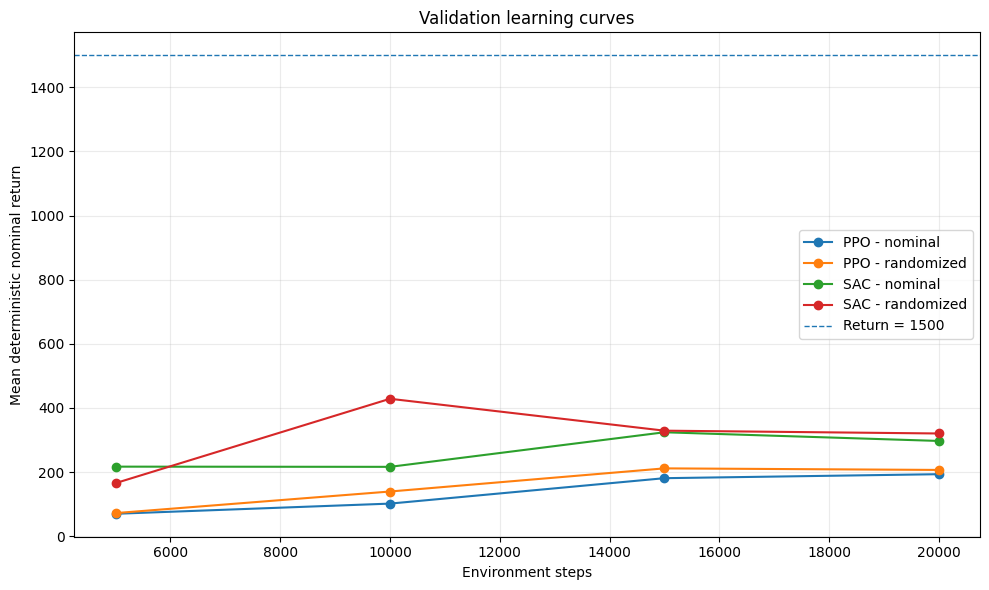

In [ ]:
def trapezoid_auc(g):
    g = g.sort_values("step")
    if len(g) < 2:
        return np.nan
    return np.trapz(g["mean_return"].to_numpy(), g["step"].to_numpy())

efficiency_rows = []
for (algorithm, regime, seed), g in validation_df.groupby(["algorithm", "regime", "seed"]):
    g = g.sort_values("step")
    hits = g[g["mean_return"] >= THRESHOLD_RETURN]
    steps_to = int(hits.iloc[0]["step"]) if len(hits) else TRAIN_STEPS
    efficiency_rows.append({
        "algorithm": algorithm,
        "regime": regime,
        "seed": seed,
        "learning_curve_auc": trapezoid_auc(g),
        "steps_to_1500": steps_to
    })

efficiency_df = pd.DataFrame(efficiency_rows).merge(
    training_times_df, on=["algorithm", "regime", "seed"], how="left"
)
efficiency_df.to_csv(os.path.join(RESULTS_DIR, "training_efficiency.csv"), index=False)
display(efficiency_df.round(2))

plt.figure(figsize=(10, 6))
for (algorithm, regime), g in validation_df.groupby(["algorithm", "regime"]):
    curve = g.groupby("step")["mean_return"].mean()
    plt.plot(curve.index, curve.values, marker="o", label=f"{algorithm} - {regime}")
plt.axhline(THRESHOLD_RETURN, linestyle="--", linewidth=1, label="Return = 1500")
plt.xlabel("Environment steps")
plt.ylabel("Mean deterministic nominal return")
plt.title("Validation learning curves")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "learning_curves.png"), dpi=180)
plt.show()


## 8. Final 5×5 mass/friction robustness test


In [ ]:
grid_rows = []
total = len(trained) * len(MASS_SCALES) * len(FRICTION_SCALES)
counter = 0

for (algorithm, regime, seed), model in trained.items():
    for mass in MASS_SCALES:
        for friction in FRICTION_SCALES:
            counter += 1
            print(f"[{counter}/{total}] {algorithm} {regime} seed={seed} "
                  f"mass={mass:.2f} friction={friction:.2f}")

            df, _ = deterministic_evaluate(
                model,
                mass=float(mass),
                friction=float(friction),
                n_episodes=GRID_EPISODES,
                seed=40_000 + seed * 100
            )

            in_distribution = (
                TRAIN_MASS_RANGE[0] <= mass <= TRAIN_MASS_RANGE[1] and
                TRAIN_FRICTION_RANGE[0] <= friction <= TRAIN_FRICTION_RANGE[1]
            )

            grid_rows.append({
                "algorithm": algorithm,
                "regime": regime,
                "seed": seed,
                "mass_scale": float(mass),
                "friction_scale": float(friction),
                "distribution": "ID" if in_distribution else "OOD",
                "mean_return": df["return"].mean(),
                "mean_distance_m": df["distance_m"].mean(),
                "success_rate": df["success"].mean(),
                "mean_length": df["length"].mean()
            })

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv(os.path.join(RESULTS_DIR, "robustness_grid.csv"), index=False)
display(grid_df.head())


[1/36] PPO nominal seed=0 mass=0.80 friction=0.75
[2/36] PPO nominal seed=0 mass=0.80 friction=1.00
[3/36] PPO nominal seed=0 mass=0.80 friction=1.25
[4/36] PPO nominal seed=0 mass=1.00 friction=0.75
[5/36] PPO nominal seed=0 mass=1.00 friction=1.00
[6/36] PPO nominal seed=0 mass=1.00 friction=1.25
[7/36] PPO nominal seed=0 mass=1.20 friction=0.75
[8/36] PPO nominal seed=0 mass=1.20 friction=1.00
[9/36] PPO nominal seed=0 mass=1.20 friction=1.25
[10/36] PPO randomized seed=0 mass=0.80 friction=0.75
[11/36] PPO randomized seed=0 mass=0.80 friction=1.00
[12/36] PPO randomized seed=0 mass=0.80 friction=1.25
[13/36] PPO randomized seed=0 mass=1.00 friction=0.75
[14/36] PPO randomized seed=0 mass=1.00 friction=1.00
[15/36] PPO randomized seed=0 mass=1.00 friction=1.25
[16/36] PPO randomized seed=0 mass=1.20 friction=0.75
[17/36] PPO randomized seed=0 mass=1.20 friction=1.00
[18/36] PPO randomized seed=0 mass=1.20 friction=1.25
[19/36] SAC nominal seed=0 mass=0.80 friction=0.75
[20/36] SAC n

,algorithm,regime,seed,mass_scale,friction_scale,distribution,mean_return,mean_distance_m,success_rate,mean_length
0,PPO,nominal,0,0.8,0.75,ID,252.046233,1.076447,0.0,118.5
1,PPO,nominal,0,0.8,1.00,ID,256.735993,1.101974,0.0,120.0
2,PPO,nominal,0,0.8,1.25,ID,259.166946,1.105432,0.0,122.0
3,PPO,nominal,0,1.0,0.75,ID,242.646753,1.021254,0.0,116.0
4,PPO,nominal,0,1.0,1.00,ID,250.057627,1.060548,0.0,118.5


## 9. Robustness heatmaps


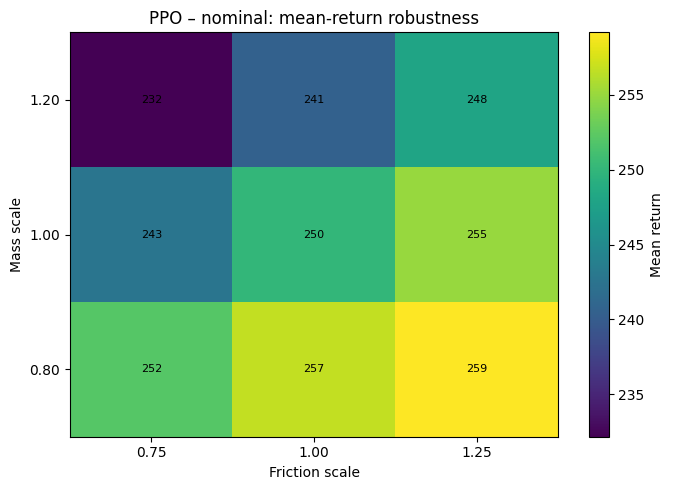

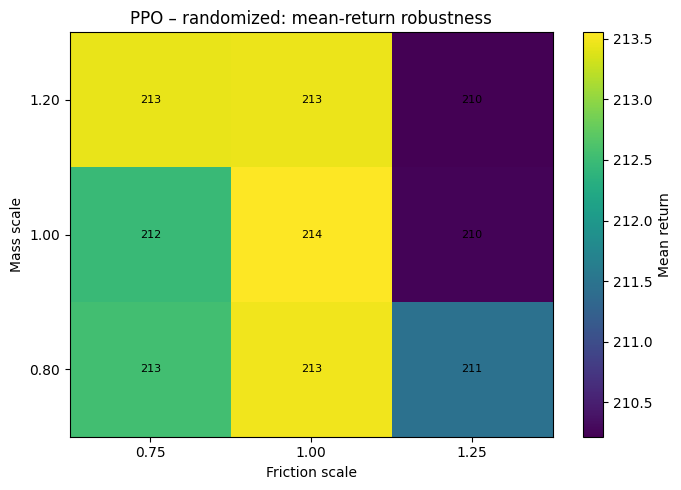

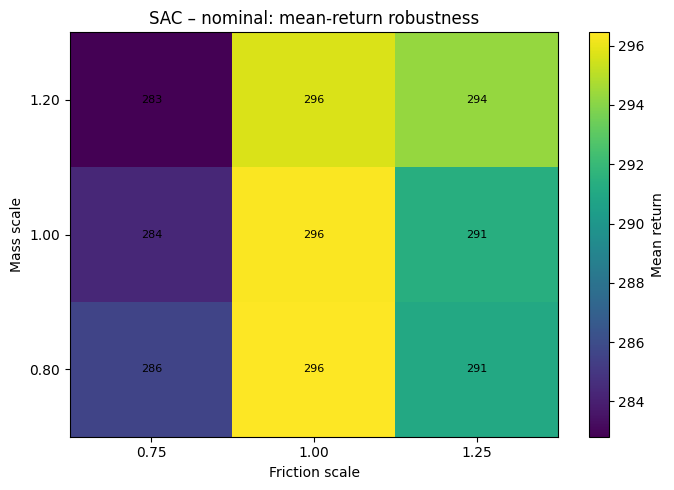

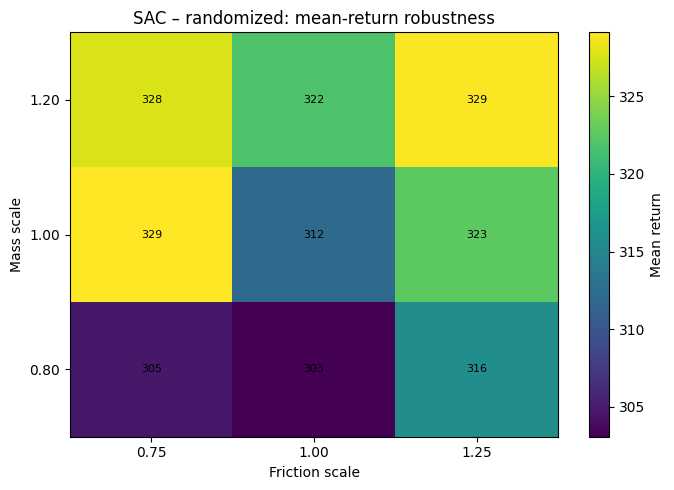

In [ ]:
for (algorithm, regime), g in grid_df.groupby(["algorithm", "regime"]):
    pivot = g.groupby(["mass_scale", "friction_scale"])["mean_return"].mean().unstack()

    plt.figure(figsize=(7, 5))
    im = plt.imshow(pivot.values, origin="lower", aspect="auto")
    plt.colorbar(im, label="Mean return")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [f"{x:.2f}" for x in pivot.index])
    plt.xlabel("Friction scale")
    plt.ylabel("Mass scale")
    plt.title(f"{algorithm} – {regime}: mean-return robustness")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, f"{pivot.iloc[i,j]:.0f}",
                     ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(
        RESULTS_DIR, f"heatmap_{algorithm.lower()}_{regime}.png"), dpi=180)
    plt.show()


In [10]:
# ============================================================
# CELL 18C — SAFE DEMO VIDEO GENERATION
# Software rendering in isolated subprocess
# ============================================================

import os
import sys
import subprocess
import textwrap
import pandas as pd

print("=" * 80)
print("CELL 18C — SAFE DEMO VIDEO GENERATION")
print("=" * 80)


# ============================================================
# 1. IMPORTANT SAFETY CHECK
# ============================================================
#
# Do NOT use EGL in the main notebook process.
# Rendering will happen in a separate Python subprocess.
#
# This protects the current Colab session if MuJoCo's
# renderer crashes.
# ============================================================

print("\nMain notebook MUJOCO_GL:")
print(os.environ.get("MUJOCO_GL", "<not set>"))

# Remove EGL setting from THIS notebook process if it was
# inherited after rerunning cells.
if os.environ.get("MUJOCO_GL") == "egl":
    del os.environ["MUJOCO_GL"]
    print("Removed MUJOCO_GL=egl from main notebook process.")

print("Current setting:")
print(os.environ.get("MUJOCO_GL", "<not set>"))


# ============================================================
# 2. OUTPUT DIRECTORY
# ============================================================

VIDEO_DIR = os.path.join(
    RESULTS_DIR,
    "videos"
)

os.makedirs(VIDEO_DIR, exist_ok=True)

print("\nVideo directory:")
print(VIDEO_DIR)


# ============================================================
# 3. VERIFY FINAL MODEL FILES
# ============================================================

# We will NOT pass the in-memory models to the subprocess.
# Instead, the subprocess will load the saved final .zip files.
#
# Find the exact saved model paths from MODEL_DIR.
# ============================================================

print("\nSearching for final model files...")

all_model_files = []

for root, dirs, files in os.walk(MODEL_DIR):
    for f in files:
        if f.endswith(".zip"):
            all_model_files.append(
                os.path.join(root, f)
            )

print(f"Found {len(all_model_files)} .zip model files.")

for p in all_model_files:
    print(" ", p)


# ============================================================
# 4. FIND MODEL PATH HELPER
# ============================================================

def find_final_model(
    algorithm,
    regime,
    seed
):
    """
    Find the saved final model using filename/path tokens.

    Prefers files containing:
      algorithm
      regime
      seed
      final or 500000
    """

    alg = algorithm.lower()
    reg = regime.lower()

    candidates = []

    for path in all_model_files:

        lower = path.lower()

        if alg not in lower:
            continue

        if reg not in lower:
            continue

        # Flexible seed matching
        seed_tokens = [
            f"seed{seed}",
            f"seed_{seed}",
            f"seed-{seed}"
        ]

        if not any(
            token in lower
            for token in seed_tokens
        ):
            continue

        candidates.append(path)

    if not candidates:
        return None

    # Prefer final model
    final_candidates = [
        p for p in candidates
        if "final" in p.lower()
    ]

    if final_candidates:
        candidates = final_candidates

    # Otherwise prefer 500K checkpoint/model
    step_candidates = [
        p for p in candidates
        if (
            "500000" in p.lower()
            or "500k" in p.lower()
        )
    ]

    if step_candidates:
        candidates = step_candidates

    # Prefer MODEL_DIR over checkpoint paths
    candidates = sorted(
        candidates,
        key=lambda p: (
            "checkpoint" in p.lower(),
            len(p)
        )
    )

    return candidates[0]


# ============================================================
# 5. CHOOSE REPRESENTATIVE MODELS
# ============================================================

SAC_MODEL_PATH = find_final_model(
    "SAC",
    "nominal",
    0
)

PPO_MODEL_PATH = find_final_model(
    "PPO",
    "randomized",
    1
)

print("\nSelected models:")

print("SAC nominal seed 0:")
print(SAC_MODEL_PATH)

print("\nPPO randomized seed 1:")
print(PPO_MODEL_PATH)


if SAC_MODEL_PATH is None:
    raise FileNotFoundError(
        "Could not automatically locate "
        "SAC nominal seed 0 final model."
    )

if PPO_MODEL_PATH is None:
    raise FileNotFoundError(
        "Could not automatically locate "
        "PPO randomized seed 1 final model."
    )


# ============================================================
# 6. CREATE ISOLATED RENDERING SCRIPT
# ============================================================
#
# IMPORTANT:
#
# This script runs OUTSIDE the notebook kernel.
# It uses OSMesa software rendering instead of EGL.
#
# If MuJoCo rendering fails, the subprocess should fail
# rather than killing our main Colab notebook kernel.
# ============================================================

render_script = r'''
import os

# Set BEFORE importing MuJoCo/Gymnasium.
os.environ["MUJOCO_GL"] = "osmesa"

import sys
import json
import numpy as np
import gymnasium as gym
import imageio.v2 as imageio

from stable_baselines3 import PPO, SAC


model_path = sys.argv[1]
algorithm = sys.argv[2]
mass_scale = float(sys.argv[3])
friction_scale = float(sys.argv[4])
eval_seed = int(sys.argv[5])
video_path = sys.argv[6]
metrics_path = sys.argv[7]


# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------

if algorithm.upper() == "PPO":
    model = PPO.load(
        model_path,
        device="cpu"
    )

elif algorithm.upper() == "SAC":
    model = SAC.load(
        model_path,
        device="cpu"
    )

else:
    raise ValueError(
        f"Unknown algorithm: {algorithm}"
    )


# ------------------------------------------------------------
# Create Hopper environment
# ------------------------------------------------------------

env = gym.make(
    "Hopper-v5",
    render_mode="rgb_array"
)


# ------------------------------------------------------------
# Apply fixed dynamics scaling
#
# This reproduces the fixed-mass/fixed-friction idea used
# during the project's robustness evaluation.
# ------------------------------------------------------------

base_mass = env.unwrapped.model.body_mass.copy()
base_friction = env.unwrapped.model.geom_friction.copy()

env.unwrapped.model.body_mass[:] = (
    base_mass * mass_scale
)

env.unwrapped.model.geom_friction[:] = (
    base_friction * friction_scale
)


# ------------------------------------------------------------
# Run one deterministic episode
# ------------------------------------------------------------

obs, info = env.reset(
    seed=eval_seed
)

start_x = float(
    env.unwrapped.data.qpos[0]
)

frames = []

total_return = 0.0
length = 0
terminated = False
truncated = False


while not (
    terminated
    or truncated
):

    # Render BEFORE action
    frame = env.render()

    if frame is not None:
        frames.append(frame)

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = env.step(
        action
    )

    total_return += float(reward)
    length += 1


# Final frame
frame = env.render()

if frame is not None:
    frames.append(frame)


end_x = float(
    env.unwrapped.data.qpos[0]
)

distance = (
    end_x - start_x
)


# Hopper-v5 default maximum episode length
max_episode_steps = (
    env.spec.max_episode_steps
    if env.spec is not None
    else 1000
)


env.close()


# ------------------------------------------------------------
# Save MP4
# ------------------------------------------------------------

if len(frames) == 0:
    raise RuntimeError(
        "Renderer returned zero frames."
    )


imageio.mimsave(
    video_path,
    frames,
    fps=50
)


# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

metrics = {
    "algorithm": algorithm.upper(),
    "mass_scale": mass_scale,
    "friction_scale": friction_scale,
    "evaluation_seed": eval_seed,
    "return": total_return,
    "length": length,
    "distance_m": distance,
    "frames": len(frames),
    "max_episode_steps": max_episode_steps,
    "video_path": video_path
}


with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )


print("RENDER_SUCCESS")
print(json.dumps(metrics, indent=2))
'''


SCRIPT_PATH = os.path.join(
    "/tmp",
    "safe_hopper_renderer.py"
)

with open(
    SCRIPT_PATH,
    "w"
) as f:
    f.write(render_script)

print("\n✓ Isolated renderer script created:")
print(SCRIPT_PATH)


# ============================================================
# 7. SUBPROCESS HELPER
# ============================================================

def run_safe_demo(
    model_path,
    algorithm,
    regime,
    training_seed,
    mass,
    friction,
    eval_seed,
    video_filename
):

    video_path = os.path.join(
        VIDEO_DIR,
        video_filename
    )

    metrics_filename = (
        os.path.splitext(video_filename)[0]
        + "_metrics.json"
    )

    metrics_path = os.path.join(
        VIDEO_DIR,
        metrics_filename
    )

    print("\n" + "-" * 80)

    print(
        f"{algorithm} | {regime} | "
        f"training seed {training_seed}"
    )

    print(
        f"mass={mass}, "
        f"friction={friction}"
    )

    command = [
        sys.executable,
        SCRIPT_PATH,
        model_path,
        algorithm,
        str(mass),
        str(friction),
        str(eval_seed),
        video_path,
        metrics_path
    ]

    # Explicit subprocess environment
    child_env = os.environ.copy()

    child_env["MUJOCO_GL"] = "osmesa"

    # Prevent accidental EGL use
    child_env.pop(
        "PYOPENGL_PLATFORM",
        None
    )

    result = subprocess.run(
        command,
        env=child_env,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=180
    )

    print(
        "Subprocess return code:",
        result.returncode
    )

    if result.stdout.strip():
        print("\nRenderer output:")
        print(result.stdout)

    if result.returncode != 0:

        print("\nRenderer error:")
        print(result.stderr[-5000:])

        return {
            "success": False,
            "video": video_filename,
            "return_code": result.returncode
        }

    if not os.path.exists(video_path):

        print(
            "ERROR: subprocess completed "
            "but video was not created."
        )

        return {
            "success": False,
            "video": video_filename,
            "return_code": result.returncode
        }

    size_mb = (
        os.path.getsize(video_path)
        / (1024 * 1024)
    )

    print(
        f"✓ Video saved "
        f"({size_mb:.2f} MB)"
    )

    return {
        "success": True,
        "video": video_filename,
        "return_code": result.returncode,
        "size_mb": size_mb
    }


# ============================================================
# 8. FIRST — TEST ONLY ONE NOMINAL VIDEO
# ============================================================
#
# IMPORTANT:
# We deliberately generate ONLY ONE video first.
#
# If this works, we know OSMesa rendering is safe.
# Then we can generate the remaining videos.
# ============================================================

print("\n" + "=" * 80)
print("SAFE RENDER TEST — ONE VIDEO ONLY")
print("=" * 80)

test_result = run_safe_demo(
    model_path=SAC_MODEL_PATH,
    algorithm="SAC",
    regime="nominal",
    training_seed=0,
    mass=1.0,
    friction=1.0,
    eval_seed=70000,
    video_filename=(
        "demo_sac_nominal_at_nominal.mp4"
    )
)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 18C RESULT")
print("=" * 80)

if test_result["success"]:

    print("✓ SAFE RENDER TEST PASSED")
    print("✓ SAC nominal demo video created")
    print()
    print(
        "Do NOT generate the other videos yet."
    )
    print(
        "Send this output to ChatGPT first."
    )

else:

    print("✗ SAFE RENDER TEST FAILED")
    print()
    print(
        "The main notebook session should "
        "still be intact."
    )
    print(
        "Do NOT rerun this cell."
    )
    print(
        "Send the Renderer error output "
        "to ChatGPT."
    )

print("=" * 80)

CELL 18C — SAFE DEMO VIDEO GENERATION

Main notebook MUJOCO_GL:
<not set>
Current setting:
<not set>

Video directory:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/videos

Searching for final model files...
Found 12 .zip model files.
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed0.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed1.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed2.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed0.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed1.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed2.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/sac_nominal_seed0.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/sac_nominal_seed1.zip
  /content/drive/MyDrive/RL_Part2/rl_part2_final_results/mo

CELL 18D — SAFE POLICY DEMO

Demo directory:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo

✓ Required models loaded
SAC demo model: ('SAC', 'nominal', 0)
PPO demo model: ('PPO', 'randomized', 1)

--------------------------------------------------------------------------------
SAC Nominal — Nominal Dynamics
Return   : 3332.2
Length   : 1000
Distance : 18.66 m
✓ Saved trajectory: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo/sac_nominal_nominal_trajectory.csv

--------------------------------------------------------------------------------
PPO Randomized — Nominal Dynamics
Return   : 3405.3
Length   : 1000
Distance : 19.25 m
✓ Saved trajectory: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo/ppo_randomized_nominal_trajectory.csv

--------------------------------------------------------------------------------
SAC Nominal — OOD Dynamics
Return   : 407.1
Length   : 153
Distance : 2.04 m
✓ Saved trajectory: /content/drive/MyDrive/RL_Part2/rl_part2_fi

,algorithm,regime,training_seed,mass_scale,friction_scale,evaluation_seed,return,episode_length,distance_m
0,SAC,nominal,0,1.0,1.0,70000,3332.23,1000,18.66
1,PPO,randomized,1,1.0,1.0,70000,3405.29,1000,19.25
2,SAC,nominal,0,1.4,1.5,71000,407.07,153,2.04
3,PPO,randomized,1,1.4,1.5,71000,728.42,223,4.05


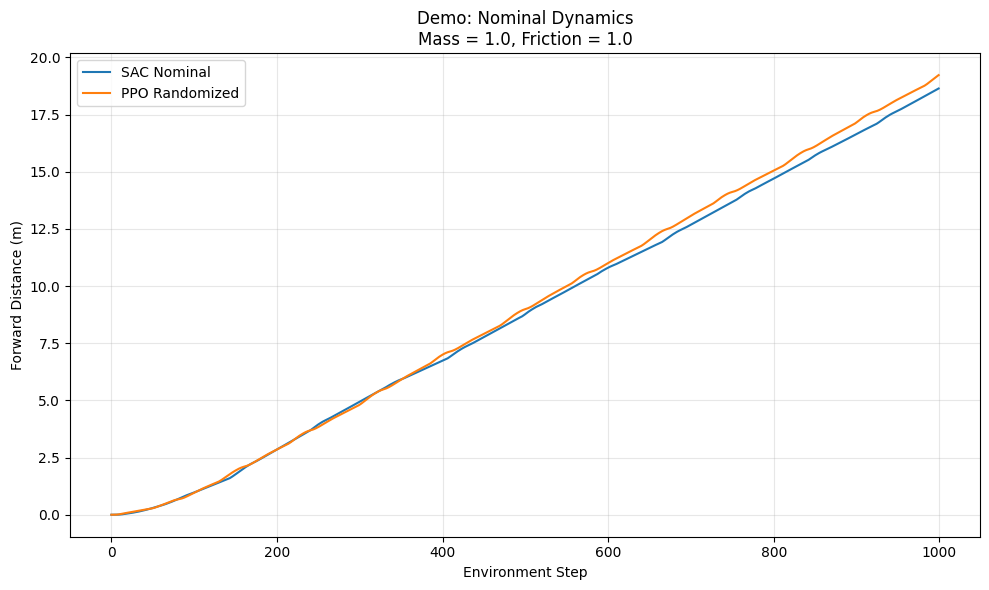

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo/demo_nominal_distance.png


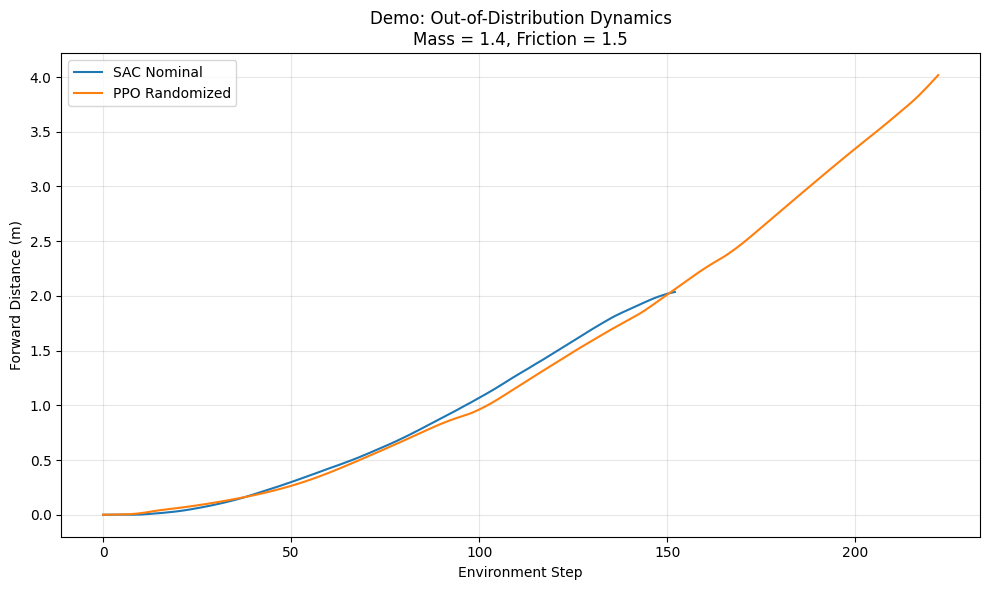

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo/demo_ood_distance.png


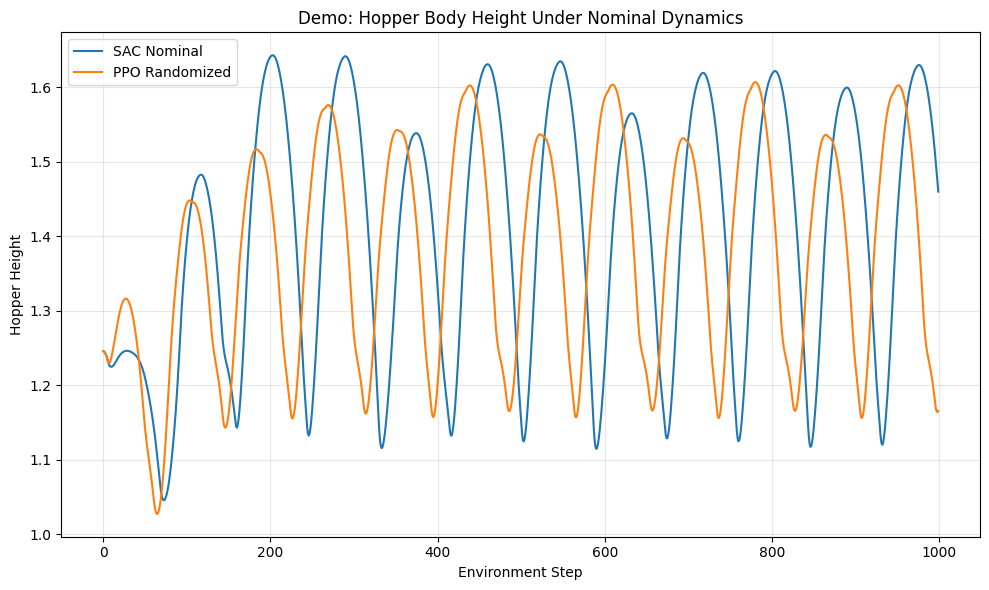

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo/demo_nominal_height.png


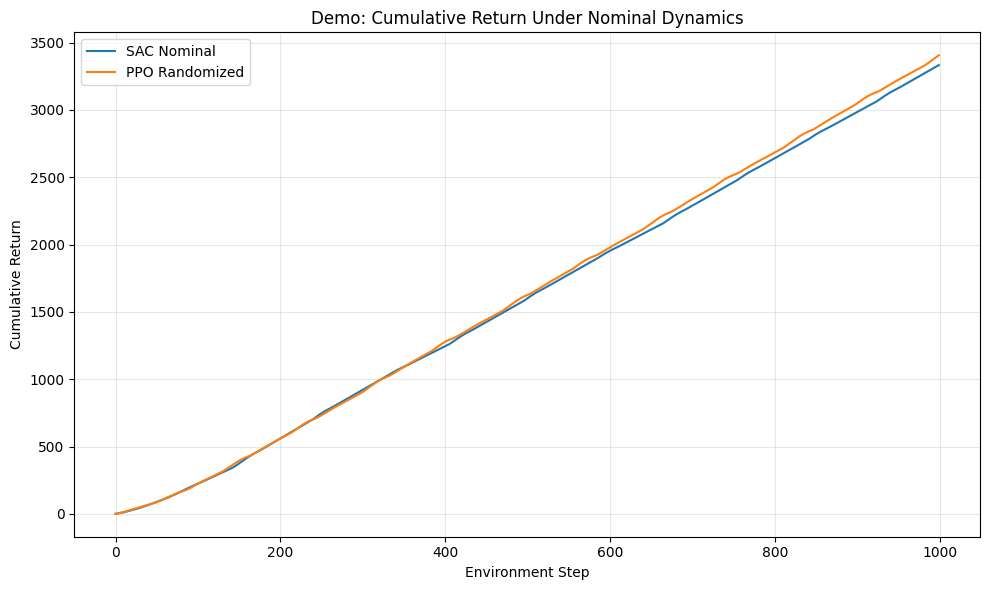

✓ Saved: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo/demo_nominal_return.png

SAVED DEMO FILES
✓ demo_nominal_distance.png
✓ demo_nominal_height.png
✓ demo_nominal_return.png
✓ demo_ood_distance.png
✓ demo_summary.csv
✓ ppo_randomized_nominal_trajectory.csv
✓ ppo_randomized_ood_trajectory.csv
✓ sac_nominal_nominal_trajectory.csv
✓ sac_nominal_ood_trajectory.csv

CELL 18D COMPLETE
✓ No MuJoCo rendering used
✓ No EGL used
✓ No OSMesa used
✓ No training performed
✓ Four policy trajectories evaluated
✓ Demo data saved
✓ Demo figures saved

Demo directory:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/demo


In [11]:
# ============================================================
# CELL 18D — SAFE POLICY DEMO (NO MUJOCO RENDERING)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("CELL 18D — SAFE POLICY DEMO")
print("=" * 80)

# IMPORTANT:
# No rgb_array
# No EGL
# No OSMesa
# No video rendering
# No training
#
# This only executes already-trained policies and records
# Hopper trajectory information.


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

DEMO_DIR = os.path.join(
    RESULTS_DIR,
    "demo"
)

os.makedirs(
    DEMO_DIR,
    exist_ok=True
)

print("\nDemo directory:")
print(DEMO_DIR)


# ============================================================
# 2. VERIFY MODELS
# ============================================================

SAC_KEY = ("SAC", "nominal", 0)
PPO_KEY = ("PPO", "randomized", 1)

if SAC_KEY not in trained:
    raise RuntimeError(
        f"Model not loaded: {SAC_KEY}"
    )

if PPO_KEY not in trained:
    raise RuntimeError(
        f"Model not loaded: {PPO_KEY}"
    )

sac_model = trained[SAC_KEY]
ppo_model = trained[PPO_KEY]

print("\n✓ Required models loaded")
print("SAC demo model:", SAC_KEY)
print("PPO demo model:", PPO_KEY)


# ============================================================
# 3. SAFE TRAJECTORY FUNCTION
# ============================================================

def collect_demo_trajectory(
    model,
    algorithm,
    regime,
    training_seed,
    mass,
    friction,
    eval_seed
):

    # IMPORTANT:
    # render_mode=None
    env = make_env(
        seed=eval_seed,
        fixed_mass=float(mass),
        fixed_friction=float(friction),
        render_mode=None
    )

    obs, _ = env.reset(
        seed=eval_seed
    )

    start_x = float(
        env.unwrapped.data.qpos[0]
    )

    rows = []

    total_return = 0.0
    step = 0

    terminated = False
    truncated = False

    while not (
        terminated
        or truncated
    ):

        # Hopper state before action
        x_position = float(
            env.unwrapped.data.qpos[0]
        )

        height = float(
            env.unwrapped.data.qpos[1]
        )

        angle = float(
            env.unwrapped.data.qpos[2]
        )

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, terminated, truncated, _ = env.step(
            action
        )

        total_return += float(reward)

        rows.append(
            {
                "step": step,
                "x_position": x_position,
                "distance_m": (
                    x_position - start_x
                ),
                "height": height,
                "body_angle": angle,
                "reward": float(reward),
                "cumulative_return": total_return
            }
        )

        step += 1

    end_x = float(
        env.unwrapped.data.qpos[0]
    )

    distance = (
        end_x - start_x
    )

    env.close()

    trajectory = pd.DataFrame(rows)

    summary = {
        "algorithm": algorithm,
        "regime": regime,
        "training_seed": training_seed,
        "mass_scale": mass,
        "friction_scale": friction,
        "evaluation_seed": eval_seed,
        "return": total_return,
        "episode_length": step,
        "distance_m": distance
    }

    return trajectory, summary


# ============================================================
# 4. RUN FOUR SAFE DEMOS
# ============================================================

experiments = [
    {
        "name": "SAC Nominal — Nominal Dynamics",
        "short_name": "sac_nominal_nominal",
        "model": sac_model,
        "algorithm": "SAC",
        "regime": "nominal",
        "training_seed": 0,
        "mass": 1.0,
        "friction": 1.0,
        "eval_seed": 70000
    },

    {
        "name": "PPO Randomized — Nominal Dynamics",
        "short_name": "ppo_randomized_nominal",
        "model": ppo_model,
        "algorithm": "PPO",
        "regime": "randomized",
        "training_seed": 1,
        "mass": 1.0,
        "friction": 1.0,
        "eval_seed": 70000
    },

    {
        "name": "SAC Nominal — OOD Dynamics",
        "short_name": "sac_nominal_ood",
        "model": sac_model,
        "algorithm": "SAC",
        "regime": "nominal",
        "training_seed": 0,
        "mass": 1.4,
        "friction": 1.5,
        "eval_seed": 71000
    },

    {
        "name": "PPO Randomized — OOD Dynamics",
        "short_name": "ppo_randomized_ood",
        "model": ppo_model,
        "algorithm": "PPO",
        "regime": "randomized",
        "training_seed": 1,
        "mass": 1.4,
        "friction": 1.5,
        "eval_seed": 71000
    }
]


trajectories = {}
summary_rows = []


for exp in experiments:

    print("\n" + "-" * 80)
    print(exp["name"])

    trajectory, summary = collect_demo_trajectory(
        model=exp["model"],
        algorithm=exp["algorithm"],
        regime=exp["regime"],
        training_seed=exp["training_seed"],
        mass=exp["mass"],
        friction=exp["friction"],
        eval_seed=exp["eval_seed"]
    )

    trajectories[
        exp["short_name"]
    ] = trajectory

    summary_rows.append(summary)

    trajectory_path = os.path.join(
        DEMO_DIR,
        exp["short_name"] + "_trajectory.csv"
    )

    trajectory.to_csv(
        trajectory_path,
        index=False
    )

    print(
        f"Return   : "
        f"{summary['return']:.1f}"
    )

    print(
        f"Length   : "
        f"{summary['episode_length']}"
    )

    print(
        f"Distance : "
        f"{summary['distance_m']:.2f} m"
    )

    print(
        f"✓ Saved trajectory: "
        f"{trajectory_path}"
    )


# ============================================================
# 5. SUMMARY TABLE
# ============================================================

demo_summary = pd.DataFrame(
    summary_rows
)

summary_path = os.path.join(
    DEMO_DIR,
    "demo_summary.csv"
)

demo_summary.to_csv(
    summary_path,
    index=False
)

print("\n" + "=" * 80)
print("DEMO SUMMARY")
print("=" * 80)

display(
    demo_summary.round(2)
)


# ============================================================
# 6. NOMINAL DISTANCE TRAJECTORY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    trajectories[
        "sac_nominal_nominal"
    ]["step"],
    trajectories[
        "sac_nominal_nominal"
    ]["distance_m"],
    label="SAC Nominal"
)

plt.plot(
    trajectories[
        "ppo_randomized_nominal"
    ]["step"],
    trajectories[
        "ppo_randomized_nominal"
    ]["distance_m"],
    label="PPO Randomized"
)

plt.xlabel("Environment Step")
plt.ylabel("Forward Distance (m)")

plt.title(
    "Demo: Nominal Dynamics\n"
    "Mass = 1.0, Friction = 1.0"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

nominal_plot = os.path.join(
    DEMO_DIR,
    "demo_nominal_distance.png"
)

plt.savefig(
    nominal_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    nominal_plot
)


# ============================================================
# 7. OOD DISTANCE TRAJECTORY
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    trajectories[
        "sac_nominal_ood"
    ]["step"],
    trajectories[
        "sac_nominal_ood"
    ]["distance_m"],
    label="SAC Nominal"
)

plt.plot(
    trajectories[
        "ppo_randomized_ood"
    ]["step"],
    trajectories[
        "ppo_randomized_ood"
    ]["distance_m"],
    label="PPO Randomized"
)

plt.xlabel("Environment Step")
plt.ylabel("Forward Distance (m)")

plt.title(
    "Demo: Out-of-Distribution Dynamics\n"
    "Mass = 1.4, Friction = 1.5"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ood_plot = os.path.join(
    DEMO_DIR,
    "demo_ood_distance.png"
)

plt.savefig(
    ood_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    ood_plot
)


# ============================================================
# 8. BODY HEIGHT COMPARISON — NOMINAL
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    trajectories[
        "sac_nominal_nominal"
    ]["step"],
    trajectories[
        "sac_nominal_nominal"
    ]["height"],
    label="SAC Nominal"
)

plt.plot(
    trajectories[
        "ppo_randomized_nominal"
    ]["step"],
    trajectories[
        "ppo_randomized_nominal"
    ]["height"],
    label="PPO Randomized"
)

plt.xlabel("Environment Step")
plt.ylabel("Hopper Height")

plt.title(
    "Demo: Hopper Body Height "
    "Under Nominal Dynamics"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

height_plot = os.path.join(
    DEMO_DIR,
    "demo_nominal_height.png"
)

plt.savefig(
    height_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    height_plot
)


# ============================================================
# 9. CUMULATIVE RETURN — NOMINAL
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    trajectories[
        "sac_nominal_nominal"
    ]["step"],
    trajectories[
        "sac_nominal_nominal"
    ]["cumulative_return"],
    label="SAC Nominal"
)

plt.plot(
    trajectories[
        "ppo_randomized_nominal"
    ]["step"],
    trajectories[
        "ppo_randomized_nominal"
    ]["cumulative_return"],
    label="PPO Randomized"
)

plt.xlabel("Environment Step")
plt.ylabel("Cumulative Return")

plt.title(
    "Demo: Cumulative Return "
    "Under Nominal Dynamics"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

return_plot = os.path.join(
    DEMO_DIR,
    "demo_nominal_return.png"
)

plt.savefig(
    return_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Saved:",
    return_plot
)


# ============================================================
# 10. FILE CHECK
# ============================================================

print("\n" + "=" * 80)
print("SAVED DEMO FILES")
print("=" * 80)

for filename in sorted(
    os.listdir(DEMO_DIR)
):
    print("✓", filename)


# ============================================================
# 11. COMPLETE
# ============================================================

print("\n" + "=" * 80)
print("CELL 18D COMPLETE")
print("=" * 80)

print("✓ No MuJoCo rendering used")
print("✓ No EGL used")
print("✓ No OSMesa used")
print("✓ No training performed")
print("✓ Four policy trajectories evaluated")
print("✓ Demo data saved")
print("✓ Demo figures saved")

print("\nDemo directory:")
print(DEMO_DIR)

print("=" * 80)

## 10. IQM and 95% bootstrap confidence intervals

Part 1 specifies interquartile means (IQM) across seeds and bootstrap confidence intervals.

For five final seeds, the function below:
1. sorts the seed-level values;
2. computes a 25%-trimmed mean using fractional boundary weights;
3. bootstraps the seed-level observations to estimate a 95% confidence interval.

With only five seeds, confidence intervals can be wide; this limitation should be acknowledged in Part 2.


In [ ]:
def iqm(values):
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0:
        return np.nan
    # Mean of the empirical quantile function from 25% to 75%.
    lo, hi = 0.25*n, 0.75*n
    total = 0.0
    weight = 0.0
    for i, value in enumerate(x):
        left, right = i, i+1
        overlap = max(0.0, min(right, hi) - max(left, lo))
        total += overlap * value
        weight += overlap
    return total / weight if weight else np.nan


def bootstrap_iqm_ci(values, n_boot=5000, seed=123):
    x = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    boots = np.array([iqm(rng.choice(x, size=len(x), replace=True))
                      for _ in range(n_boot)])
    return iqm(x), np.percentile(boots, 2.5), np.percentile(boots, 97.5)


def bootstrap_difference_ci(a, b, n_boot=5000, seed=456):
    a, b = np.asarray(a, float), np.asarray(b, float)
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        diffs.append(iqm(aa) - iqm(bb))
    return iqm(a)-iqm(b), *np.percentile(diffs, [2.5, 97.5])


## 11. Seed-level final metrics


In [ ]:
seed_metrics = []

for (algorithm, regime, seed), g in grid_df.groupby(["algorithm", "regime", "seed"]):
    nominal = g[(g.mass_scale == 1.0) & (g.friction_scale == 1.0)]
    ood = g[g.distribution == "OOD"]

    # In smoke mode the reduced grid may contain no OOD cells.
    if len(ood) == 0:
        ood = g[(g.mass_scale != 1.0) | (g.friction_scale != 1.0)]

    nominal_return = nominal["mean_return"].iloc[0]
    ood_mean = ood["mean_return"].mean()

    seed_metrics.append({
        "algorithm": algorithm,
        "regime": regime,
        "seed": seed,
        "nominal_return": nominal_return,
        "nominal_success_rate": nominal["success_rate"].iloc[0],
        "ood_mean_return": ood_mean,
        "ood_success_rate": ood["success_rate"].mean(),
        "worst_cell_return": g["mean_return"].min(),
        "robustness_ratio": ood_mean / nominal_return if nominal_return != 0 else np.nan,
        "final_nominal_iqr_input": nominal_return
    })

seed_metrics_df = pd.DataFrame(seed_metrics)
seed_metrics_df.to_csv(os.path.join(RESULTS_DIR, "seed_level_metrics.csv"), index=False)
display(seed_metrics_df.round(3))


,algorithm,regime,seed,nominal_return,nominal_success_rate,ood_mean_return,ood_success_rate,worst_cell_return,robustness_ratio,final_nominal_iqr_input
0,PPO,nominal,0,250.058,0.0,248.283,0.0,232.167,0.993,250.058
1,PPO,randomized,0,213.551,0.0,212.166,0.0,210.218,0.994,213.551
2,SAC,nominal,0,296.364,0.0,290.196,0.0,282.807,0.979,296.364
3,SAC,randomized,0,312.058,0.0,319.242,0.0,303.066,1.023,312.058


## 12. Aggregate metrics and 95% bootstrap CIs


In [ ]:
summary_rows = []

metrics = [
    "nominal_return", "nominal_success_rate", "ood_mean_return",
    "ood_success_rate", "worst_cell_return", "robustness_ratio"
]

for (algorithm, regime), g in seed_metrics_df.groupby(["algorithm", "regime"]):
    row = {"algorithm": algorithm, "regime": regime}
    for metric in metrics:
        center, low, high = bootstrap_iqm_ci(g[metric].dropna().values)
        row[f"{metric}_iqm"] = center
        row[f"{metric}_ci_low"] = low
        row[f"{metric}_ci_high"] = high

    row["nominal_return_iqr"] = (
        g["nominal_return"].quantile(0.75) - g["nominal_return"].quantile(0.25)
    )
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, "summary_iqm_ci.csv"), index=False)
display(summary_df.round(3))


,algorithm,regime,nominal_return_iqm,nominal_return_ci_low,nominal_return_ci_high,nominal_success_rate_iqm,nominal_success_rate_ci_low,nominal_success_rate_ci_high,ood_mean_return_iqm,ood_mean_return_ci_low,...,ood_success_rate_iqm,ood_success_rate_ci_low,ood_success_rate_ci_high,worst_cell_return_iqm,worst_cell_return_ci_low,worst_cell_return_ci_high,robustness_ratio_iqm,robustness_ratio_ci_low,robustness_ratio_ci_high,nominal_return_iqr
0,PPO,nominal,250.058,250.058,250.058,0.0,0.0,0.0,248.283,248.283,...,0.0,0.0,0.0,232.167,232.167,232.167,0.993,0.993,0.993,0.0
1,PPO,randomized,213.551,213.551,213.551,0.0,0.0,0.0,212.166,212.166,...,0.0,0.0,0.0,210.218,210.218,210.218,0.994,0.994,0.994,0.0
2,SAC,nominal,296.364,296.364,296.364,0.0,0.0,0.0,290.196,290.196,...,0.0,0.0,0.0,282.807,282.807,282.807,0.979,0.979,0.979,0.0
3,SAC,randomized,312.058,312.058,312.058,0.0,0.0,0.0,319.242,319.242,...,0.0,0.0,0.0,303.066,303.066,303.066,1.023,1.023,1.023,0.0


## 13. H1–H3 hypothesis analysis

The code reports the evidence; it does **not** force any hypothesis to be supported.

### H1 — Sample efficiency
Under nominal training, SAC is expected to have:
- larger learning-curve AUC than PPO;
- fewer steps to reach return 1,500.

### H2 — Brittleness
Nominally trained policies are expected to have:
- robustness ratio < 0.70;
- lower OOD success than nominal success.

### H3 — Domain randomization
For each algorithm, randomized training is expected to:
- increase robustness ratio;
- increase OOD success;
- lose less than 10% nominal return.


In [ ]:
hypothesis_rows = []

# H1: nominal SAC - nominal PPO for AUC; PPO - SAC for steps (positive means SAC is faster).
nom_eff = efficiency_df[efficiency_df.regime == "nominal"]
if set(nom_eff.algorithm.unique()) >= {"PPO", "SAC"}:
    ppo_auc = nom_eff[nom_eff.algorithm=="PPO"]["learning_curve_auc"].values
    sac_auc = nom_eff[nom_eff.algorithm=="SAC"]["learning_curve_auc"].values
    auc_diff = bootstrap_difference_ci(sac_auc, ppo_auc)

    ppo_steps = nom_eff[nom_eff.algorithm=="PPO"]["steps_to_1500"].values
    sac_steps = nom_eff[nom_eff.algorithm=="SAC"]["steps_to_1500"].values
    steps_diff = bootstrap_difference_ci(ppo_steps, sac_steps)

    hypothesis_rows.append({
        "hypothesis":"H1",
        "comparison":"SAC AUC - PPO AUC",
        "difference":auc_diff[0], "ci_low":auc_diff[1], "ci_high":auc_diff[2]
    })
    hypothesis_rows.append({
        "hypothesis":"H1",
        "comparison":"PPO steps_to_1500 - SAC steps_to_1500",
        "difference":steps_diff[0], "ci_low":steps_diff[1], "ci_high":steps_diff[2]
    })

# H2 descriptive checks for nominal policies.
for algorithm in ["PPO", "SAC"]:
    g = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                        (seed_metrics_df.regime=="nominal")]
    if len(g):
        hypothesis_rows.append({
            "hypothesis":"H2",
            "comparison":f"{algorithm} nominal robustness ratio",
            "difference":iqm(g.robustness_ratio),
            "ci_low":bootstrap_iqm_ci(g.robustness_ratio)[1],
            "ci_high":bootstrap_iqm_ci(g.robustness_ratio)[2]
        })

# H3 randomized - nominal differences.
for algorithm in ["PPO", "SAC"]:
    rand = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                           (seed_metrics_df.regime=="randomized")]
    nom = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                          (seed_metrics_df.regime=="nominal")]
    if len(rand) and len(nom):
        for metric in ["robustness_ratio", "ood_success_rate"]:
            d = bootstrap_difference_ci(rand[metric].values, nom[metric].values)
            hypothesis_rows.append({
                "hypothesis":"H3",
                "comparison":f"{algorithm} randomized - nominal {metric}",
                "difference":d[0], "ci_low":d[1], "ci_high":d[2]
            })

        nominal_loss = 1 - iqm(rand.nominal_return) / iqm(nom.nominal_return)
        hypothesis_rows.append({
            "hypothesis":"H3",
            "comparison":f"{algorithm} nominal-return fractional loss from randomization",
            "difference":nominal_loss, "ci_low":np.nan, "ci_high":np.nan
        })

hypothesis_df = pd.DataFrame(hypothesis_rows)
hypothesis_df.to_csv(os.path.join(RESULTS_DIR, "hypothesis_tests.csv"), index=False)
display(hypothesis_df.round(4))

print("\nInterpretation reminders:")
print("H1: CI excluding zero in the predicted direction supports the corresponding comparison.")
print("H2: compare nominal robustness-ratio IQM with the pre-specified 0.70 threshold.")
print("H3: positive robustness/success differences plus <10% nominal loss support the prediction.")


,hypothesis,comparison,difference,ci_low,ci_high
0,H1,SAC AUC - PPO AUC,1.916089e+06,1.916089e+06,1.916089e+06
1,H1,PPO steps_to_1500 - SAC steps_to_1500,0.000000e+00,0.000000e+00,0.000000e+00
2,H2,PPO nominal robustness ratio,9.929000e-01,9.929000e-01,9.929000e-01
3,H2,SAC nominal robustness ratio,9.792000e-01,9.792000e-01,9.792000e-01
4,H3,PPO randomized - nominal robustness_ratio,6.000000e-04,6.000000e-04,6.000000e-04
5,H3,PPO randomized - nominal ood_success_rate,0.000000e+00,0.000000e+00,0.000000e+00
6,H3,PPO nominal-return fractional loss from random...,1.460000e-01,NaN,NaN
7,H3,SAC randomized - nominal robustness_ratio,4.380000e-02,4.380000e-02,4.380000e-02
8,H3,SAC randomized - nominal ood_success_rate,0.000000e+00,0.000000e+00,0.000000e+00
9,H3,SAC nominal-return fractional loss from random...,-5.300000e-02,NaN,NaN



Interpretation reminders:
H1: CI excluding zero in the predicted direction supports the corresponding comparison.
H2: compare nominal robustness-ratio IQM with the pre-specified 0.70 threshold.
H3: positive robustness/success differences plus <10% nominal loss support the prediction.


## 14. Final project success criteria


In [ ]:
# Part 1 success criteria:
# (a) all four conditions grid-tested with at least 3 seeds;
# (b) each nominally trained algorithm has IQM nominal return >=1500
#     and nominal success rate >=80%.

criteria_rows = []
for algorithm in ["PPO", "SAC"]:
    g = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                        (seed_metrics_df.regime=="nominal")]
    if len(g):
        criteria_rows.append({
            "algorithm": algorithm,
            "number_of_seeds": len(g),
            "nominal_return_iqm": iqm(g.nominal_return),
            "nominal_success_iqm": iqm(g.nominal_success_rate),
            "return_at_least_1500": iqm(g.nominal_return) >= 1500,
            "success_at_least_80pct": iqm(g.nominal_success_rate) >= 0.80
        })

criteria_df = pd.DataFrame(criteria_rows)
display(criteria_df)

all_conditions_have_3_seeds = (
    seed_metrics_df.groupby(["algorithm","regime"])["seed"].nunique().min() >= 3
    if len(seed_metrics_df) else False
)
print("All four conditions have >=3 completed seeds:", all_conditions_have_3_seeds)


,algorithm,number_of_seeds,nominal_return_iqm,nominal_success_iqm,return_at_least_1500,success_at_least_80pct
0,PPO,1,250.057627,0.0,False,False
1,SAC,1,296.363729,0.0,False,False


All four conditions have >=3 completed seeds: False


## 15. Record a representative agent demo


In [ ]:
DEMO_ALGORITHM = "PPO"
DEMO_REGIME = "randomized"
DEMO_SEED = SEEDS[0]

demo_model = trained[(DEMO_ALGORITHM, DEMO_REGIME, DEMO_SEED)]
demo_df, frames = deterministic_evaluate(
    demo_model, mass=1.0, friction=1.0,
    n_episodes=1, seed=90_000, capture_video=True
)

demo_path = os.path.join(RESULTS_DIR, "hopper_demo.mp4")
imageio.mimsave(demo_path, frames, fps=30)

display(demo_df)
print("Saved:", demo_path)

try:
    from IPython.display import Video, display
    display(Video(demo_path, embed=True))
except Exception:
    pass


AttributeError: 'EGLPlatform' object has no attribute 'OSMesa'

## 16. Part 2 presentation mapping

Use the generated outputs directly in the presentation:

1. **Project introduction** — robustness under dynamics shift.
2. **Background** — PPO, SAC, domain randomization, sim-to-real motivation.
3. **Methodology** — Hopper-v5, state/action/reward, 2×2 experimental design.
4. **Implementation** — SB3 PPO/SAC, matched 2×256 networks, wrapper, seeds, 500K-step budget.
5. **Results** — learning curves, training efficiency, IQM/CIs, heatmaps, robustness metrics.
6. **Demonstration** — `hopper_demo.mp4`.
7. **Ethical/practical considerations** — simulated robustness does not establish safe real-hardware deployment.
8. **Conclusion/future work** — report whether H1–H3 were supported and discuss limitations.

### Important
Do not use smoke-test values as final results.  
For the submitted project, run with `SMOKE_TEST = False`, or clearly document any fallback to three seeds if compute limitations require it.


## 17. Save experiment metadata and package outputs


In [ ]:
metadata = {
    "environment": "Hopper-v5",
    "algorithms": ["Stable-Baselines3 PPO", "Stable-Baselines3 SAC"],
    "smoke_test": SMOKE_TEST,
    "seeds": SEEDS,
    "training_steps_per_run": TRAIN_STEPS,
    "validation_every_steps": EVAL_EVERY,
    "validation_episodes": EVAL_EPISODES,
    "grid_episodes_per_cell": GRID_EPISODES,
    "mass_grid": MASS_SCALES.tolist(),
    "friction_grid": FRICTION_SCALES.tolist(),
    "domain_randomization_mass": list(TRAIN_MASS_RANGE),
    "domain_randomization_friction": list(TRAIN_FRICTION_RANGE),
    "success_definition": "episode lasts 1000 steps and torso moves at least 3 m forward",
    "threshold_return": THRESHOLD_RETURN
}

with open(os.path.join(RESULTS_DIR, "experiment_config.json"), "w") as f:
    json.dump(metadata, f, indent=2)

archive = shutil.make_archive("rl_part2_results", "zip", RESULTS_DIR)
print("Created:", archive)

for root, _, files in os.walk(RESULTS_DIR):
    for filename in files:
        print(" -", os.path.join(root, filename))

# In Google Colab, uncomment to download:
from google.colab import files
files.download("rl_part2_results.zip")


Created: /content/rl_part2_results.zip
 - rl_part2_results/robustness_grid.csv
 - rl_part2_results/heatmap_sac_randomized.png
 - rl_part2_results/experiment_config.json
 - rl_part2_results/learning_curves.png
 - rl_part2_results/training_efficiency.csv
 - rl_part2_results/heatmap_sac_nominal.png
 - rl_part2_results/hypothesis_tests.csv
 - rl_part2_results/training_times.csv
 - rl_part2_results/seed_level_metrics.csv
 - rl_part2_results/validation_learning_curves.csv
 - rl_part2_results/heatmap_ppo_randomized.png
 - rl_part2_results/heatmap_ppo_nominal.png
 - rl_part2_results/summary_iqm_ci.csv
 - rl_part2_results/models/ppo_randomized_seed0.zip
 - rl_part2_results/models/sac_randomized_seed0.zip
 - rl_part2_results/models/sac_nominal_seed0.zip
 - rl_part2_results/models/ppo_nominal_seed0.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>